# Dataset Review: VISITS
Coded by: Christine

### Block 1: Loading and Overview of the Dataset

In [ ]:
# Import necessary libraries
import pandas as pd

# Load the dataset
df = pd.read_csv('visit_dataset.csv')

# Display the first 5 rows
df.head()

/tmp/ipython-input-826111607.py:5: DtypeWarning: Columns (0,1,2,14,18,20) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('visit_dataset.csv')


,timezone,entrance_date,entrance_time,exit_date,exit_time,duration,license_plate,plate_score,region,region_score,...,type,color,start_orientation,end_orientation,start_direction,end_direction,start_cam,end_cam,site,tags
0,US/Mountain,4/27/2025,11:42:32 PM,NaN,NaN,Unknown,257,0.959,us-ny,0.017,...,pickup_truck,blue,Rear,NaN,77.0,NaN,Railway In FTP,NaN,Railway Parking,NaN
1,US/Mountain,4/27/2025,11:40:10 PM,NaN,NaN,Unknown,cxb1771,0.944,ca-ab,0.832,...,sedan,black,Rear,NaN,43.0,NaN,Railway In FTP,NaN,Railway Parking,NaN
2,US/Mountain,4/27/2025,10:24:07 PM,NaN,NaN,Unknown,1257,0.676,ca-ab,0.109,...,sedan,silver,Rear,NaN,64.0,NaN,Railway In FTP,NaN,Railway Parking,NaN
3,US/Mountain,4/27/2025,9:58:05 PM,NaN,NaN,Unknown,obt384,0.932,ca-ab,0.626,...,sedan,black,Rear,NaN,165.0,NaN,Banff Ave South,NaN,Banff Ave,NaN
4,US/Mountain,4/27/2025,9:50:39 PM,NaN,NaN,Unknown,dcx7736,0.826,ca-ab,0.821,...,sedan,black,Rear,NaN,165.0,NaN,Banff Ave South,NaN,Banff Ave,NaN


In [ ]:
#checking how many rows
df.shape

(61457, 22)

In [ ]:
# Overview of dataset structure
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 61457 entries, 0 to 61456
Data columns (total 22 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   timezone           27716 non-null  object 
 1   entrance_date      27716 non-null  object 
 2   entrance_time      27716 non-null  object 
 3   exit_date          36066 non-null  object 
 4   exit_time          36066 non-null  object 
 5   duration           61457 non-null  object 
 6   license_plate      61457 non-null  object 
 7   plate_score        61457 non-null  float64
 8   region             61457 non-null  object 
 9   region_score       27716 non-null  float64
 10  make               61457 non-null  object 
 11  model              61457 non-null  object 
 12  type               61457 non-null  object 
 13  color              61457 non-null  object 
 14  start_orientation  27716 non-null  object 
 15  end_orientation    36066 non-null  object 
 16  start_direction    276

In [ ]:
# Check for missing values
missing_values = df.isnull().sum()
missing_values[missing_values > 0]

,0
timezone,33741
entrance_date,33741
entrance_time,33741
exit_date,25391
exit_time,25391
region_score,33741
start_orientation,33741
end_orientation,25391
start_direction,33759
end_direction,25399


In [ ]:
# Percentage of missing values per column
missing_percent = (df.isnull().sum() / len(df)) * 100
missing_percent = missing_percent[missing_percent > 0].sort_values(ascending=False)

# Display the result
print("Percentage of missing values per column:")
print(missing_percent)

Percentage of missing values per column:
tags                 82.156630
start_direction      54.931090
entrance_time        54.901801
region_score         54.901801
timezone             54.901801
entrance_date        54.901801
site                 54.901801
start_orientation    54.901801
start_cam            54.901801
end_direction        41.328083
exit_time            41.315066
exit_date            41.315066
end_orientation      41.315066
end_cam              41.315066
dtype: float64


Though we 82% are missing tags, we can fill those with Visitor tags. And for the others are related to the start cam and end cam captures. we can keep these for now

### Block 2: Data Cleaning and Preparation

In [ ]:
# Convert entrance and exit dates to datetime.date
df['entrance_date'] = pd.to_datetime(df['entrance_date'], errors='coerce').dt.date
df['exit_date'] = pd.to_datetime(df['exit_date'], errors='coerce').dt.date

# Convert entrance and exit times to datetime.time, handling errors and NaNs
df['entrance_time'] = pd.to_datetime(df['entrance_time'], format='%I:%M:%S %p', errors='coerce').dt.time
df['exit_time'] = pd.to_datetime(df['exit_time'], format='%I:%M:%S %p', errors='coerce').dt.time

In [ ]:
# Handle missing values (example: drop rows with missing license_plate)
df_cleaned = df.dropna(subset=['license_plate'])

# Check for duplicates
df_cleaned = df_cleaned.drop_duplicates()

# Confirm shape after cleaning
df_cleaned.shape


(61457, 22)

No change from the original shape

### Block 3: Descriptive Statistics

In [ ]:
# Identify numerical and categorical columns
numerical_cols = ['entrance_date','entrance_time','exit_date','exit_time','plate_score', 'region_score', 'start_direction', 'end_direction']
categorical_cols = ['timezone', 'duration','license_plate', 'region', 'make', 'model', 'type', 'color', 'start_orientation',
                    'end_orientation', 'start_cam', 'end_cam', 'site', 'tags']


In [ ]:
# Summary statistics for numerical columns
df[numerical_cols].describe()

,plate_score,region_score,start_direction,end_direction
count,61457.000000,27716.000000,27698.000000,36058.000000
mean,0.983981,0.622078,154.809084,94.190277
std,0.044153,0.288564,32.664736,39.836607
min,0.529000,0.000000,0.000000,0.000000
25%,0.994000,0.420000,165.000000,80.000000
50%,0.999000,0.720000,165.000000,108.000000
75%,1.000000,0.860000,165.000000,119.000000
max,1.000000,0.997000,345.000000,359.000000


In [ ]:
#since the distribution for the plate_score is tight and skewed toward 1, we will use median
df['plate_score'] = df['plate_score'].fillna(df['plate_score'].median())
#since the region_score is heavily skewed toward 0, with a median of 0 and a wide spread, we will just use 0:
df['region_score'] = df['region_score'].fillna(0)

#since the distribution for the start_direction is fairly tight and centered around 165°, we will use median
df['start_direction'] = df['start_direction'].fillna(df['start_direction'].median())

#since the distribution for the end_direction is wider, the median is higher than the mean, we will use median
df['end_direction'] = df['end_direction'].fillna(df['end_direction'].median())

In [ ]:
# Frequency distribution for categorical columns
for col in categorical_cols:
    print(f"\n{col} value counts:")
    print(df[col].value_counts())


timezone value counts:
timezone
US/Mountain    27716
Name: count, dtype: int64

duration value counts:
duration
Unknown    59132
0:00:07        9
0:01:04        8
0:00:05        7
0:01:00        5
           ...  
0:05:01        1
4:16:50        1
1:28:58        1
2:46:23        1
2:42:22        1
Name: count, Length: 2122, dtype: int64

license_plate value counts:
license_plate
bxd1897    75
cvh1436    73
cvh1477    62
a70435     60
ZNM245     52
           ..
pj553w      1
cvh0429     1
dcx7736     1
obt384      1
1257        1
Name: count, Length: 28623, dtype: int64

region value counts:
region
ca-ab    50821
ca-bc     4144
ca-sk     2295
ca-on     1108
ca-mb      605
         ...  
am           1
cl           1
cz           1
ca           1
sa           1
Name: count, Length: 110, dtype: int64

make value counts:
make
Ford              8200
Toyota            7040
generic           4962
Chevrolet         3756
Nissan            3562
                  ... 
MAN                  1
Isu

In [ ]:
# Fill with fixed values
df['timezone'] = df['timezone'].fillna('US/Mountain')
df['duration'] = df['duration'].fillna('0:00:00')
df['license_plate'] = df['license_plate'].fillna('MISSING_PLATE')
df['start_cam'] = df['start_cam'].fillna('Unknown')
df['end_cam'] = df['end_cam'].fillna('Unknown')
df['site'] = df['site'].fillna('Unknown')
df['tags'] = df['tags'].fillna('Visitor')

# Fill with mode (most frequent value)
mode_fill_cols = ['region', 'make', 'model', 'type', 'color', 'start_orientation', 'end_orientation']

for col in mode_fill_cols:
    mode_value = df[col].mode()[0]
    df[col] = df[col].fillna(mode_value)

In [ ]:
# Check remaining missing values
df.isnull().sum()

,0
timezone,0
entrance_date,33741
entrance_time,33741
exit_date,25391
exit_time,25391
duration,0
license_plate,0
plate_score,0
region,0
region_score,0


For now, we will leave the Dates as NaT, until we have an expanded data, then we can drop empty dates

### Block 4: Data Visualization

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

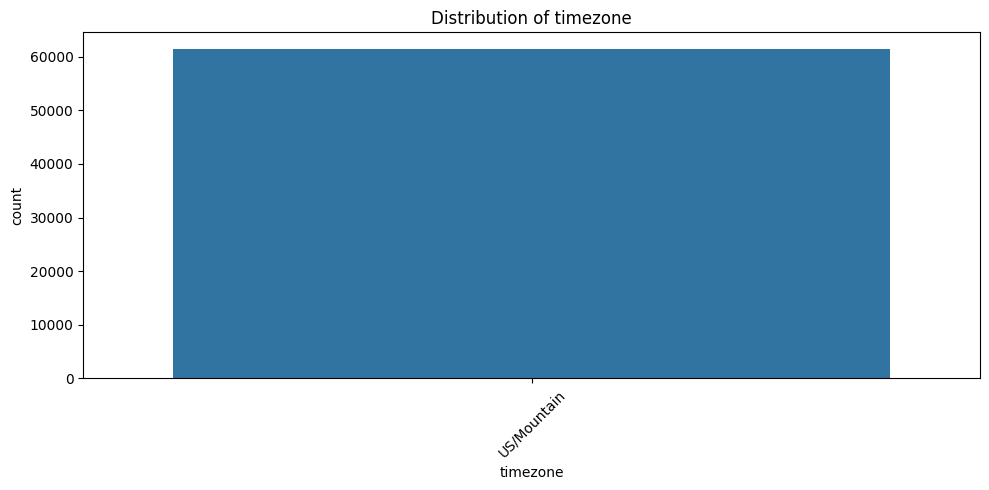

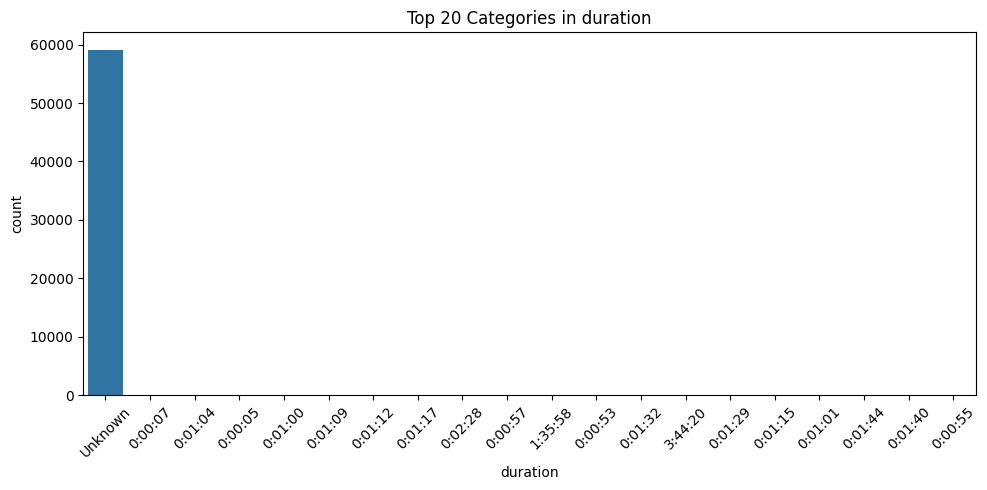

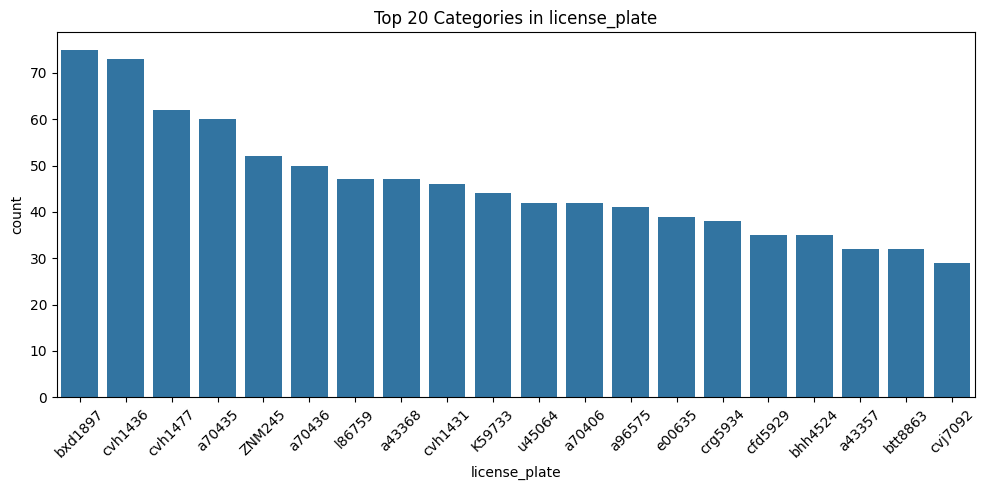

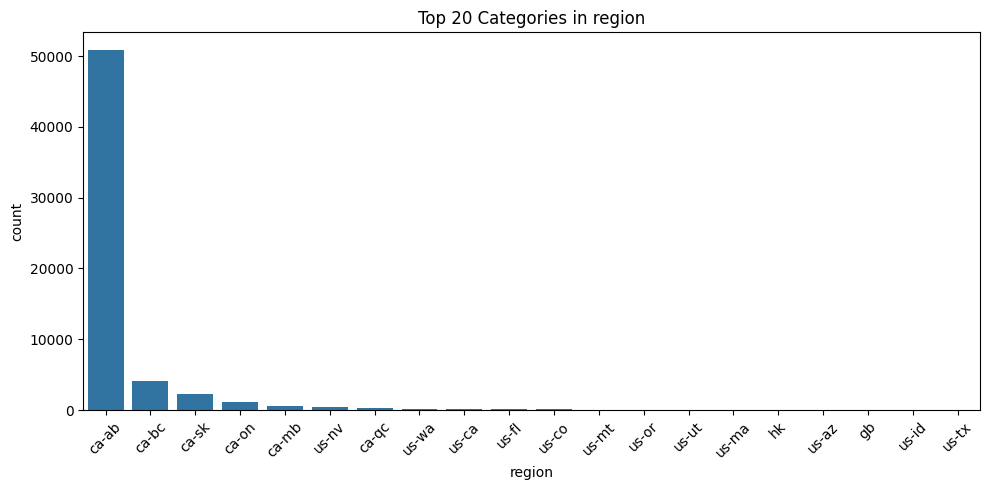

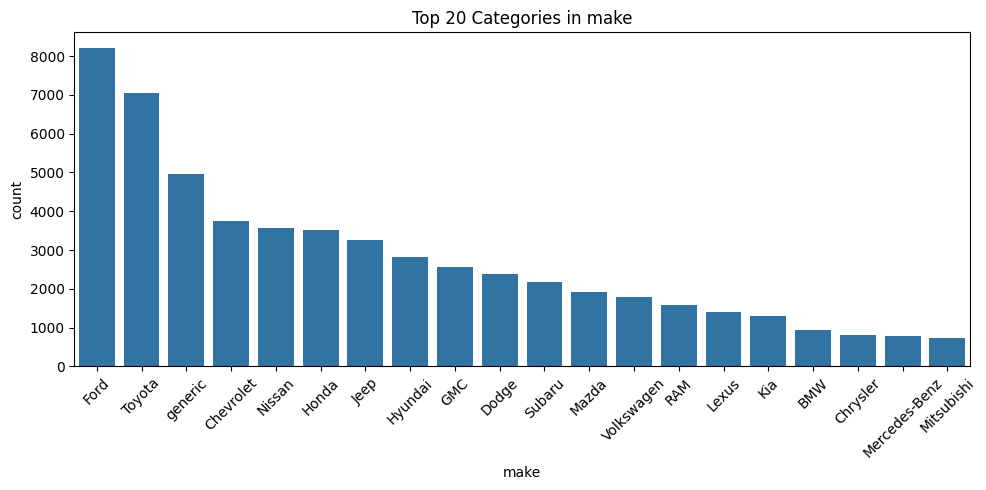

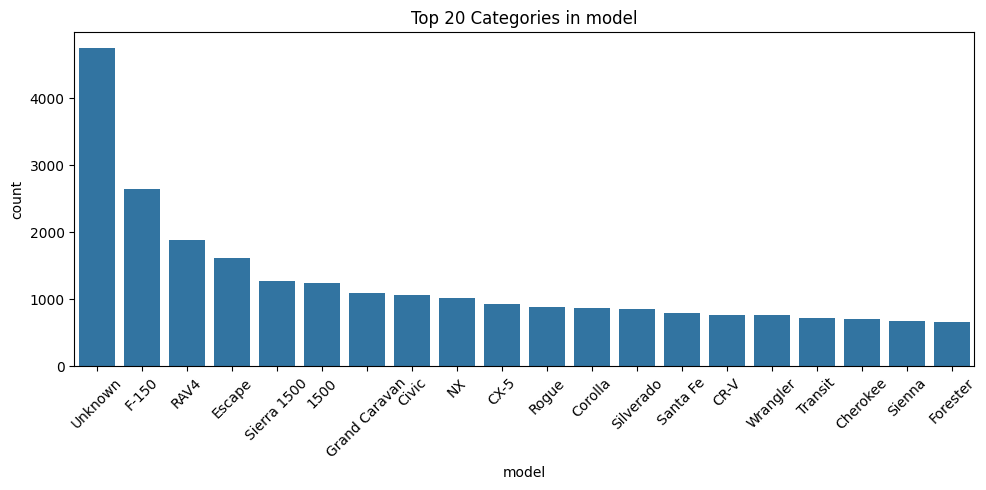

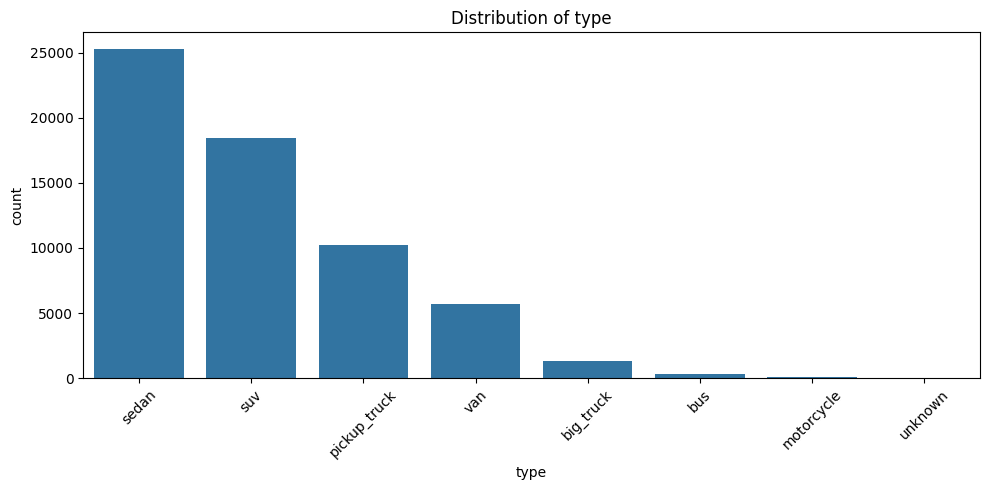

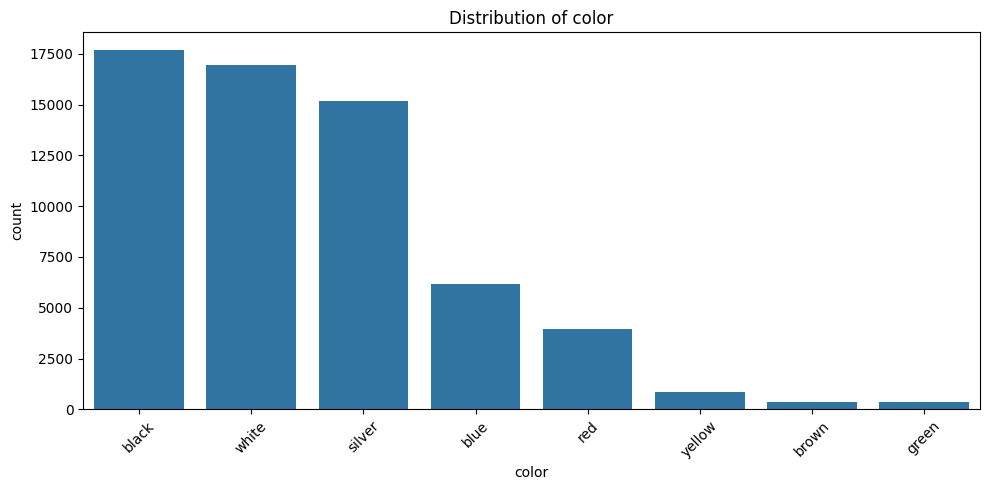

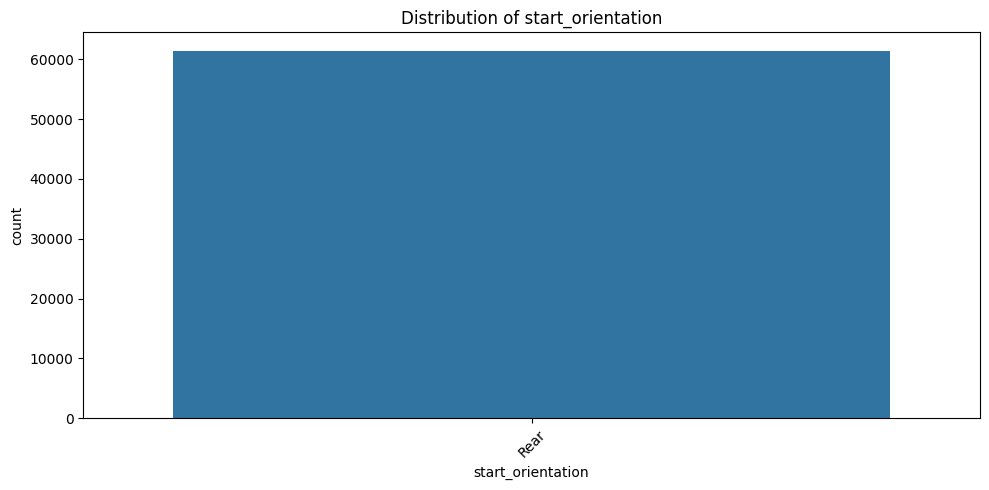

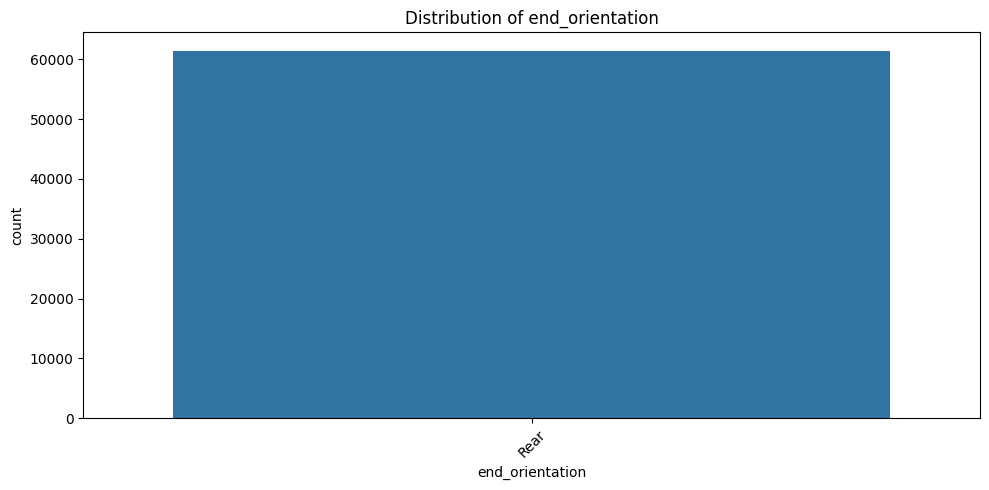

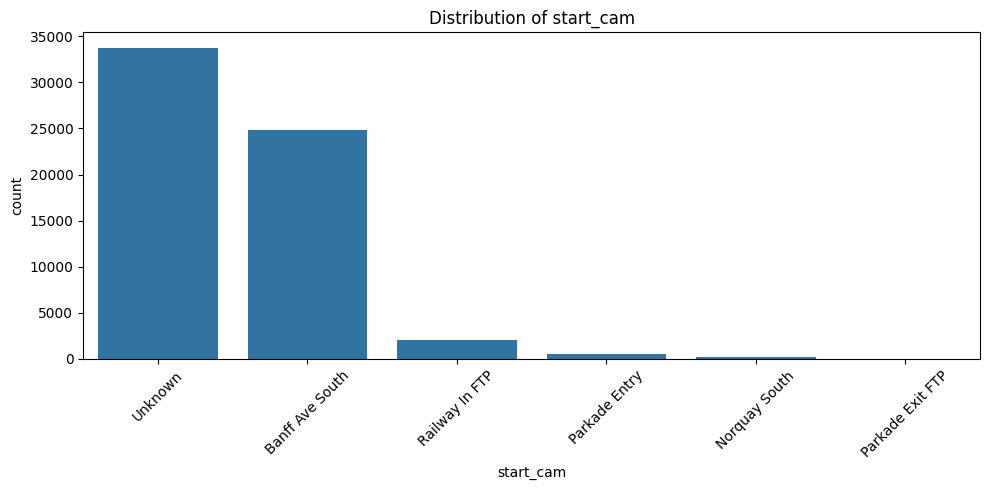

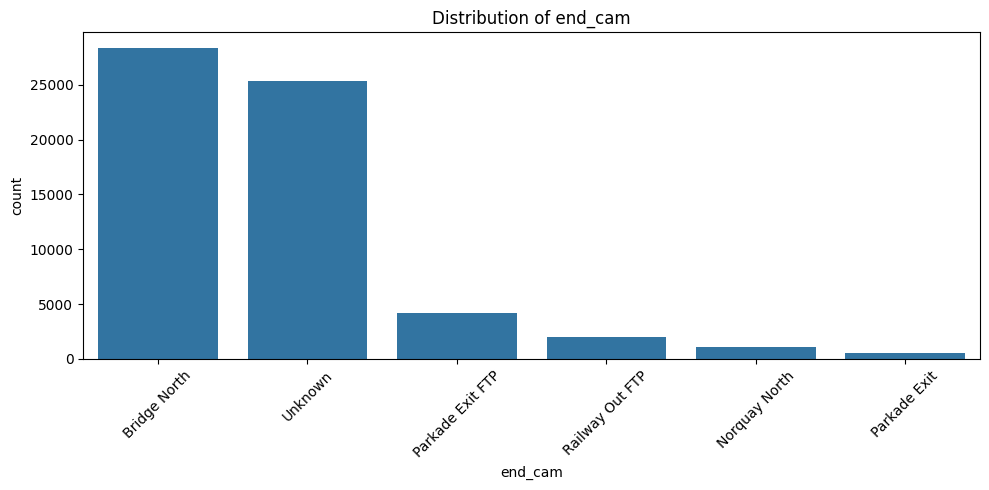

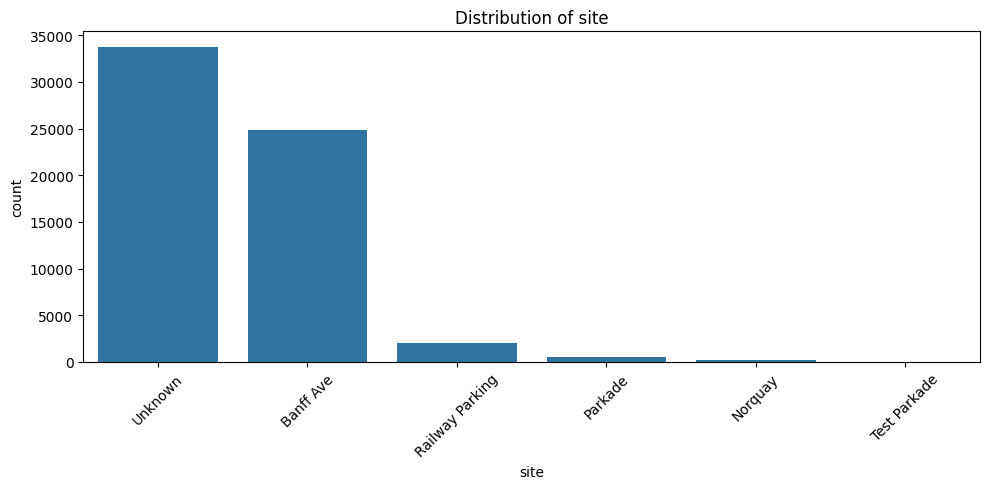

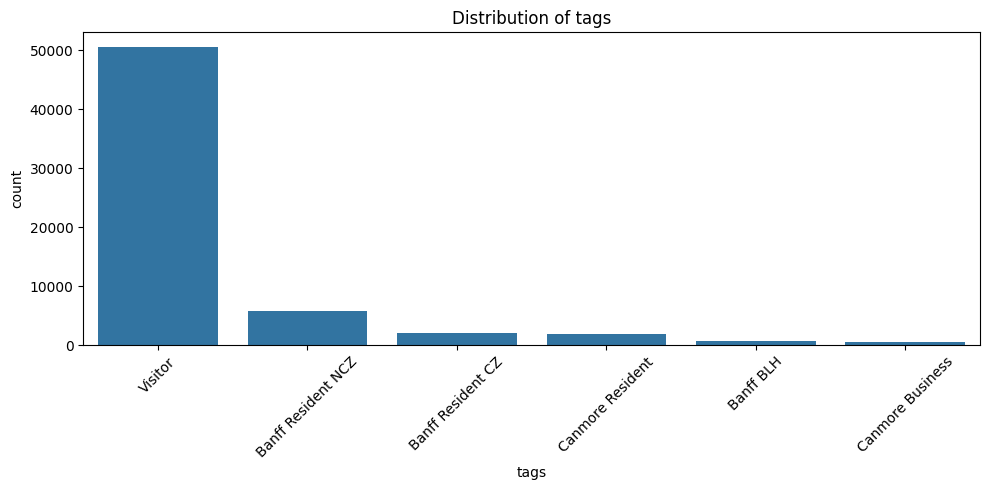

In [ ]:
for col in categorical_cols:
    plt.figure(figsize=(10, 5))

    # Get value counts
    value_counts = df[col].value_counts()

    # Limit to top 20 categories if needed
    if len(value_counts) > 20:
        top_20 = value_counts.head(20)
        sns.countplot(data=df[df[col].isin(top_20.index)], x=col, order=top_20.index)
        plt.title(f'Top 20 Categories in {col}')
    else:
        sns.countplot(data=df, x=col, order=value_counts.index)
        plt.title(f'Distribution of {col}')

    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


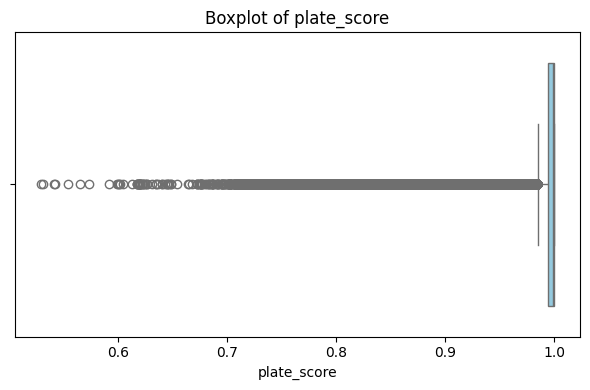

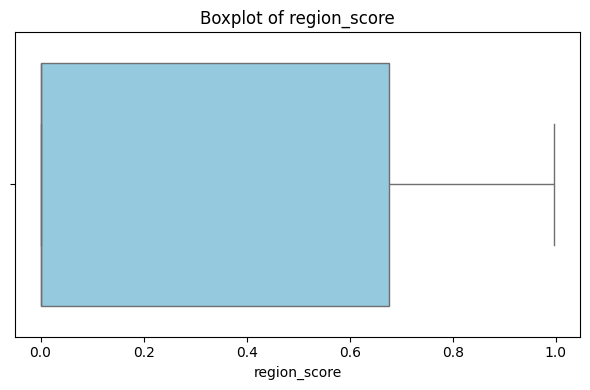

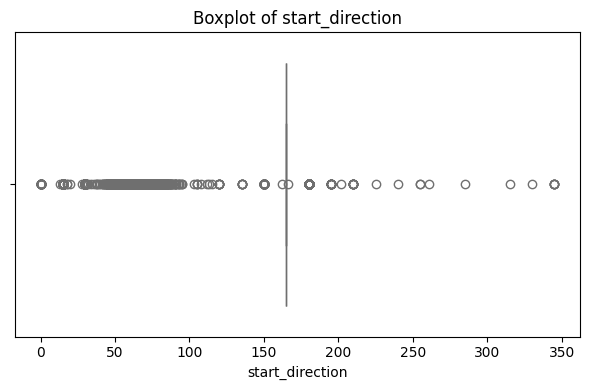

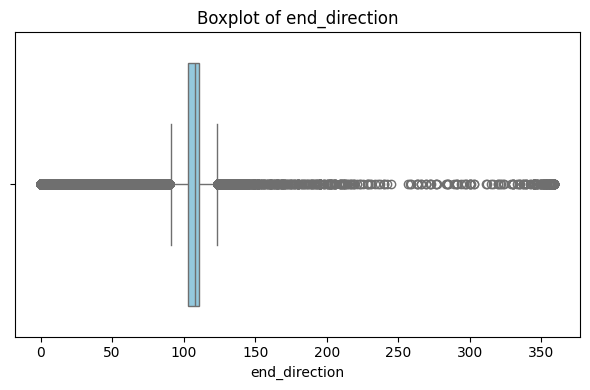

In [ ]:
# Filter to ensure only numeric columns are plotted
numeric_only = df[numerical_cols].select_dtypes(include='number').columns

for col in numeric_only:
    plt.figure(figsize=(6, 4))
    sns.boxplot(x=df[col], color='skyblue')
    plt.title(f'Boxplot of {col}')
    plt.xlabel(col)
    plt.tight_layout()
    plt.show()


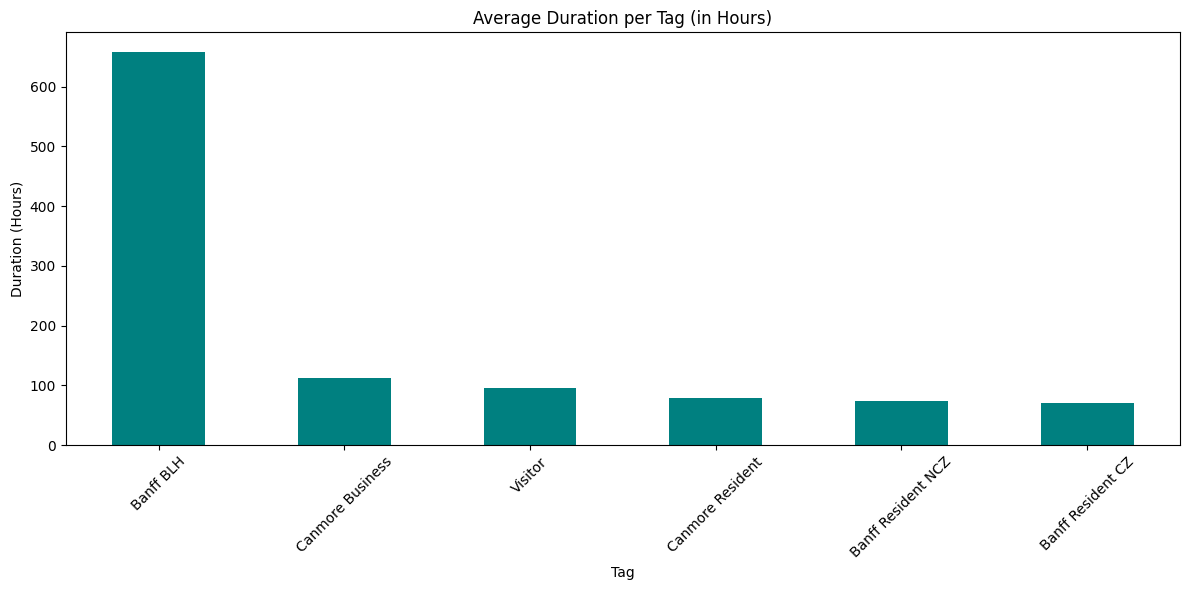

In [ ]:
#Visualization for an average stay duration for Visitor vs Residents
df['duration_parsed'] = pd.to_timedelta(df['duration'], errors='coerce')  #Convert 'duration' to timedelta

# Convert duration to hours
df['duration_hours'] = df['duration_parsed'].dt.total_seconds() / 3600

# Group by 'tags' and get average duration in hours
max_duration_per_tag = df.groupby('tags')['duration_hours'].mean().sort_values(ascending=False)

# Plotting the results
plt.figure(figsize=(12, 6))
max_duration_per_tag.plot(kind='bar', color='teal')
plt.title('Average Duration per Tag (in Hours)')
plt.ylabel('Duration (Hours)')
plt.xlabel('Tag')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

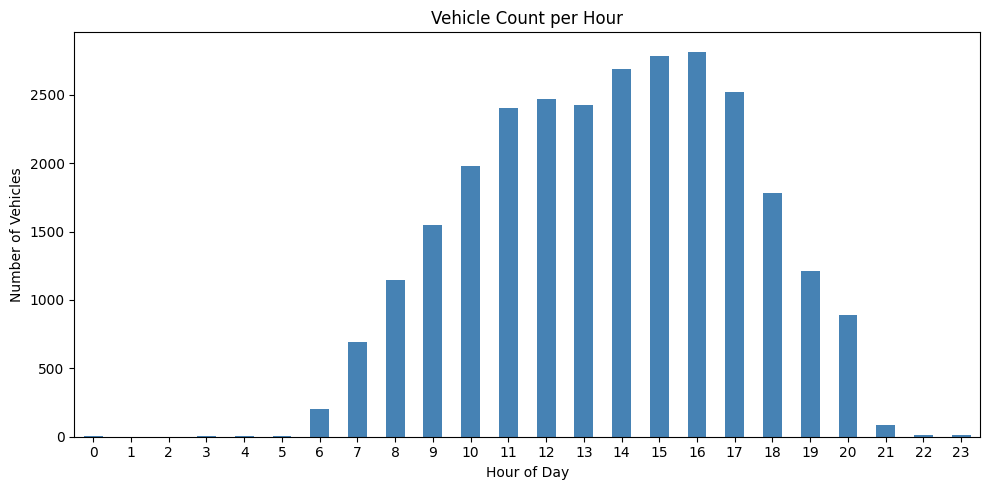

In [ ]:
#Visualization for vehicle count to identify peak hours
# Since there are blank entrance time, Filter out rows with NaT in entrance_time
df_valid = df[df['entrance_time'].notna()].copy()

# Extract hour from entrance_time
df_valid['entrance_hour'] = df_valid['entrance_time'].apply(lambda x: x.hour)

# Aggregate the Count of vehicles per hour
vehicle_count_per_hour = df_valid['entrance_hour'].value_counts().sort_index()

# Plotting the result
plt.figure(figsize=(10, 5))
vehicle_count_per_hour.plot(kind='bar', color='steelblue')
plt.title('Vehicle Count per Hour')
plt.xlabel('Hour of Day')
plt.ylabel('Number of Vehicles')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [ ]:
# Separate the DataFrame into 'Visitor' and 'Other' tags for vehicle count analysis
df_visitor_count = df_valid[df_valid['tags'] == 'Visitor'].copy()
df_resident_count = df_valid[df_valid['tags'] != 'Visitor'].copy()

# Calculate vehicle count per hour for Visitor tags
visitor_vehicle_count_per_hour = df_visitor_count['entrance_hour'].value_counts().sort_index()

# Calculate vehicle count per hour for other tags
resident_vehicle_count_per_hour = df_resident_count['entrance_hour'].value_counts().sort_index()

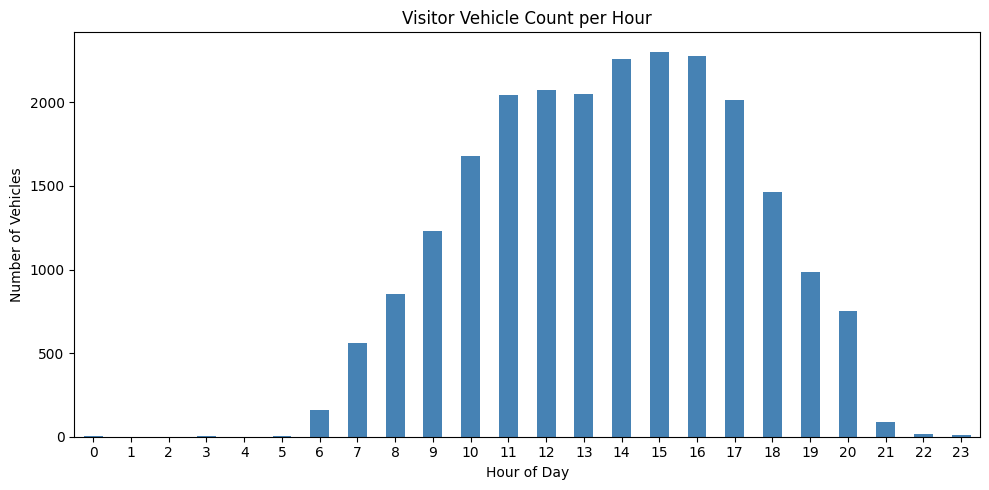

In [ ]:
# Plot vehicle count per hour for Visitor tags
plt.figure(figsize=(10, 5))
visitor_vehicle_count_per_hour.plot(kind='bar', color='steelblue')
plt.title('Visitor Vehicle Count per Hour')
plt.xlabel('Hour of Day')
plt.ylabel('Number of Vehicles')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

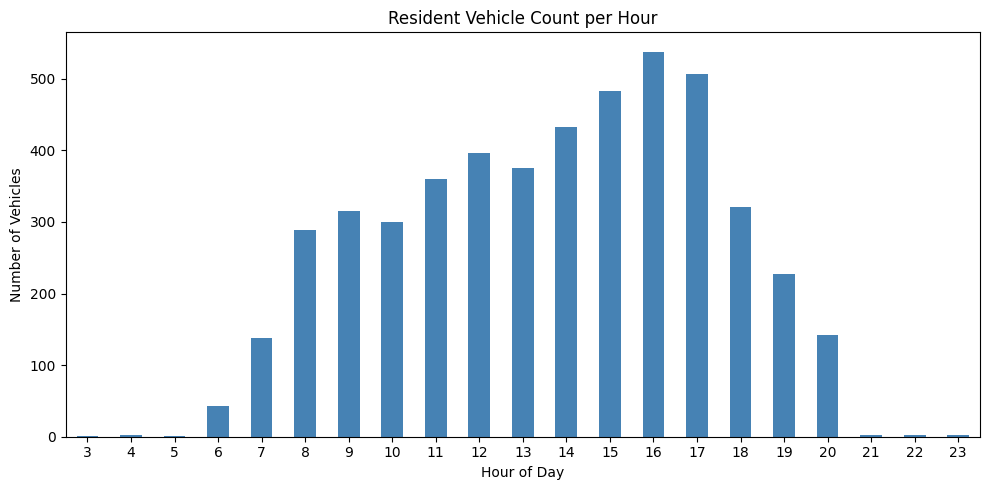

In [ ]:
# Plot vehicle count per hour for other tags
plt.figure(figsize=(10, 5))
resident_vehicle_count_per_hour.plot(kind='bar', color='steelblue')
plt.title('Resident Vehicle Count per Hour')
plt.xlabel('Hour of Day')
plt.ylabel('Number of Vehicles')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

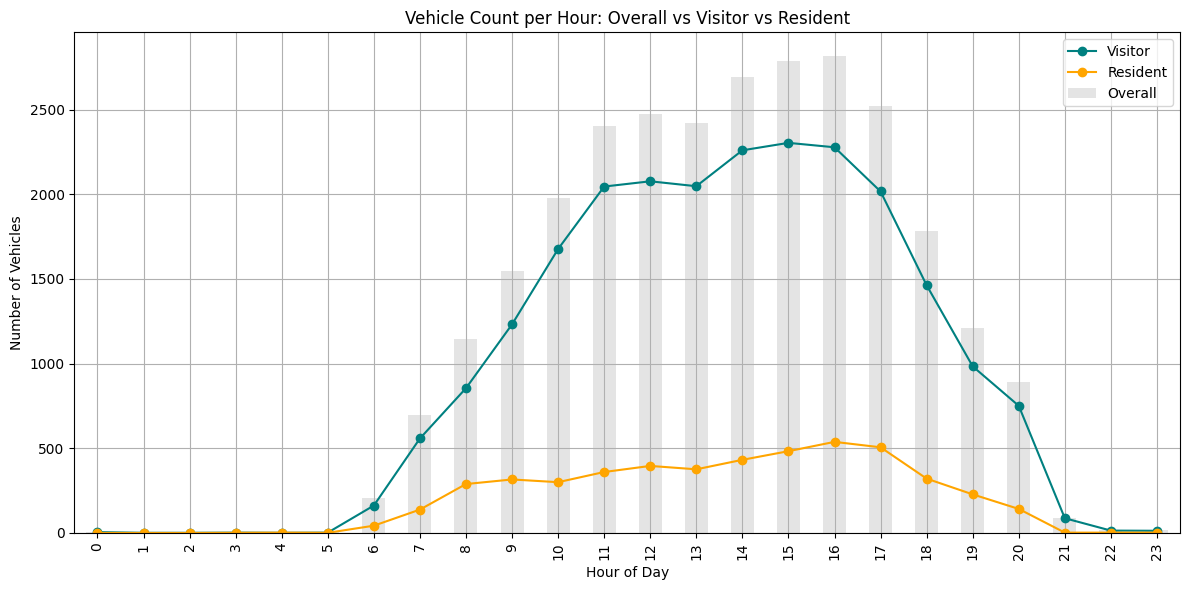

In [ ]:
import matplotlib.pyplot as plt

# Filter valid entrance times
df_valid = df[df['entrance_time'].notna()].copy()
df_valid['entrance_hour'] = df_valid['entrance_time'].apply(lambda x: x.hour)

# Fill missing tags with 'Visitor'
df_valid['tags'] = df_valid['tags'].fillna('Visitor')

# Classify tags
df_valid['tag_type'] = df_valid['tags'].apply(lambda x: 'Visitor' if x == 'Visitor' else 'Resident')

# Overall count
overall_counts = df_valid['entrance_hour'].value_counts().sort_index()

# Visitor and Resident counts
tag_counts = df_valid.groupby(['entrance_hour', 'tag_type']).size().unstack(fill_value=0)

# Plot
plt.figure(figsize=(12, 6))
overall_counts.plot(kind='bar', color='lightgray', label='Overall', alpha=0.6)

plt.plot(tag_counts.index, tag_counts['Visitor'], marker='o', color='teal', label='Visitor')
plt.plot(tag_counts.index, tag_counts['Resident'], marker='o', color='orange', label='Resident')

plt.title('Vehicle Count per Hour: Overall vs Visitor vs Resident')
plt.xlabel('Hour of Day')
plt.ylabel('Number of Vehicles')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


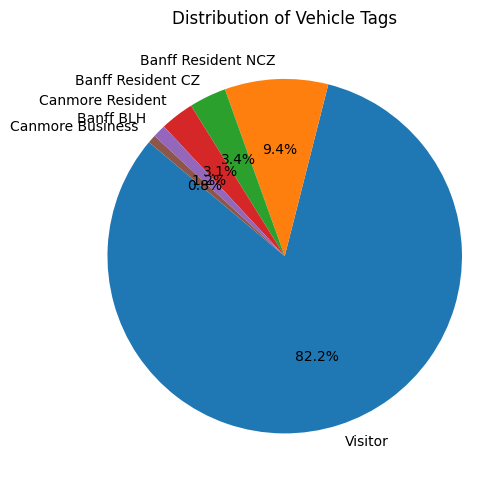

In [ ]:
# Visualization of Visitor vs Resident flow
tag_counts = df['tags'].value_counts() # Get value counts for tags

# Plotting a pie chart
plt.figure(figsize=(5, 5))
plt.pie(tag_counts, labels=tag_counts.index, autopct='%1.1f%%', startangle=140)
plt.title('Distribution of Vehicle Tags')
plt.axis('equal')  # Ensures pie is a circle
plt.tight_layout()
plt.show()


Average number of visits per unique visitor license plate: 1.42


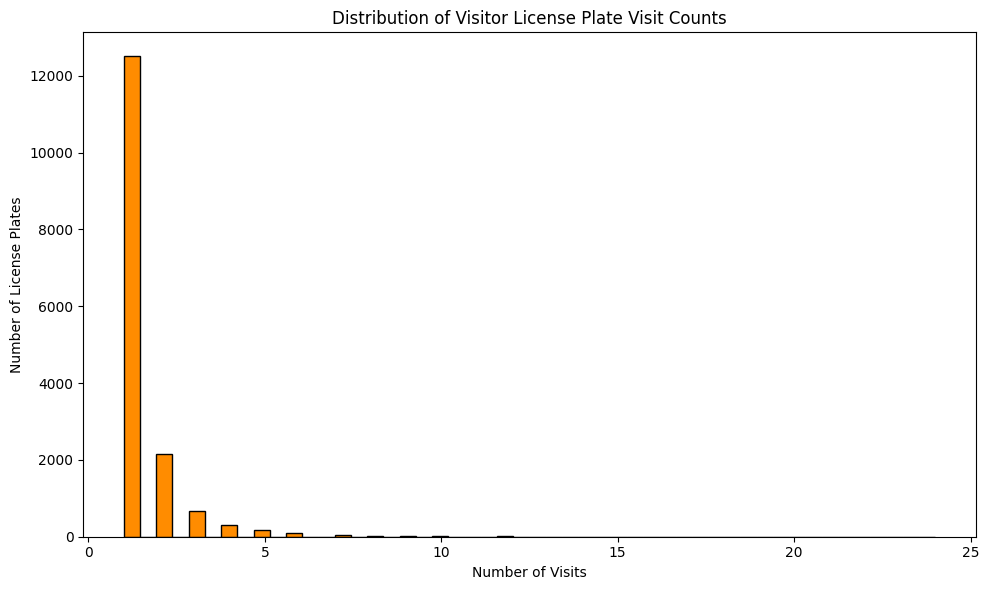

In [ ]:
# Visualization of how many visitors go back again
# Count visits per license plate for visitors
visitor_counts = df_visitor_count['license_plate'].value_counts()

# Calculate the average number of visits per unique visitor license plate
average_visitor_visits = visitor_counts.mean()

# Display the average number of visits
print(f"Average number of visits per unique visitor license plate: {average_visitor_visits:.2f}")

# Histogram of visit counts
plt.figure(figsize=(10, 6))
plt.hist(visitor_counts, bins=50, color='darkorange', edgecolor='black')
plt.title('Distribution of Visitor License Plate Visit Counts')
plt.xlabel('Number of Visits')
plt.ylabel('Number of License Plates')
plt.tight_layout()
plt.show()

### Block 5: Feature Relationships

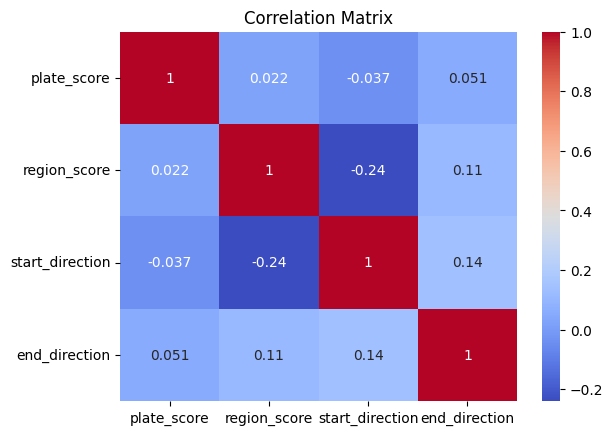

In [ ]:
# Correlation matrix for numerical features
# Exclude date and time columns from correlation calculation
numeric_cols_for_corr = ['plate_score', 'region_score', 'start_direction', 'end_direction']
corr_matrix = df[numeric_cols_for_corr].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

# Dataset Review: ROUTES
Coded by: Angela

## Block 1: Loading and Overview of the Dataset

This step focuses on loading the raw datasets and performing an initial inspection to understand the structure, column names, and data types. The goal is to identify immediate issues such as inconsistent column names, incorrect data types, or obvious missing values that could affect further analysis.

In [ ]:
# Importing libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import folium
import googlemaps
import time
import os

The following code loads all raw data files and combines them into a single dataframe. A column for 'route' was added to each individual dataframe to distinguish them.

Some inconsistencies in column names were found in the raw data files, which was fixed before merging.

We will then save it as a single csv file for faster loading and comment out the code that loads the individual files to save time as this process takes a few minutes.

In [ ]:
# # Step 1: Load the raw datasets

# # Base folder
# base_folder = 'Data/Routes'

# # Store all individual dataframes in a list
# all_dfs = []

# # Loop through the folders
# for route_folder in os.listdir(base_folder):
#     folder_path = os.path.join(base_folder, route_folder)

#     # Make sure the folder is a directory
#     if os.path.isdir(folder_path):
#         # Get the route number
#         route_number = route_folder.split()[-1]

#         # Loop through the files in the folder
#         for file_name in os.listdir(folder_path):
#             # Get the file path
#             file_path = os.path.join(folder_path, file_name)

#             # Load file depending on extension
#             if file_name.endswith('.csv'):
#                 df = pd.read_csv(file_path)
#             else:
#                 df = pd.read_excel(file_path)

#             # Fix inconsistencies in column names
#             df.columns = df.columns.str.strip().str.lower()

#             # Add route number column
#             df['route'] = f'Route {route_number}'

#             # Append to list
#             all_dfs.append(df)

# # Concatenate all dataframes
# all_routes_df = pd.concat(all_dfs, ignore_index=True)

# # Save as CSV
# all_routes_df.to_csv('all_routes_merged.csv', index=False)

In [ ]:
# Load the merged dataset
all_routes_df = pd.read_csv('all_routes_merged.csv', low_memory=False)

In [ ]:
# Step 2: Display the first 5 rows of the dataset
all_routes_df.head()

,calculation time,speed(mph),speed(km/h),mean travel time (mins),actual delay (mins),current delay (mins),trend,route
0,Wed Apr 9 2025 12:30:00 MDT,19.8,31.9,2,0.0,0.13,DOWN,Route 7
1,Wed Apr 9 2025 12:29:00 MDT,19.8,31.9,2,0.0,0.13,DOWN,Route 7
2,Wed Apr 9 2025 12:28:00 MDT,19.8,31.9,2,0.0,0.13,DOWN,Route 7
3,Wed Apr 9 2025 12:27:00 MDT,19.8,31.9,2,0.0,0.13,DOWN,Route 7
4,Wed Apr 9 2025 12:26:00 MDT,19.8,31.9,2,0.0,0.13,DOWN,Route 7


In [ ]:
# Step 3: Use .info() to get a summary of the dataset
all_routes_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6817268 entries, 0 to 6817267
Data columns (total 8 columns):
 #   Column                   Dtype  
---  ------                   -----  
 0   calculation time         object 
 1   speed(mph)               object 
 2   speed(km/h)              object 
 3   mean travel time (mins)  object 
 4   actual delay (mins)      float64
 5   current delay (mins)     float64
 6   trend                    object 
 7   route                    object 
dtypes: float64(2), object(6)
memory usage: 416.1+ MB


In [ ]:
# Step 4: Check for missing values
missing_counts = all_routes_df.isnull().sum()
print(f'Missing values per column:\n{missing_counts}')

Missing values per column:
calculation time             0
speed(mph)                   0
speed(km/h)                  0
mean travel time (mins)    314
actual delay (mins)          0
current delay (mins)         0
trend                        0
route                        0
dtype: int64


### Block 1 Analysis

The merged dataset contains **6,817,268** records across 8 columns, representing traffic measurements for the routes. At first glance, several issues are present:

**Column naming inconsistencies:** Many column names had leading white spaces, which will make them harder to reference and merge. These were removed and standardized before merging.

**Incorrect data types:**
- 'calculation time' is originally stored as a text object. We will convert it to a datetime object.
- Speed values and travel times are also stored as strings. These will be converted to numeric values.
- Delay columns are already numeric and require no change.

**Missing values:** The initial check for missing values using 'isnull().sum()' and found that only 'mean travel time (mins) had 314 missing values. However, a deeper analysis showed that a number of speed and travel time values are marked as 'unknown' and 'N/A' respectively, which are essentially missing values. These will be handled in the next block.

## Block 2: Data Cleaning & Preparation

This step focuses on cleaning the dataset and handling missing or inconsistent values. It includes standardizing column names, converting data types, identifying missing values, imputing or flagging missing entries, and removing duplicates. The goal is to ensure that the dataset is complete, consistent, and ready for analysis and visualization.

In [ ]:
# Step 1: Convert datatypes

# Remove timezone from calculation time
all_routes_df['calculation time'] = (
    all_routes_df['calculation time']
    .str.rsplit(' ', n=1).str[0])

# Convert to datetime object
all_routes_df['calculation time'] = pd.to_datetime(
    all_routes_df['calculation time'],
    format='%a %b %d %Y %H:%M:%S',
    errors='coerce')

# Convert remaining columns to numeric types
numerical_cols = ['speed(mph)', 'speed(km/h)', 'mean travel time (mins)']

for col in numerical_cols:
    all_routes_df[col] = pd.to_numeric(all_routes_df[col], errors='coerce')

# Check
all_routes_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6817268 entries, 0 to 6817267
Data columns (total 8 columns):
 #   Column                   Dtype         
---  ------                   -----         
 0   calculation time         datetime64[ns]
 1   speed(mph)               float64       
 2   speed(km/h)              float64       
 3   mean travel time (mins)  float64       
 4   actual delay (mins)      float64       
 5   current delay (mins)     float64       
 6   trend                    object        
 7   route                    object        
dtypes: datetime64[ns](1), float64(5), object(2)
memory usage: 416.1+ MB


In [ ]:
# Step 2: Missing values
missing_counts = all_routes_df.isnull().sum()
missing_percent = (missing_counts / len(all_routes_df) * 100).round(2)

missing_summary = pd.DataFrame({
    'Missing Values': missing_counts,
    'Percent Missing (%)': missing_percent
})

missing_summary

,Missing Values,Percent Missing (%)
calculation time,0,0.00
speed(mph),542792,7.96
speed(km/h),542792,7.96
mean travel time (mins),543106,7.97
actual delay (mins),0,0.00
current delay (mins),0,0.00
trend,0,0.00
route,0,0.00


In [ ]:
# Want to verify if they are the same rows

key_cols = ['speed(km/h)', 'speed(mph)', 'mean travel time (mins)']

# Subset rows where *any* of these columns are missing
subset_null = all_routes_df[all_routes_df[key_cols].isna().any(axis=1)]

# Count how many have all three missing
num_all_missing = all_routes_df[key_cols].isna().all(axis=1).sum()

print(f"Total rows with any missing values: {len(subset_null)}")
print(f"Rows where all three columns are missing: {num_all_missing}")

# See which pattern of missingness occurs
print("\nMissing pattern breakdown:")
print(all_routes_df[key_cols].isna().value_counts())

# Show a few partial-missing examples
subset_null.head(10)


Total rows with any missing values: 543106
Rows where all three columns are missing: 542792

Missing pattern breakdown:
speed(km/h)  speed(mph)  mean travel time (mins)
False        False       False                      6274162
True         True        True                        542792
False        False       True                           314
Name: count, dtype: int64


,calculation time,speed(mph),speed(km/h),mean travel time (mins),actual delay (mins),current delay (mins),trend,route
1968,2025-04-08 03:42:00,NaN,NaN,NaN,0.0,0.0,FLAT,Route 7
1969,2025-04-08 03:41:00,NaN,NaN,NaN,0.0,0.0,FLAT,Route 7
1970,2025-04-08 03:40:00,NaN,NaN,NaN,0.0,0.0,FLAT,Route 7
1971,2025-04-08 03:39:00,NaN,NaN,NaN,0.0,0.0,FLAT,Route 7
1972,2025-04-08 03:38:00,NaN,NaN,NaN,0.0,0.0,FLAT,Route 7
1973,2025-04-08 03:37:00,NaN,NaN,NaN,0.0,0.0,FLAT,Route 7
1974,2025-04-08 03:36:00,NaN,NaN,NaN,0.0,0.0,FLAT,Route 7
1975,2025-04-08 03:35:00,NaN,NaN,NaN,0.0,0.0,FLAT,Route 7
1976,2025-04-08 03:34:00,NaN,NaN,NaN,0.0,0.0,FLAT,Route 7
2004,2025-04-08 03:06:00,NaN,NaN,NaN,0.0,0.0,FLAT,Route 7


In [ ]:
# Investigating null values to check if we should remove them
# If all rows with missing speeds also have missing delays, we can remove them

# Subset rows where either speed column is missing
subset_missing_speeds = all_routes_df[
    all_routes_df[['speed(km/h)', 'speed(mph)']].isna().any(axis=1)
]

# Verify both delay columns are zero
all_actual_zero = (subset_missing_speeds['actual delay (mins)'] == 0).all()
all_current_zero = (subset_missing_speeds['current delay (mins)'] == 0).all()

print(f'All rows with missing speeds have actual delay = 0? {all_actual_zero}')
print(f'All rows with missing speeds have current delay = 0? {all_current_zero}')


All rows with missing speeds have actual delay = 0? True
All rows with missing speeds have current delay = 0? True


In [ ]:
# Since all rows have zero values for all speed columns, we can drop them
all_routes_df = all_routes_df.drop(subset_null.index)

print(f'Remaining rows after dropping nulls: {len(all_routes_df)}')

# Verify missing values
missing_counts = all_routes_df.isnull().sum()
missing_percent = (missing_counts / len(all_routes_df) * 100).round(2)

missing_summary = pd.DataFrame({
    'Missing Values': missing_counts,
    'Percent Missing (%)': missing_percent
})

missing_summary


Remaining rows after dropping nulls: 6274162


,Missing Values,Percent Missing (%)
calculation time,0,0.0
speed(mph),0,0.0
speed(km/h),0,0.0
mean travel time (mins),0,0.0
actual delay (mins),0,0.0
current delay (mins),0,0.0
trend,0,0.0
route,0,0.0


In [ ]:
# Step 3: Check for duplicates
duplicate_count = all_routes_df.duplicated().sum()
print(f'Number of full-row duplicates: {duplicate_count}')

duplicates = all_routes_df[all_routes_df.duplicated(keep=False)]
duplicates.sort_values(['calculation time', 'route']).head(10)

Number of full-row duplicates: 2656734


,calculation time,speed(mph),speed(km/h),mean travel time (mins),actual delay (mins),current delay (mins),trend,route
871130,2024-12-31 22:00:00,19.0,30.6,8.62,1.37,0.67,FLAT,Route 10
1013728,2024-12-31 22:00:00,19.0,30.6,8.62,1.37,0.67,FLAT,Route 10
2152230,2024-12-31 22:00:00,22.3,35.8,7.38,0.13,0.42,FLAT,Route 11
2294828,2024-12-31 22:00:00,22.3,35.8,7.38,0.13,0.42,FLAT,Route 11
5314540,2024-12-31 22:00:00,11.5,18.5,5.78,1.37,0.60,FLAT,Route 12
5457788,2024-12-31 22:00:00,11.5,18.5,5.78,1.37,0.60,FLAT,Route 12
4708761,2024-12-31 22:00:00,15.2,24.5,4.42,0.00,0.20,FLAT,Route 13
4852010,2024-12-31 22:00:00,15.2,24.5,4.42,0.00,0.20,FLAT,Route 13
5757629,2024-12-31 22:00:00,9.4,15.2,4.65,1.15,1.55,UP,Route 2
5900868,2024-12-31 22:00:00,9.4,15.2,4.65,1.15,1.55,UP,Route 2


In [ ]:
# Drop duplicates
all_routes_df = all_routes_df.drop_duplicates()

# Check
duplicate_count = all_routes_df.duplicated().sum()
print(f'Number of full-row duplicates after dropping: {duplicate_count}')

Number of full-row duplicates after dropping: 0


In [ ]:
# Reset index and final check
all_routes_df = all_routes_df.reset_index()
all_routes_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3617428 entries, 0 to 3617427
Data columns (total 9 columns):
 #   Column                   Dtype         
---  ------                   -----         
 0   index                    int64         
 1   calculation time         datetime64[ns]
 2   speed(mph)               float64       
 3   speed(km/h)              float64       
 4   mean travel time (mins)  float64       
 5   actual delay (mins)      float64       
 6   current delay (mins)     float64       
 7   trend                    object        
 8   route                    object        
dtypes: datetime64[ns](1), float64(5), int64(1), object(2)
memory usage: 248.4+ MB


In [ ]:
# Save cleaned data
all_routes_df.to_csv('cleaned_routes.csv', index=False)

### Block 2 Analysis

After inspecting the dataset for duplicates, missing values, and datatype consistency, several key observations were made:

**Datatype Conversions:**  The 'calculation time' column was converted to a datetime object to enable proper time-based analysis. Columns 'speed(mph)', 'speed(km/h)', and 'mean travel time (mins)' were converted to numeric float types. This ensures all columns are in appropriate formats for analysis and modeling.

**Missing Values:** Columns 'speed(mph)', 'speed(km/h)', and 'mean travel time (mins)' contained missing values, originally recorded as 'unknown' or 'N/A' in the raw datasets. Speed columns had **542,792** missing entries, and 'mean travel time (mins) had **543,106** missing entries, representing ~8% of the dataset. This difference accounts for the additional 314 missing entries we saw for 'mean travel time (mins)'. Upon inspection, all all rows with missing speed also had 0 values for both actual and current delay, indicating that they were likely fauly measurements rather than real observations. While the additional 314 missing values for 'mean travel time (mins)' could have been imputed, this likely would have introduced redundancy in our dataset. Since these rows did not contain meaningful traffic data, they were removed entirely to prevent introducing artificial values that could skew the analysis. After removing these rows, the dataset now contains **6,274,162** rows.

**Duplicates:** After removing null values, the dataset was checked for full-row duplicates. There were **2,656,734** rows that were completely identical across all columns. These duplicates represent repeated observations of the same traffic snapshots. While technically valid, they are redundant for analysis purposes and were removed. After dropping duplicates and resetting the index, the dataset now contains **3,617,428** unique rows.

The dataset is now clean, complete, and free of redundant rows. Missing numeric values have been imputed in a way that preserves realistic traffic patterns, all columns are properly typed, and full-row duplicates have been removed. The dataset is now ready for further analysis or modeling of traffic trends.



## Block 3: Descriptive Statistics

This step focuses on performing descriptive statistical analysis to summarize numerical and categorical features. It includes generating summary statistics, calculating distribution frequencies, and identifying patterns or anomalies. The goal is to gain a deeper understanding of the dataset and establish a baseline for trends, ranges, and typical values before visualization or modeling.

In [ ]:
# Step 1: Identify numerical and categorical features
numerical_cols = ['speed(mph)', 'speed(km/h)', 'mean travel time (mins)',
                  'actual delay (mins)', 'current delay (mins)']
categorical_cols = ['route', 'trend']

In [ ]:
# Step 2: Summary statistics for numerical columns
numeric_summary = all_routes_df[numerical_cols].describe().T
numeric_summary['range'] = numeric_summary['max'] - numeric_summary['min']
numeric_summary = numeric_summary.round(2)

numeric_summary

,count,mean,std,min,25%,50%,75%,max,range
speed(mph),3617428.0,16.60,4.72,0.40,13.20,15.20,19.30,40.10,39.70
speed(km/h),3617428.0,26.71,7.59,0.60,21.20,24.50,31.00,64.60,64.00
mean travel time (mins),3617428.0,4.18,2.04,1.28,2.88,3.37,5.10,121.50,120.22
actual delay (mins),3617428.0,0.17,1.21,0.00,0.00,0.00,0.00,114.97,114.97
current delay (mins),3617428.0,0.37,1.61,0.00,0.07,0.20,0.27,168.42,168.42


In [ ]:
# Step 4: Categorical columns summary

# Display value counts and percentages
for col in categorical_cols:
    counts = all_routes_df[col].value_counts()
    percent = (counts / len(all_routes_df) * 100).round(2)
    summary = pd.DataFrame({
        'Count': counts,
        'Percentage (%)': percent
    })
    print(f"\nDistribution for {col}:")
    display(summary)



Distribution for route:


,Count,Percentage (%)
route,,
Route 6,419352,11.59
Route 4,384924,10.64
Route 8,340302,9.41
Route 7,340301,9.41
Route 2,335014,9.26
Route 5,329061,9.10
Route 13,315336,8.72
Route 12,315335,8.72
Route 10,315321,8.72



Distribution for trend:


,Count,Percentage (%)
trend,,
FLAT,2343884,64.79
UP,654660,18.10
DOWN,618884,17.11


### Block 3 Analysis

**Numerical Columns:**
The dataset contains five numeric columns: speed(mph), speed(km/h), mean travel time (mins), actual delay (mins), and current delay (mins). Overall, the numeric statistics indicate that the dataset is dominated by typical traffic condidtions, with extreme outliers present in both travel time and delay metrics.

- **Speeds:** The average speed is 26.71 km/h, with most observations ranging from ~21.2 km/h at the 25th percentile to 31 km/h at the 75th percentile. Extreme values reach 64.6 km/h, which may represent unusually fast traffic conditions.

- **Mean Travel Time:** The average travel time is 4.18 minutes, with a standard deviation of 2.04 minutes. Most trips fall between 2.88 - 5.1 minutes, though a few extreme cases reach 121.5 minutes, likely reflecting outliers or incidents.

- **Delays:** The average actual delay is low at 0.17 minutes, with most observations being 0, indicating smooth traffic. Current delay is slightly higher, averaging 0.37 minutes, however the maximum observed delay is 168.42 minutes, highlighting rate gongestion events or anomalies.

**Categorical Columns:** The dataset contains two categorical columns, trend and route.

- **Trend:** Most traffic trends are recorded as flat (64.79%), followed by up (18.1%), and down (17.11%). This provides insight into how road gradient may influence speeds, travel times, and delays.    

- **Route Distribution:** This feature was added when merging the raw datasets to indicate the source route for each traffic observation. Route 6 has the highest number of observations (11.59%). Routes 2, 4, 5, 6, 7, 8, 10, 11, 12, and 13 each contribute between 8-12% of records. Routes 1 and 3 are the least represented routes, contributing less than 3% of records. This shows that traffic data is resonably distributed across multiple routes, although some routes are sampled more frequently than others.

## Block 4: Data Visualization

This step will focus on visually exploring the dataset to identify patterns, distributions, and possible outliers. Visualizations help confirm trends observed in descriptive statistics and reveal additional insights not obvious from summary tables.

### Map for Data Understanding

This step will focus on creating a map to visualize the various routes and their respective locations.

In [ ]:
# Google maps API
from dotenv import load_dotenv
load_dotenv()
api_key = os.getenv('GOOGLE_API_KEY')
gmaps = googlemaps.Client(key=api_key)

# Dictionary of routes and their coordinates
coords_dict = {
    'Route 1': ['Rimrock Hotel, Banff, AB', 'Downtown Banff, Banff, AB'],
    'Route 2': ['Banff Springs Hotel, Banff, AB', 'Downtown Banff, Banff, AB'],
    'Route 3': ['Downtown Banff, Banff, AB', 'Rimrock Hotel, Banff, AB'],
    'Route 4': ['Downtown Banff, Banff, AB', 'Banff Springs Hotel, Banff, AB'],
    'Route 5': ['Cave and Basin National Historic Site, Banff, AB', 'Downtown Banff, Banff, AB'],
    'Route 6': ['Downtown Banff, Banff, AB', 'Cave and Basin National Historic Site, Banff, AB'],
    'Route 7': [(51.1810, -115.5788), 'Downtown Banff, Banff, AB'], # West entrance to downtown
    'Route 8': ['Downtown Banff, Banff, AB', (51.1810, -115.5788)], # Downtown to west entrance
    'Route 10': ['Downtown Banff, Banff, AB', (51.2068, -115.5373)], # Downtown to east entrance
    'Route 11': [(51.2068, -115.5373), 'Downtown Banff, Banff, AB'], # East entrance to downtown
    'Route 12': ['Downtown Banff, Banff, AB', 'Inns of Banff Hotel, Banff, AB'],
    'Route 13': ['Inns of Banff Hotel, Banff, AB', 'Downtown Banff, Banff, AB']
}

# Routes ending downtown
downtown_routes = ['Route 1', 'Route 2', 'Route 5', 'Route 7', 'Route 11', 'Route 13']

# Map coordinates to names for entrances
special_locations = {
    (51.1810, -115.5788): "West Entrance, Banff, AB",
    (51.2068, -115.5373): "East Entrance, Banff, AB"
}

def get_label(name_or_coord):
    # Return a human-readable label for a marker.
    if isinstance(name_or_coord, tuple):
        return special_locations.get(name_or_coord, f"Lat/Lon {name_or_coord}")
    else:
        return name_or_coord  # regular place name

def resolve_point(p):
    if isinstance(p, tuple):
        return p
    else:
        geocode = gmaps.geocode(p)
        loc = geocode[0]['geometry']['location']
        return loc['lat'], loc['lng']

# Folium base map
map = folium.Map(location=[51.1784, -115.5708], zoom_start=13)

for route, points in coords_dict.items():
    if route not in downtown_routes:
        start_name, end_name = points[0], points[1]

        start_coord = resolve_point(start_name)
        end_coord = resolve_point(end_name)

        # Plot directions
        directions = gmaps.directions(start_name, end_name, mode='driving')
        encoded_points = directions[0]['overview_polyline']['points']
        decoded_points = googlemaps.convert.decode_polyline(encoded_points)
        route_coords = [(p['lat'], p['lng']) for p in decoded_points]

        # Draw polyline
        folium.PolyLine(
            locations=route_coords,
            color='blue',
            weight=5
        ).add_to(map)

        start_label = get_label(start_name)
        end_label = get_label(end_name)

        # Marker for start point with actual location name
        folium.Marker(
            location=start_coord,
            popup=start_name,
            tooltip=start_label,
        ).add_to(map)

        # Marker for end point with actual location name
        folium.Marker(
            location=end_coord,
            popup=end_name,
            tooltip=end_label,
        ).add_to(map)


map


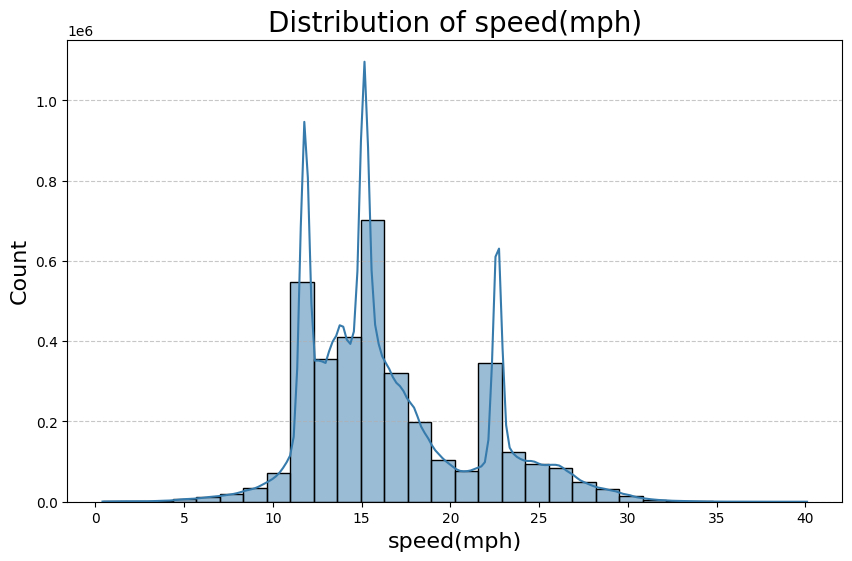

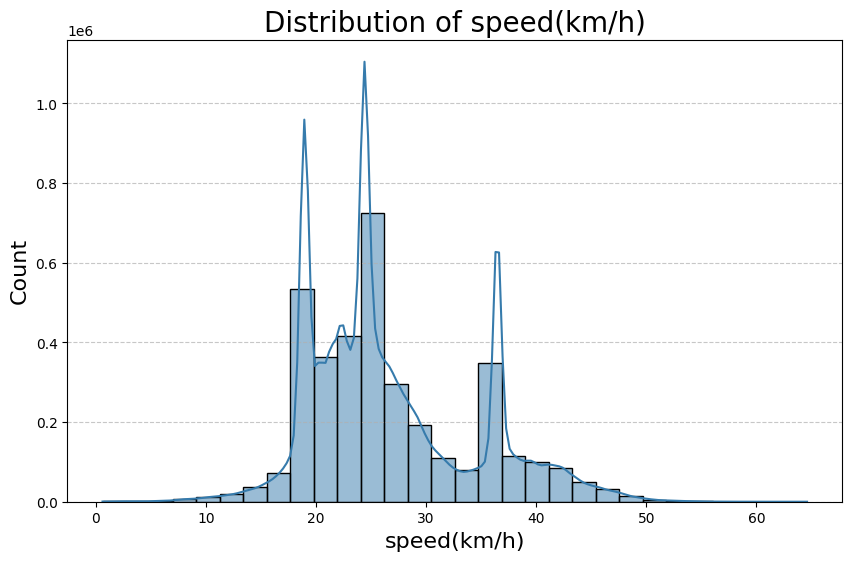

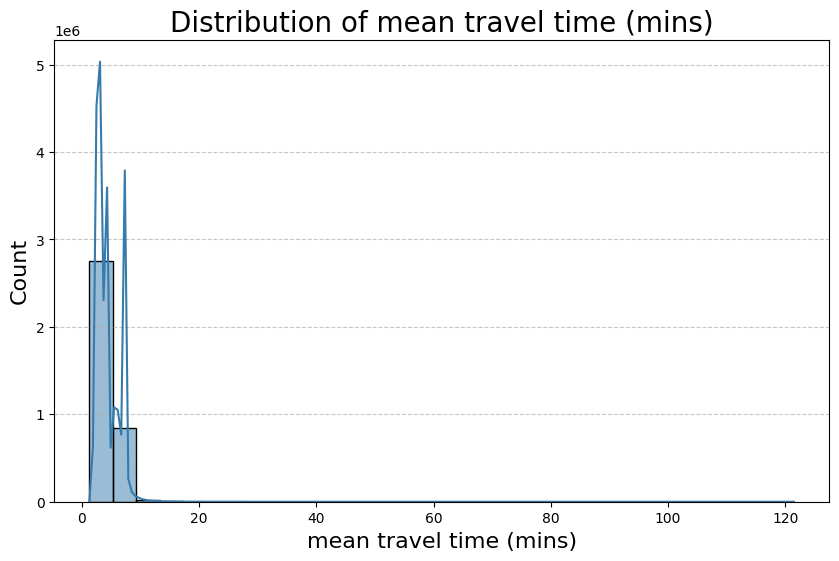

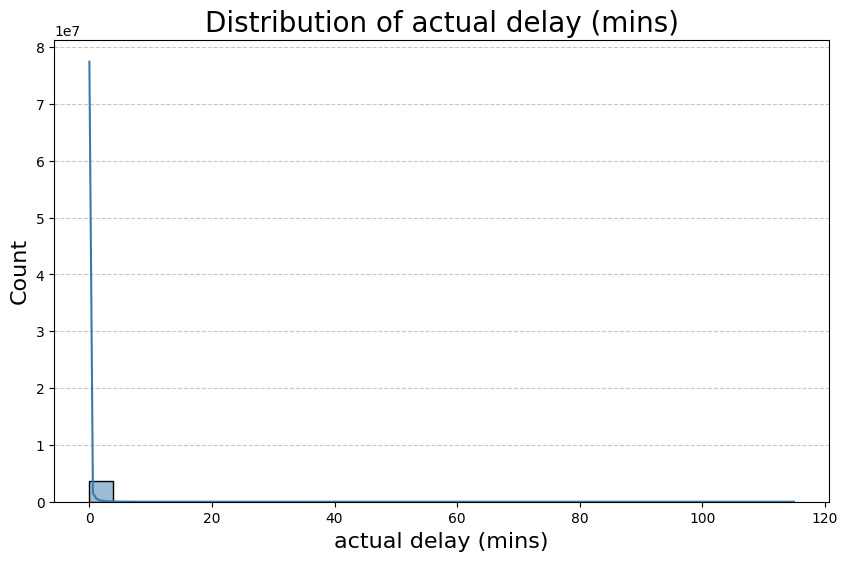

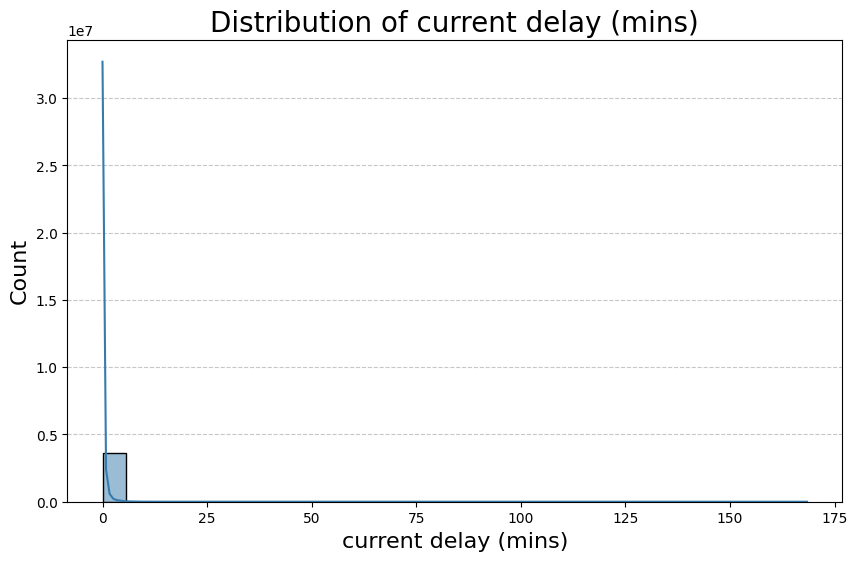

In [ ]:
# Step 1: Histograms for numerical columns
blue_color = sns.color_palette("Blues_d")[3]

for col in numerical_cols:
    plt.figure(figsize=(10, 6))
    sns.histplot(all_routes_df[col], kde=True, bins=30, color=blue_color)
    plt.title(f'Distribution of {col}', fontsize=20)
    plt.xlabel(col, fontsize=16)
    plt.ylabel('Count', fontsize=16)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.show()


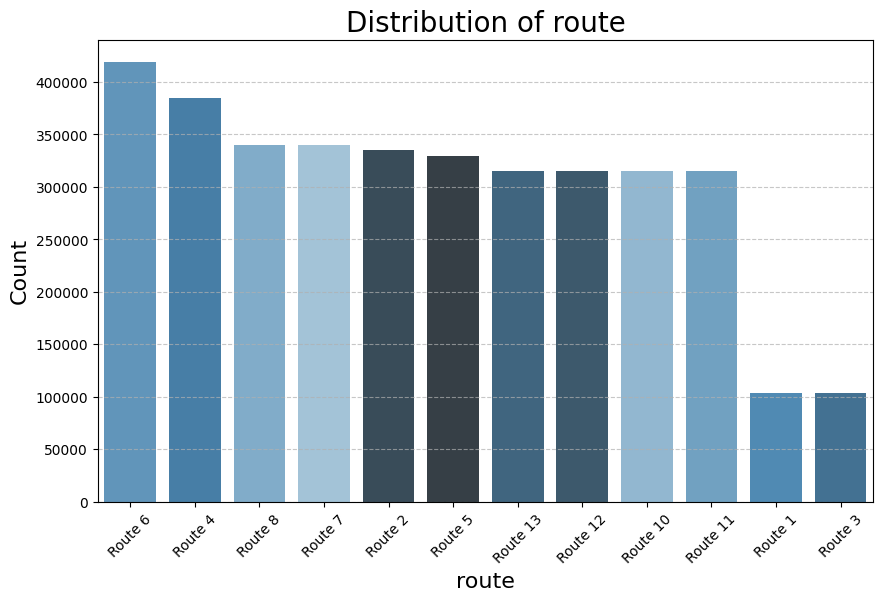

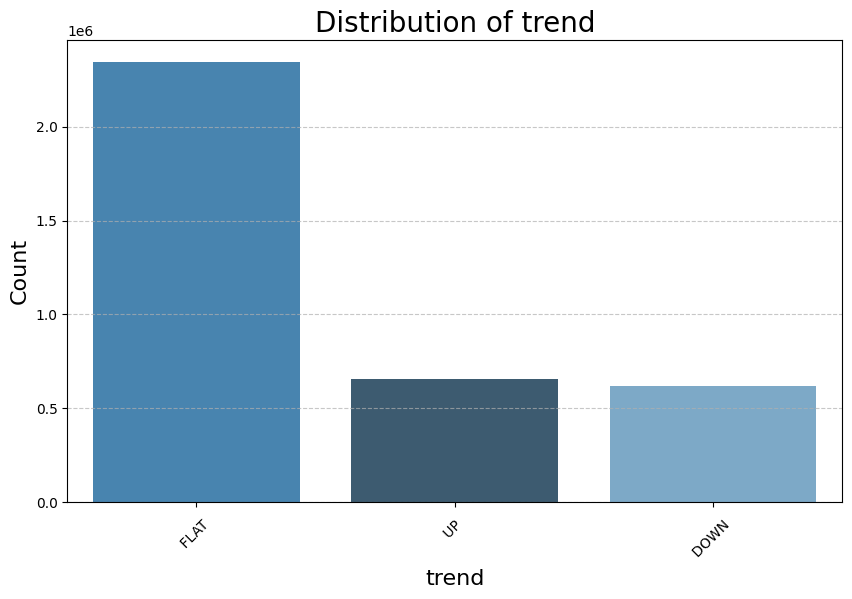

In [ ]:
# Step 2: Distribution plots for categorical columns

for col in categorical_cols:
    plt.figure(figsize=(10,6))
    sns.countplot(
        data=all_routes_df,
        x=col,
        hue=col,
        order=all_routes_df[col].value_counts().index,
        palette="Blues_d",
        legend=False
    )
    plt.xlabel(col, fontsize=16)
    plt.ylabel('Count', fontsize=16)
    plt.xticks(rotation=45)
    plt.title(f'Distribution of {col}', fontsize=20)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.show()

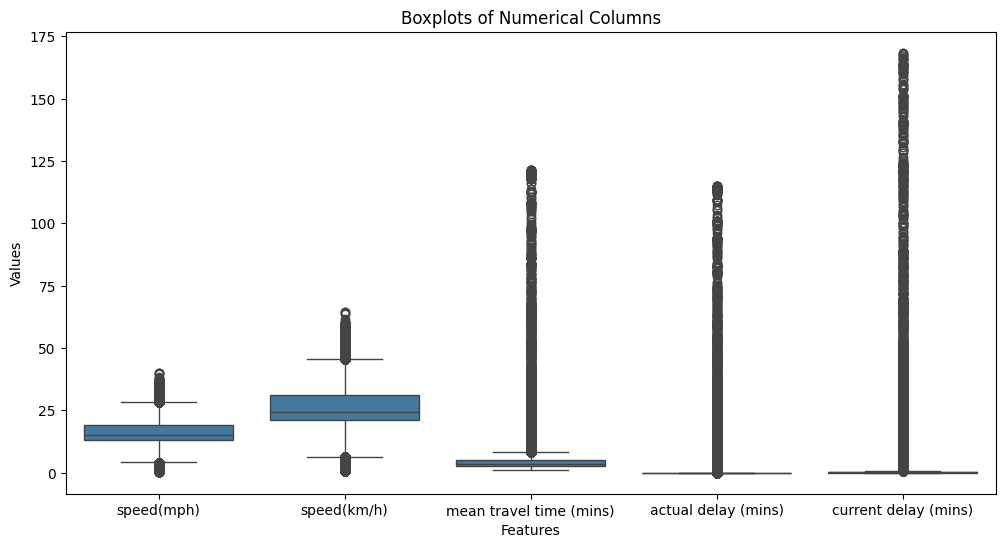

In [ ]:
# Step 4: Boxplots for numerical features

plt.figure(figsize=(12, 6))
sns.boxplot(data=all_routes_df[numerical_cols], palette=[blue_color]*len(numerical_cols))
plt.title("Boxplots of Numerical Columns")
plt.ylabel("Values")
plt.xlabel("Features")
plt.show()

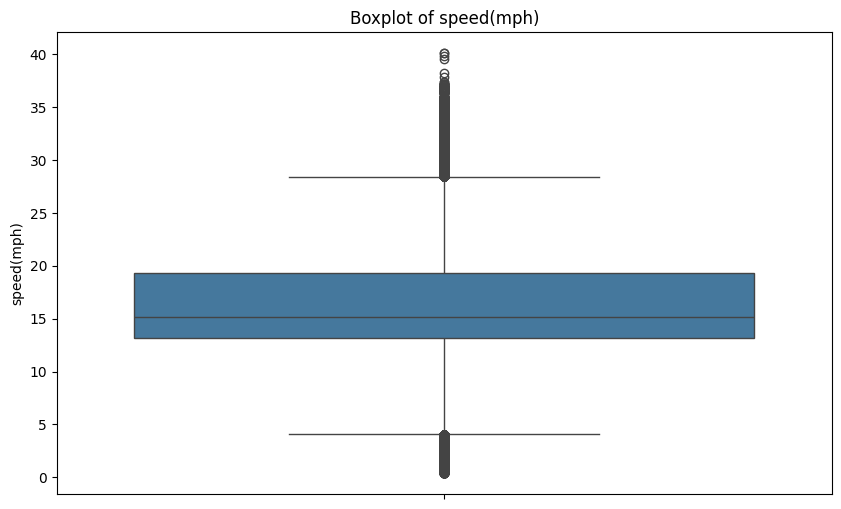

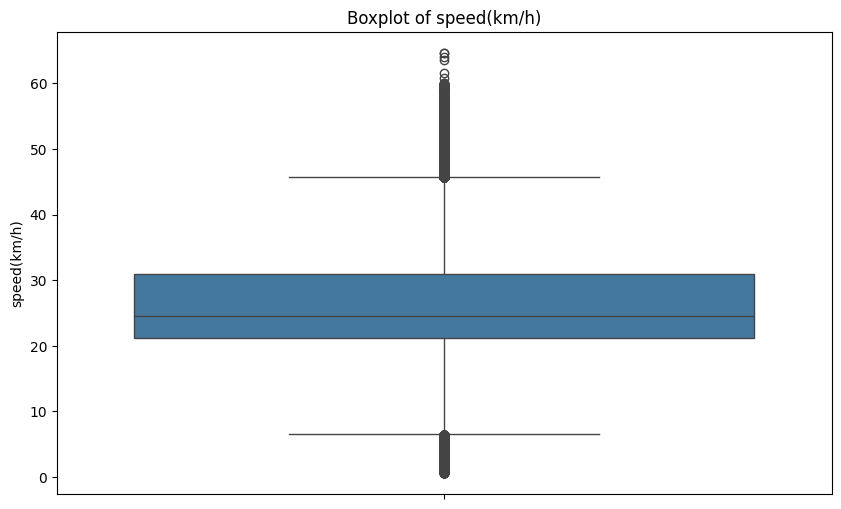

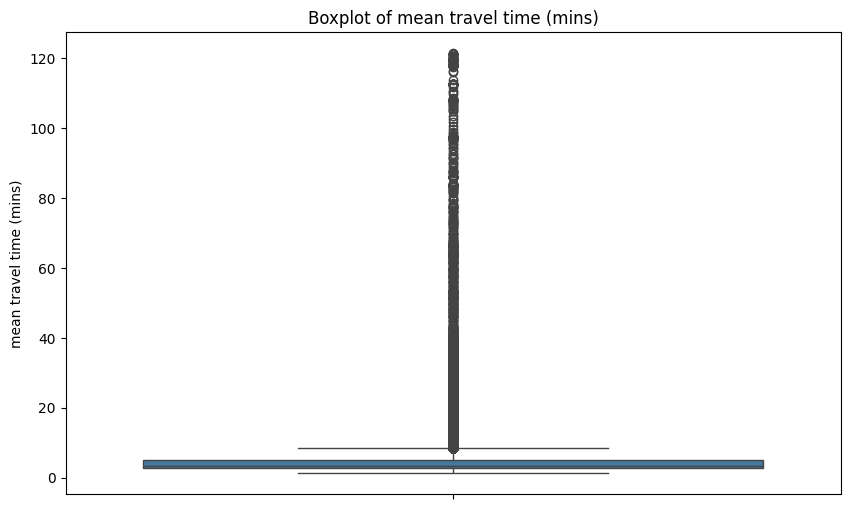

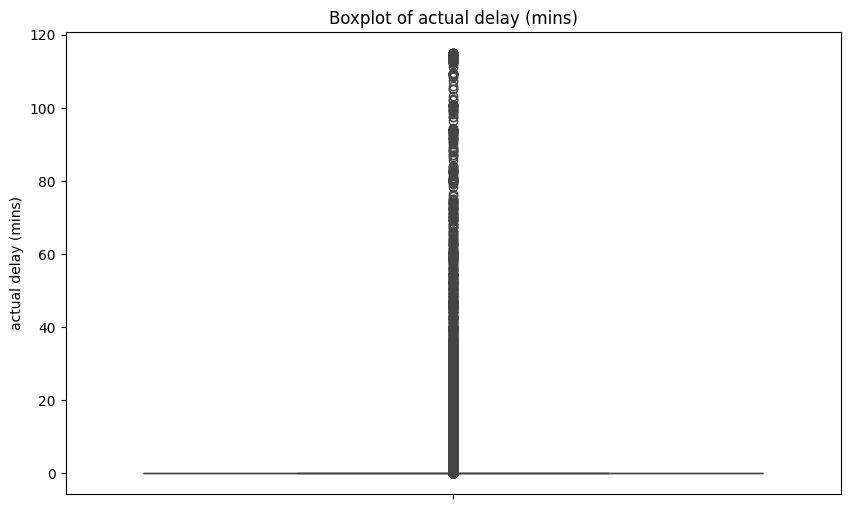

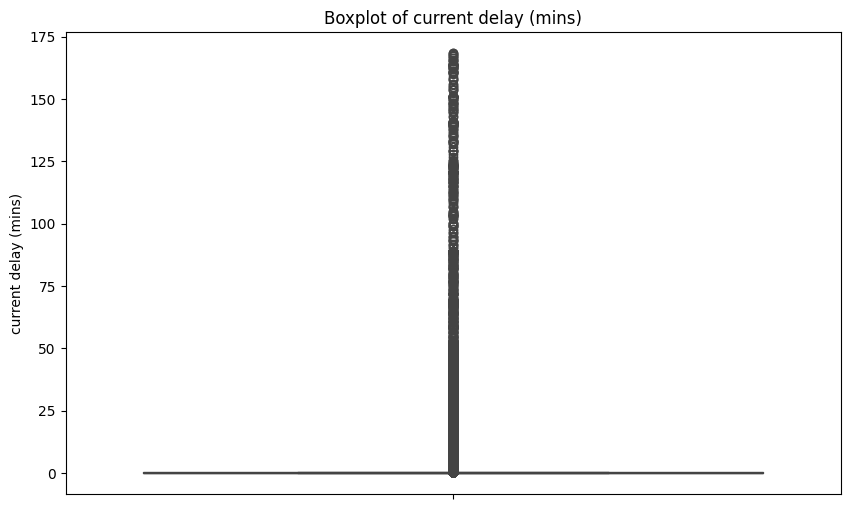

In [ ]:
# Step 4i: Separate boxplots

for col in numerical_cols:
    plt.figure(figsize=(10,6))
    sns.boxplot(y=all_routes_df[col], color=blue_color)
    plt.title(f'Boxplot of {col}')
    plt.ylabel(col)
    plt.show()

## Block 5: Feature Relationships

This step will explore relationships between key features in our dataset to better understand how different variables interact.

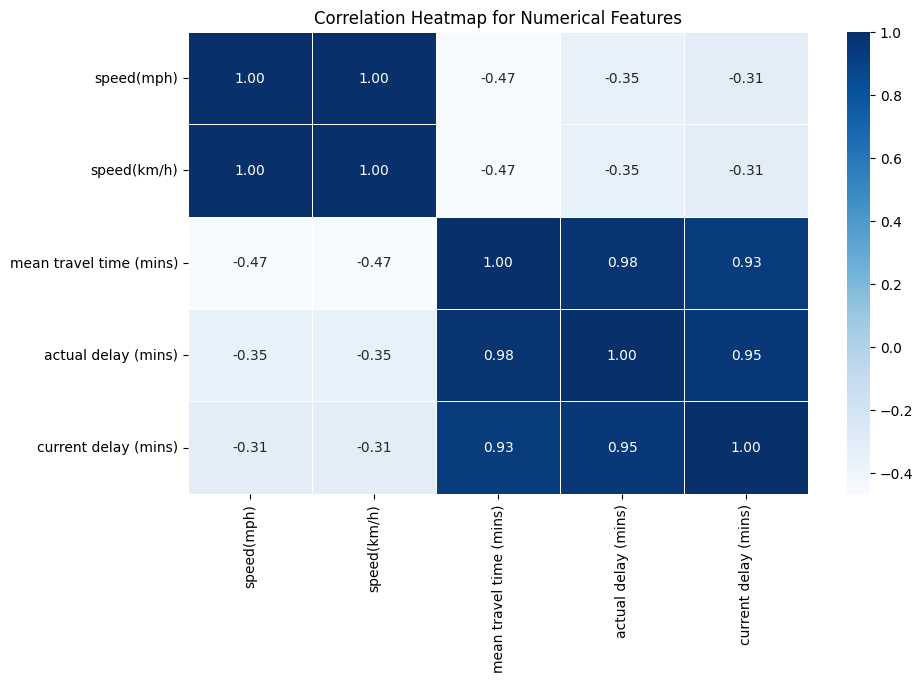

In [ ]:
# Step 1: Correlation analysis for numerical features

corr_matrix = all_routes_df[numerical_cols].corr()

plt.figure(figsize=(10,6))
sns.heatmap(corr_matrix, annot=True, cmap='Blues', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap for Numerical Features')
plt.show()

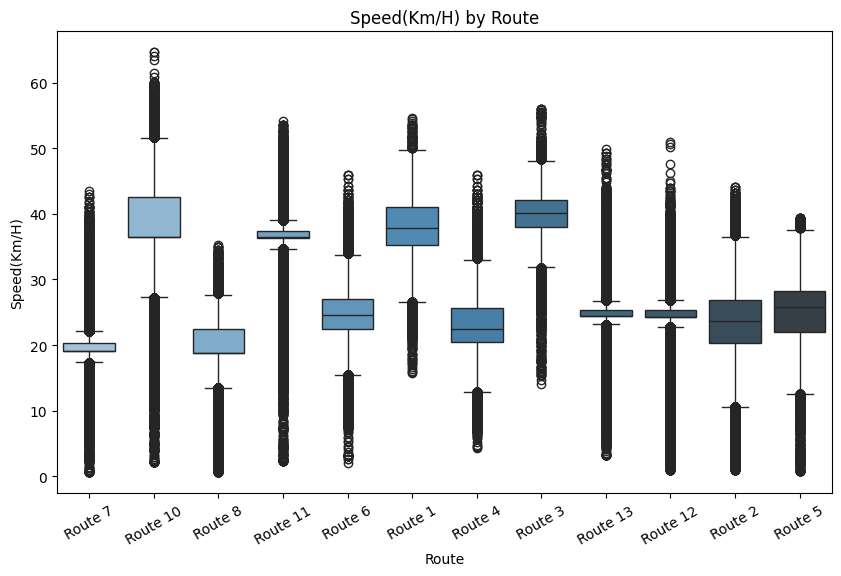

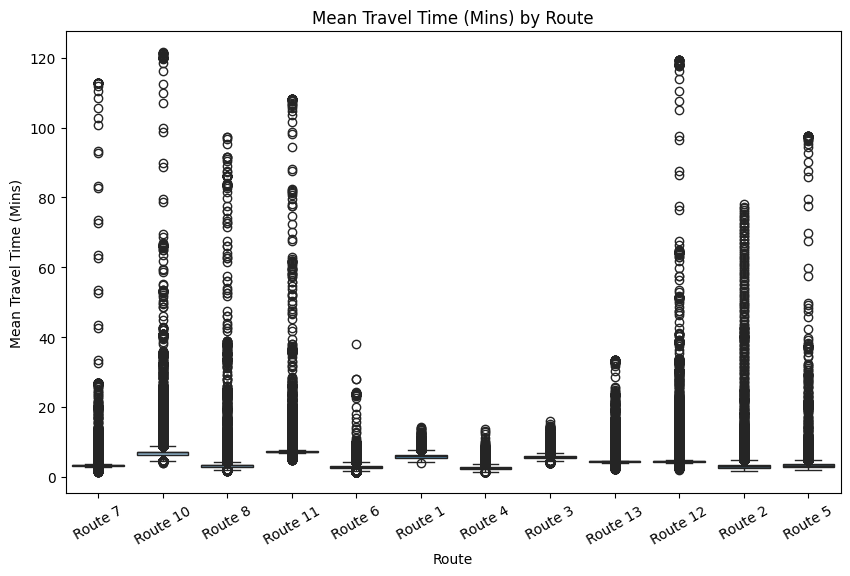

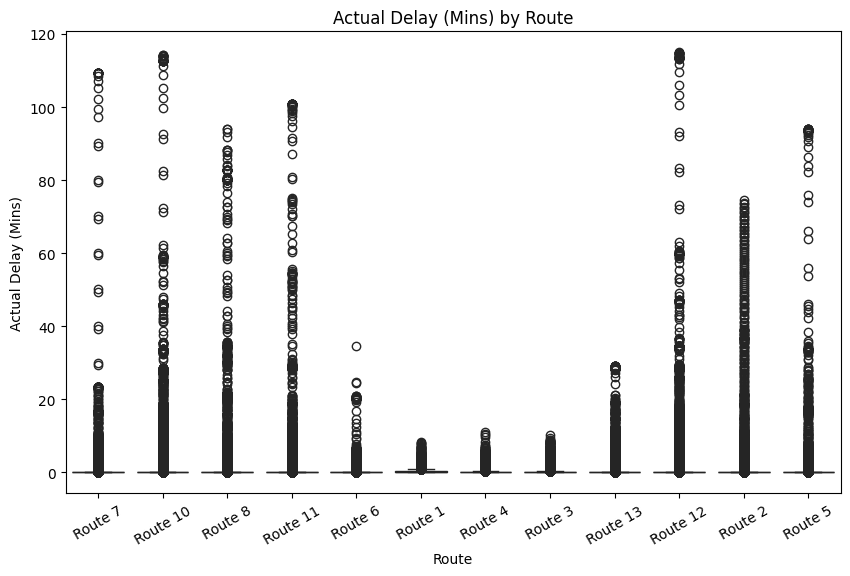

In [ ]:
# Step 2: Relationship between route and numerical columns

cols_to_analyze = ['speed(km/h)', 'mean travel time (mins)', 'actual delay (mins)']

for col in cols_to_analyze:
    plt.figure(figsize=(10,6))
    sns.boxplot(x='route', y=col, data=all_routes_df, palette='Blues_d', hue='route')
    plt.title(f'{col.title()} by Route')
    plt.xlabel('Route')
    plt.ylabel(col.title())
    plt.xticks(rotation=30)
    plt.show()

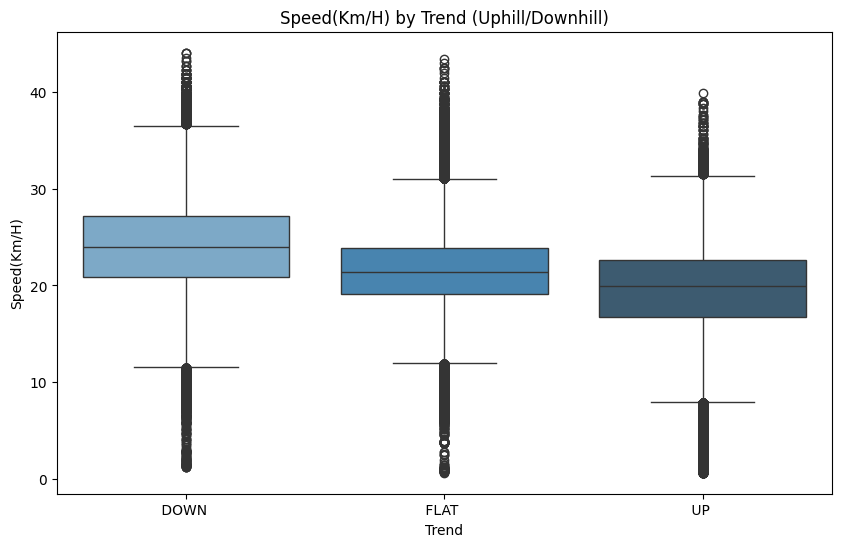

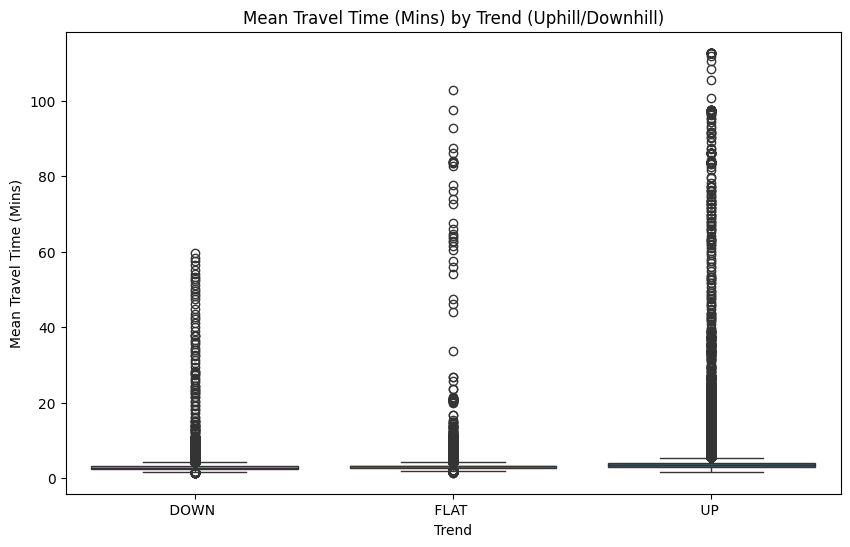

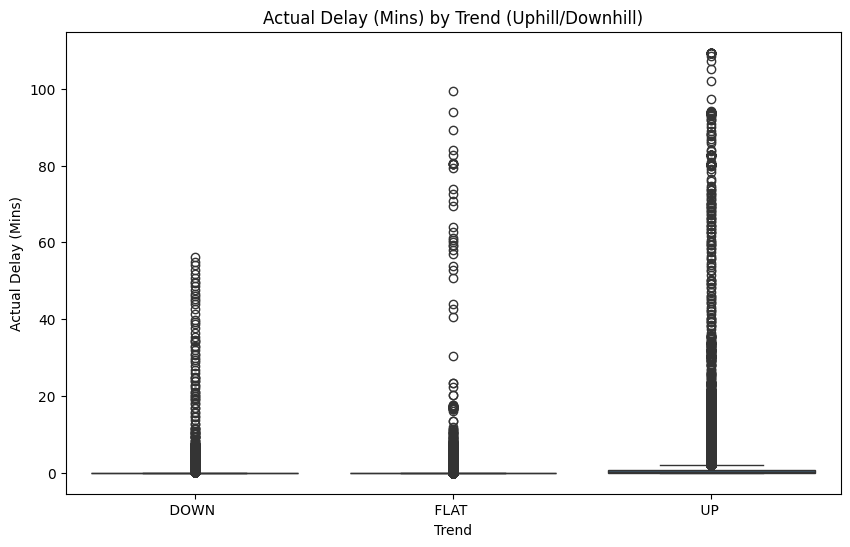

In [ ]:
# Step 3: Relationship between trend and numerical columns

for col in cols_to_analyze:
    plt.figure(figsize=(10,6))
    sns.boxplot(x='trend', y=col, data=all_routes_df, palette='Blues_d', hue='trend')
    plt.title(f'{col.title()} by Trend (Uphill/Downhill)')
    plt.xlabel('Trend')
    plt.ylabel(col.title())
    plt.show()

In [ ]:
# Step 4: Averages by route, sorted by actual delay

route_summary = (
    all_routes_df.groupby('route')[cols_to_analyze]
    .mean()
    .round(2)
    .sort_values('actual delay (mins)')
)
display(route_summary)

,speed(km/h),mean travel time (mins),actual delay (mins)
route,,,
Route 6,24.79,2.93,0.08
Route 5,25.42,3.18,0.09
Route 8,20.10,3.24,0.13
Route 7,19.85,3.32,0.14
Route 2,23.62,3.15,0.16
Route 4,23.14,2.63,0.16
Route 13,24.99,4.43,0.17
Route 3,39.96,5.63,0.17
Route 10,39.00,6.94,0.23


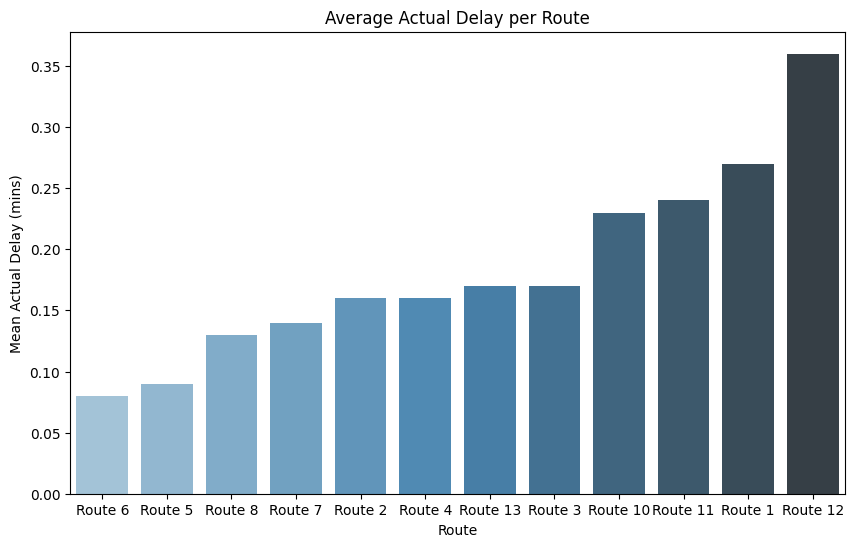

In [ ]:
# Visualize average delay per route
plt.figure(figsize=(10,6))
sns.barplot(x=route_summary.index, y=route_summary['actual delay (mins)'], palette='Blues_d', hue=route_summary.index)
plt.title('Average Actual Delay per Route')
plt.xlabel('Route')
plt.ylabel('Mean Actual Delay (mins)')
plt.show()

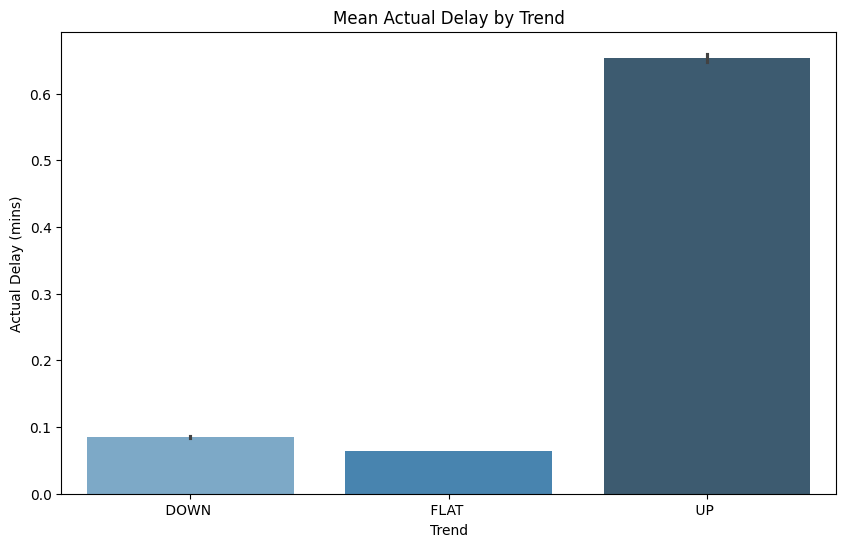

In [ ]:
# Step 5: Trend vs delay

plt.figure(figsize=(10,6))
sns.barplot(x='trend', y='actual delay (mins)', data=all_routes_df, palette='Blues_d', hue='trend', estimator='mean')
plt.title('Mean Actual Delay by Trend')
plt.xlabel('Trend')
plt.ylabel('Actual Delay (mins)')
plt.show()

In [ ]:
# Step 6: Month vs Route counts

# Extract year and month
all_routes_df['year_month'] = all_routes_df['calculation time'].dt.to_period('M')

# Count number of observations per route per month
route_month_counts = pd.crosstab(all_routes_df['route'], all_routes_df['year_month'])

# Sort by route number
route_month_counts = route_month_counts.reindex(
    sorted(route_month_counts.index, key=lambda x: int(''.join(filter(str.isdigit, x))))
)

route_month_counts

year_month,2024-11,2024-12,2025-01,2025-02,2025-03,2025-04,2025-05,2025-06,2025-07,2025-08,2025-09
route,,,,,,,,,,,
Route 1,120,44640,44580,14397,0,0,0,0,0,0,0
Route 2,120,44640,40863,37098,43185,40822,39756,43185,43333,2012,0
Route 3,120,44640,44580,14397,0,0,0,0,0,0,0
Route 4,120,44640,40863,37098,43185,40822,39756,43185,43333,42751,9171
Route 5,0,41979,44270,37463,35395,38829,35405,32049,25408,30031,8232
Route 6,0,41978,44390,74561,78580,48716,35405,32049,25408,30030,8235
Route 7,120,44408,44483,37687,41635,43026,39605,43073,44091,2173,0
Route 8,120,44408,44483,37687,41635,43026,39605,43073,44091,2174,0
Route 10,120,44640,43738,37761,44078,41011,30436,43126,30411,0,0


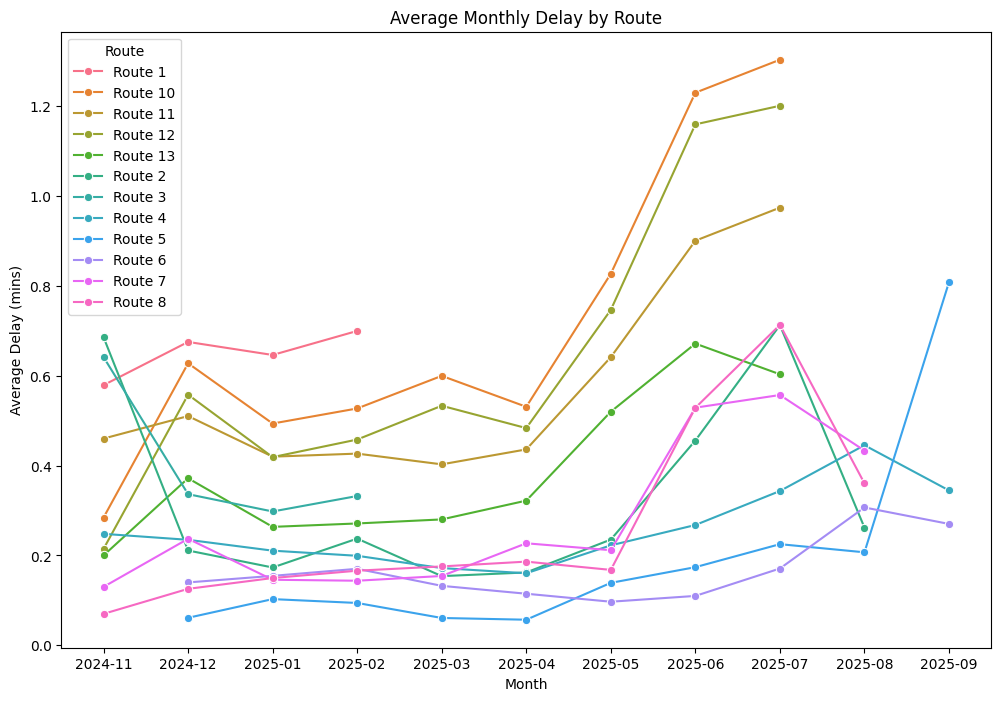

In [ ]:
# Average monthly delay by route

# Extract year-month
all_routes_df['year_month'] = all_routes_df['calculation time'].dt.to_period('M')

# Compute average delay per route per month
avg_delay = all_routes_df.groupby(['route','year_month'])['current delay (mins)'].mean().reset_index()

# Convert year_month to string for plotting
avg_delay['year_month_str'] = avg_delay['year_month'].astype(str)


plt.figure(figsize=(12,8))
sns.lineplot(
    data=avg_delay,
    x='year_month_str',
    y='current delay (mins)',
    hue='route',
    marker='o'
)

plt.title('Average Monthly Delay by Route')
plt.xlabel('Month')
plt.ylabel('Average Delay (mins)')
plt.legend(title='Route')
plt.show()


# Dataset Review: PARKING (2023 & 2024)
Coded by: Srijana

In [ ]:
import pandas as pd # importing pandas dataframe

#BLOCK1
Block 1: Loading and Overview of the Dataset

In this block, we load the parking datasets for 2023 and 2024 and perform an initial overview to understand their structure.

Load Excel files into Pandas DataFrames.

Display the first few rows using .head() to inspect the structure.

Check column names, data types, and non-null counts using .info().

Identify missing values using .isnull().sum().

Check the shape of the dataset and basic statistics to understand its size and content.

In [ ]:
parking_data_2023 = pd.read_excel('2023 parking data.xlsx') #loading parking dats 2023 xl datasets
parking_summer_2024 = pd.read_excel('2024 summer parking.xlsx') # loading parking summer 2024 xl datsets




In [ ]:
parking_data_2023.shape[0]


150845

In [ ]:
parking_summer_2024.shape[0]

163327

In [ ]:
# printing first few rows /head of parking data 2023 the datsets
print(parking_data_2023.head())

              Fee                Date       Starting date            End date  \
0    Regular Rate 2023-08-31 19:53:16 2023-08-31 19:53:16 2023-08-31 20:00:00   
1    Regular Rate 2023-08-31 19:51:55 2023-08-31 19:51:55 2023-08-31 20:00:00   
2    Regular Rate 2023-08-31 19:51:37 2023-08-31 19:51:37 2023-08-31 20:00:00   
3    Regular Rate 2023-08-31 19:51:46 2023-08-31 19:51:46 2023-08-31 20:00:00   
4  Residents Rate 2023-08-31 19:50:01 2023-08-31 19:50:01 2023-08-31 20:00:00   

   Payment type  Amount    Plate  
0     Bank card     2.5   MR631A  
1     Bank card     2.5  CHP4604  
2     Bank card     2.5   RB014K  
3     Bank card     2.5   J55439  
4  Pay by phone     0.0   EDS309  


In [ ]:
# printing first few rows /head of parking summer 2024 the datsets
print(parking_summer_2024.head())

            Fee                Date       Starting date            End date  \
0  Regular Rate 2024-08-31 19:33:14 2024-08-31 19:33:14 2024-08-31 20:00:00   
1  Regular Rate 2024-08-31 18:54:17 2024-08-31 18:54:17 2024-08-31 20:00:00   
2  Regular Rate 2024-08-31 19:56:19 2024-08-31 19:56:19 2024-08-31 20:00:00   
3  Regular Rate 2024-08-31 19:54:21 2024-08-31 19:54:21 2024-08-31 20:00:00   
4  Regular Rate 2024-08-31 19:52:41 2024-08-31 19:52:41 2024-08-31 20:00:00   

   Payment type  Amount    Plate  
0          Cash     3.0   TN728M  
1          Cash     9.0  BPK7480  
2     Bank card     3.0  CSR5377  
3  Pay by phone     3.0  BJP0985  
4     Bank card     3.0  CMK3795  


In [ ]:
print("Columns in 2023 dataset:")
print(parking_data_2023.columns.tolist())

print("\nColumns in 2024 summer dataset:")
print(parking_summer_2024.columns.tolist())

Columns in 2023 dataset:
['Fee', 'Date', 'Starting date', 'End date', 'Payment type', 'Amount', 'Plate']

Columns in 2024 summer dataset:
['Fee', 'Date', 'Starting date', 'End date', 'Payment type', 'Amount', 'Plate']


In [ ]:
parking_data_2023.info()
print(parking_data_2023.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150845 entries, 0 to 150844
Data columns (total 7 columns):
 #   Column         Non-Null Count   Dtype         
---  ------         --------------   -----         
 0   Fee            150845 non-null  object        
 1   Date           150845 non-null  datetime64[ns]
 2   Starting date  150845 non-null  datetime64[ns]
 3   End date       150845 non-null  datetime64[ns]
 4   Payment type   150845 non-null  object        
 5   Amount         150845 non-null  float64       
 6   Plate          150845 non-null  object        
dtypes: datetime64[ns](3), float64(1), object(3)
memory usage: 8.1+ MB
Fee              0
Date             0
Starting date    0
End date         0
Payment type     0
Amount           0
Plate            0
dtype: int64


In [ ]:
# Basic info
parking_summer_2024.info()


# Check missing values
print(parking_summer_2024.isnull().sum())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 163327 entries, 0 to 163326
Data columns (total 7 columns):
 #   Column         Non-Null Count   Dtype         
---  ------         --------------   -----         
 0   Fee            163327 non-null  object        
 1   Date           163327 non-null  datetime64[ns]
 2   Starting date  163327 non-null  datetime64[ns]
 3   End date       163327 non-null  datetime64[ns]
 4   Payment type   163327 non-null  object        
 5   Amount         163327 non-null  float64       
 6   Plate          163327 non-null  object        
dtypes: datetime64[ns](3), float64(1), object(3)
memory usage: 8.7+ MB
Fee              0
Date             0
Starting date    0
End date         0
Payment type     0
Amount           0
Plate            0
dtype: int64


In [ ]:
# Unique Fee types
unique_fee_types = parking_data_2023['Fee'].unique()
print("Unique Fee types:", unique_fee_types)

# Unique Payment types
unique_payment_types = parking_data_2023['Payment type'].unique()
print("Unique Payment types:", unique_payment_types)


Unique Fee types: ['Regular Rate' 'Residents Rate']
Unique Payment types: ['Bank card' 'Pay by phone' 'Cash']


#Block 2: Data Cleaning and Preparation

This block prepares the datasets for analysis by handling duplicates, formatting date columns, and calculating parking duration.

Convert date columns (Date, Starting date, End date) to datetime format.

Identify and remove duplicate rows to avoid skewing analysis.

Calculate Parking Duration (min) as the difference between End date and Starting date.

Check for missing or invalid values and flag anomalies (e.g., 0-minute parking).

Separate cleaned datasets from anomalous rows for further analysis

In [ ]:
duplicate_rows_2023 = parking_data_2023[parking_data_2023.duplicated()]
print("Number of duplicate rows in 2023 dataset:", duplicate_rows_2023.shape[0])
print(duplicate_rows_2023)

# Check duplicates in 2024 summer parking data
duplicate_rows_2024 = parking_summer_2024[parking_summer_2024.duplicated()]
print("Number of duplicate rows in 2024 dataset:", duplicate_rows_2024.shape[0])
print(duplicate_rows_2024)

Number of duplicate rows in 2023 dataset: 1
                Fee                Date       Starting date  \
64506  Regular Rate 2023-08-05 11:30:48 2023-08-05 11:30:48   

                 End date Payment type  Amount   Plate  
64506 2023-08-05 20:00:00    Bank card    42.5  085KFW  
Number of duplicate rows in 2024 dataset: 2
                Fee                Date       Starting date  \
90047  Regular Rate 2024-07-28 19:17:38 2024-07-28 19:17:38   
95260  Regular Rate 2024-07-26 19:29:59 2024-07-26 19:29:59   

                 End date Payment type  Amount   Plate  
90047 2024-07-28 20:00:00    Bank card     6.0  372NME  
95260 2024-07-26 19:59:00    Bank card     3.0  A27379  


In [ ]:
parking_data_2023[parking_data_2023.duplicated(subset=['Fee','Date','Starting date','End date','Payment type','Amount','Plate'])]


,Fee,Date,Starting date,End date,Payment type,Amount,Plate
64506,Regular Rate,2023-08-05 11:30:48,2023-08-05 11:30:48,2023-08-05 20:00:00,Bank card,42.5,085KFW


In [ ]:
# Drop exact duplicates in 2023 dataset
parking_data_2023 = parking_data_2023.drop_duplicates()
print("Number of rows after dropping duplicates in 2023 dataset:", parking_data_2023.shape[0])

# Drop exact duplicates in 2024 summer dataset
parking_summer_2024 = parking_summer_2024.drop_duplicates()
print("Number of rows after dropping duplicates in 2024 dataset:", parking_summer_2024.shape[0])


Number of rows after dropping duplicates in 2023 dataset: 150844
Number of rows after dropping duplicates in 2024 dataset: 163325


In [ ]:
# Calculate Parking Duration in minutes with 2 decimal places
parking_data_2023['Parking Duration (min)'] = abs((parking_data_2023['End date'] - parking_data_2023['Starting date']).dt.total_seconds() / 60).round(2)
parking_summer_2024['Parking Duration (min)'] = abs((parking_summer_2024['End date'] - parking_summer_2024['Starting date']).dt.total_seconds() / 60).round(2)

In [ ]:
parking_summer_2024.columns.tolist()

['Fee',
 'Date',
 'Starting date',
 'End date',
 'Payment type',
 'Amount',
 'Plate',
 'Parking Duration (min)']

In [ ]:
parking_summer_2024.info()
parking_data_2023.info()

<class 'pandas.core.frame.DataFrame'>
Index: 163325 entries, 0 to 163326
Data columns (total 8 columns):
 #   Column                  Non-Null Count   Dtype         
---  ------                  --------------   -----         
 0   Fee                     163325 non-null  object        
 1   Date                    163325 non-null  datetime64[ns]
 2   Starting date           163325 non-null  datetime64[ns]
 3   End date                163325 non-null  datetime64[ns]
 4   Payment type            163325 non-null  object        
 5   Amount                  163325 non-null  float64       
 6   Plate                   163325 non-null  object        
 7   Parking Duration (min)  163325 non-null  float64       
dtypes: datetime64[ns](3), float64(2), object(3)
memory usage: 11.2+ MB
<class 'pandas.core.frame.DataFrame'>
Index: 150844 entries, 0 to 150844
Data columns (total 8 columns):
 #   Column                  Non-Null Count   Dtype         
---  ------                  --------------   -

In [ ]:
parking_data_2023.head(15)

,Fee,Date,Starting date,End date,Payment type,Amount,Plate,Parking Duration (min)
0,Regular Rate,2023-08-31 19:53:16,2023-08-31 19:53:16,2023-08-31 20:00:00,Bank card,2.5,MR631A,6.73
1,Regular Rate,2023-08-31 19:51:55,2023-08-31 19:51:55,2023-08-31 20:00:00,Bank card,2.5,CHP4604,8.08
2,Regular Rate,2023-08-31 19:51:37,2023-08-31 19:51:37,2023-08-31 20:00:00,Bank card,2.5,RB014K,8.38
3,Regular Rate,2023-08-31 19:51:46,2023-08-31 19:51:46,2023-08-31 20:00:00,Bank card,2.5,J55439,8.23
4,Residents Rate,2023-08-31 19:50:01,2023-08-31 19:50:01,2023-08-31 20:00:00,Pay by phone,0.0,EDS309,9.98
5,Residents Rate,2023-08-31 19:49:53,2023-08-31 19:49:53,2023-08-31 20:00:00,Pay by phone,0.0,BVL3065,10.12
6,Regular Rate,2023-08-31 19:45:39,2023-08-31 19:45:39,2023-08-31 20:00:00,Bank card,2.5,NM029H,14.35
7,Regular Rate,2023-08-31 19:45:39,2023-08-31 19:45:39,2023-08-31 20:00:00,Bank card,2.5,BLX1813,14.35
8,Regular Rate,2023-08-31 19:45:16,2023-08-31 19:45:16,2023-08-31 20:00:00,Bank card,2.5,BCV7577,14.73
9,Regular Rate,2023-08-31 19:42:43,2023-08-31 19:42:43,2023-08-31 20:00:00,Bank card,2.5,A24832,17.28


In [ ]:
parking_summer_2024.head()


,Fee,Date,Starting date,End date,Payment type,Amount,Plate,Parking Duration (min)
0,Regular Rate,2024-08-31 19:33:14,2024-08-31 19:33:14,2024-08-31 20:00:00,Cash,3.0,TN728M,26.77
1,Regular Rate,2024-08-31 18:54:17,2024-08-31 18:54:17,2024-08-31 20:00:00,Cash,9.0,BPK7480,65.72
2,Regular Rate,2024-08-31 19:56:19,2024-08-31 19:56:19,2024-08-31 20:00:00,Bank card,3.0,CSR5377,3.68
3,Regular Rate,2024-08-31 19:54:21,2024-08-31 19:54:21,2024-08-31 20:00:00,Pay by phone,3.0,BJP0985,5.65
4,Regular Rate,2024-08-31 19:52:41,2024-08-31 19:52:41,2024-08-31 20:00:00,Bank card,3.0,CMK3795,7.32


In [ ]:
avg_duration_2023 = parking_data_2023['Parking Duration (min)'].mean()
print("Average parking duration in 2023:", round(avg_duration_2023, 2), "minutes")

Average parking duration in 2023: 117.85 minutes


In [ ]:
avg_duration_2024 = parking_summer_2024['Parking Duration (min)'].mean()
print("Average parking duration in 2024:", round(avg_duration_2024, 2), "minutes")


Average parking duration in 2024: 119.0 minutes


#Block 3: Descriptive Statistics and Categorical Distribution

In this block, we perform exploratory analysis on numerical and categorical columns.

Generate summary statistics for numerical columns (Amount, Parking Duration (min)) using .describe().

Display frequency counts for categorical columns (Fee, Payment type) using .value_counts().

Flag and separate anomalies such as 0-minute parking with payment.

Prepare datasets for outlier detection and visualization in the next steps.

In [ ]:
# Numerical columns
numerical_cols = ['Amount', 'Parking Duration (min)']

# Categorical columns
categorical_cols = ['Fee', 'Payment type']


In [ ]:
# Create a new deduplicated DataFrame based on Plate
dedup_df_2023 = parking_data_2023.drop_duplicates(subset='Plate', keep='first')

# Show first 5 rows of the deduplicated DataFrame
print(dedup_df_2023.head())

# Compare shapes to see how many duplicates were removed
print("Original dataset shape:", parking_data_2023.shape)
print("Deduplicated dataset shape:", dedup_df_2023.shape)


              Fee                Date       Starting date            End date  \
0    Regular Rate 2023-08-31 19:53:16 2023-08-31 19:53:16 2023-08-31 20:00:00   
1    Regular Rate 2023-08-31 19:51:55 2023-08-31 19:51:55 2023-08-31 20:00:00   
2    Regular Rate 2023-08-31 19:51:37 2023-08-31 19:51:37 2023-08-31 20:00:00   
3    Regular Rate 2023-08-31 19:51:46 2023-08-31 19:51:46 2023-08-31 20:00:00   
4  Residents Rate 2023-08-31 19:50:01 2023-08-31 19:50:01 2023-08-31 20:00:00   

   Payment type  Amount    Plate  Parking Duration (min)  
0     Bank card     2.5   MR631A                    6.73  
1     Bank card     2.5  CHP4604                    8.08  
2     Bank card     2.5   RB014K                    8.38  
3     Bank card     2.5   J55439                    8.23  
4  Pay by phone     0.0   EDS309                    9.98  
Original dataset shape: (150844, 8)
Deduplicated dataset shape: (88869, 8)


In [ ]:
# Create a new deduplicated DataFrame for 2024 based on Plate
dedup_df_2024 = parking_summer_2024.drop_duplicates(subset='Plate', keep='first')

# Show first 5 rows of the deduplicated DataFrame
print(dedup_df_2024.head())

# Compare shapes to see how many duplicates were removed
print("Original 2024 dataset shape:", parking_summer_2024.shape)
print("Deduplicated 2024 dataset shape:", dedup_df_2024.shape)
#we are seeing paying 3 dollars just for 5.6d min of staying and same 3 $ for 26.77min > the answer is that minimun payment might be 3$ thats why might be less than halg an hour it might be 3$


            Fee                Date       Starting date            End date  \
0  Regular Rate 2024-08-31 19:33:14 2024-08-31 19:33:14 2024-08-31 20:00:00   
1  Regular Rate 2024-08-31 18:54:17 2024-08-31 18:54:17 2024-08-31 20:00:00   
2  Regular Rate 2024-08-31 19:56:19 2024-08-31 19:56:19 2024-08-31 20:00:00   
3  Regular Rate 2024-08-31 19:54:21 2024-08-31 19:54:21 2024-08-31 20:00:00   
4  Regular Rate 2024-08-31 19:52:41 2024-08-31 19:52:41 2024-08-31 20:00:00   

   Payment type  Amount    Plate  Parking Duration (min)  
0          Cash     3.0   TN728M                   26.77  
1          Cash     9.0  BPK7480                   65.72  
2     Bank card     3.0  CSR5377                    3.68  
3  Pay by phone     3.0  BJP0985                    5.65  
4     Bank card     3.0  CMK3795                    7.32  
Original 2024 dataset shape: (163325, 8)
Deduplicated 2024 dataset shape: (94543, 8)


In [ ]:
# Summary statistics for numerical columns in 2023
numerical_cols = ['Amount', 'Parking Duration (min)']
summary_2023 = parking_data_2023[numerical_cols].describe().round(2)
print("Summary statistics for 2023:\n", summary_2023)


Summary statistics for 2023:
           Amount  Parking Duration (min)
count  150844.00               150844.00
mean        9.38                  117.85
std         7.70                   88.31
min         0.00                    0.00
25%         5.00                   59.53
50%        10.00                  119.15
75%        12.50                  155.17
max        60.00                 1200.00


In [ ]:
# For 2023 dataset
negative_duration_2023 = parking_data_2023[parking_data_2023['Parking Duration (min)'] < 0]
print(negative_duration_2023)

# For 2024 dataset
negative_duration_2024 = parking_summer_2024[parking_summer_2024['Parking Duration (min)'] < 0]
print(negative_duration_2024)

Empty DataFrame
Columns: [Fee, Date, Starting date, End date, Payment type, Amount, Plate, Parking Duration (min)]
Index: []
Empty DataFrame
Columns: [Fee, Date, Starting date, End date, Payment type, Amount, Plate, Parking Duration (min)]
Index: []


In [ ]:
# Check rows where Parking Duration is 0
zero_duration_rows = parking_data_2023[parking_data_2023['Parking Duration (min)'] == 0]
print(zero_duration_rows)

                   Fee                Date       Starting date  \
2363    Residents Rate 2023-08-30 17:38:26 2023-08-30 18:36:00   
2712      Regular Rate 2023-08-30 16:01:03 2023-08-30 17:45:00   
14599   Residents Rate 2023-08-25 16:05:22 2023-08-25 16:18:00   
14602   Residents Rate 2023-08-25 16:04:44 2023-08-25 16:18:00   
16863   Residents Rate 2023-08-24 16:46:02 2023-08-24 16:58:00   
36134     Regular Rate 2023-08-16 18:39:22 2023-08-16 20:00:00   
46410     Regular Rate 2023-08-12 15:34:12 2023-08-12 15:40:00   
55029   Residents Rate 2023-08-09 10:19:38 2023-08-09 10:32:00   
57949   Residents Rate 2023-08-07 18:34:33 2023-08-07 18:34:33   
73587   Residents Rate 2023-08-01 15:02:48 2023-08-01 15:02:48   
82278     Regular Rate 2023-07-28 19:33:09 2023-07-28 19:48:00   
82468     Regular Rate 2023-07-28 18:32:16 2023-07-28 18:51:00   
101515  Residents Rate 2023-07-21 11:35:41 2023-07-21 12:32:00   
107745    Regular Rate 2023-07-18 15:26:33 2023-07-18 16:48:00   
109890    

In [ ]:
# Check rows where Parking Duration is 0
zero_duration_rows = parking_summer_2024[parking_summer_2024['Parking Duration (min)'] == 0]
print(zero_duration_rows)

                   Fee                Date       Starting date  \
3860      Regular Rate 2024-08-30 15:08:44 2024-08-30 18:06:00   
5153    Residents Rate 2024-08-30 10:44:12 2024-08-30 10:49:00   
5241    Residents Rate 2024-08-30 10:21:33 2024-08-30 10:25:00   
11722     Regular Rate 2024-08-27 15:29:28 2024-08-27 19:57:00   
24814     Regular Rate 2024-08-22 15:44:09 2024-08-22 18:43:00   
26463     Regular Rate 2024-08-21 19:52:29 2024-08-21 19:56:00   
38819   Residents Rate 2024-08-17 12:09:35 2024-08-17 12:11:00   
41046     Regular Rate 2024-08-16 13:27:51 2024-08-16 13:34:00   
44880     Regular Rate 2024-08-14 19:43:29 2024-08-14 19:52:00   
45557     Regular Rate 2024-08-14 16:33:04 2024-08-14 20:00:00   
56753     Regular Rate 2024-08-10 15:11:14 2024-08-10 15:18:00   
58294     Regular Rate 2024-08-09 19:52:34 2024-08-09 19:52:34   
72110     Regular Rate 2024-08-04 17:30:13 2024-08-04 19:28:00   
72143     Regular Rate 2024-08-04 17:22:29 2024-08-04 19:20:00   
76227     

In [ ]:
# Summary statistics for numerical columns in 2024
numerical_cols = ['Amount', 'Parking Duration (min)']
summary_2024 = parking_summer_2024[numerical_cols].describe().round(2)
print("Summary statistics for 2023:\n", summary_2024)


Summary statistics for 2023:
           Amount  Parking Duration (min)
count  163325.00               163325.00
mean       11.39                  119.00
std         9.46                   90.61
min         0.00                    0.00
25%         6.00                   59.53
50%        12.00                  119.15
75%        15.00                  156.03
max        72.00                 1170.00


In [ ]:
negative_duration_2023 = parking_data_2023[parking_data_2023['Parking Duration (min)'] < 0]

print("Number of negative durations in 2023:", negative_duration_2023.shape[0])
negative_duration_2023.head()
negative_duration_2024  = parking_summer_2024[parking_summer_2024['Parking Duration (min)'] < 0]

print("Number of negative durations in 2024:", negative_duration_2024.shape[0])

Number of negative durations in 2023: 0
Number of negative durations in 2024: 0


In [ ]:
parking_data_2023.shape[0]
parking_summer_2024.shape[0]

163325

In [ ]:
# 2023 dataset
parking_data_2023['Zero_Duration_Flag'] = (
    (parking_data_2023['Parking Duration (min)'] == 0) &
    (parking_data_2023['Amount'] > 0)
)

# 2024 dataset
parking_summer_2024['Zero_Duration_Flag'] = (
    (parking_summer_2024['Parking Duration (min)'] == 0) &
    (parking_summer_2024['Amount'] > 0)
)



In [ ]:
parking_data_2023.shape[0]

150844

In [ ]:
print("2023 flagged 0-min anomalies:", parking_data_2023['Zero_Duration_Flag'].sum())
print("2024 flagged 0-min anomalies:", parking_summer_2024['Zero_Duration_Flag'].sum())


2023 flagged 0-min anomalies: 11
2024 flagged 0-min anomalies: 16


In [ ]:
parking_data_2023.head()

,Fee,Date,Starting date,End date,Payment type,Amount,Plate,Parking Duration (min),Zero_Duration_Flag
0,Regular Rate,2023-08-31 19:53:16,2023-08-31 19:53:16,2023-08-31 20:00:00,Bank card,2.5,MR631A,6.73,False
1,Regular Rate,2023-08-31 19:51:55,2023-08-31 19:51:55,2023-08-31 20:00:00,Bank card,2.5,CHP4604,8.08,False
2,Regular Rate,2023-08-31 19:51:37,2023-08-31 19:51:37,2023-08-31 20:00:00,Bank card,2.5,RB014K,8.38,False
3,Regular Rate,2023-08-31 19:51:46,2023-08-31 19:51:46,2023-08-31 20:00:00,Bank card,2.5,J55439,8.23,False
4,Residents Rate,2023-08-31 19:50:01,2023-08-31 19:50:01,2023-08-31 20:00:00,Pay by phone,0.0,EDS309,9.98,False


In [ ]:
clean_df_2023 = parking_data_2023.copy()
clean_df_2024 = parking_summer_2024.copy()


In [ ]:
clean_df_2023.shape[0]


150844

In [ ]:
clean_df_2024.shape[0]

163325

In [ ]:
# 2023
clean_df_2023[['Amount', 'Parking Duration (min)']].describe()




,Amount,Parking Duration (min)
count,150844.000000,150844.000000
mean,9.377218,117.850846
std,7.695193,88.307184
min,0.000000,0.000000
25%,5.000000,59.530000
50%,10.000000,119.150000
75%,12.500000,155.170000
max,60.000000,1200.000000


In [ ]:
# 2024
clean_df_2024[['Amount', 'Parking Duration (min)']].describe()

,Amount,Parking Duration (min)
count,163325.000000,163325.000000
mean,11.391514,119.003171
std,9.459649,90.607715
min,0.000000,0.000000
25%,6.000000,59.530000
50%,12.000000,119.150000
75%,15.000000,156.030000
max,72.000000,1170.000000


In [ ]:
# Fee type distribution
print("2023 Fee type distribution:\n", clean_df_2023['Fee'].value_counts())
print("2024 Fee type distribution:\n", clean_df_2024['Fee'].value_counts())




2023 Fee type distribution:
 Fee
Regular Rate      135040
Residents Rate     15804
Name: count, dtype: int64
2024 Fee type distribution:
 Fee
Regular Rate      147483
Residents Rate     15842
Name: count, dtype: int64


In [ ]:
# Payment type distribution
print("2023 Payment type distribution:\n", clean_df_2023['Payment type'].value_counts())
print("2024 Payment type distribution:\n", clean_df_2024['Payment type'].value_counts())

2023 Payment type distribution:
 Payment type
Bank card       83799
Pay by phone    59892
Cash             7153
Name: count, dtype: int64
2024 Payment type distribution:
 Payment type
Bank card       91644
Pay by phone    65287
Cash             6394
Name: count, dtype: int64


#OUTLIERS

In [ ]:
# -----------------------------
# Function to find outliers using IQR
# -----------------------------
def find_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]
    return outliers, lower_bound, upper_bound

# -----------------------------
# 2023 Outliers
# -----------------------------
outliers_duration_2023, lower_dur_23, upper_dur_23 = find_outliers_iqr(clean_df_2023, 'Parking Duration (min)')
outliers_amount_2023, lower_amt_23, upper_amt_23 = find_outliers_iqr(clean_df_2023, 'Amount')

print("2023 Parking Duration outliers:", outliers_duration_2023.shape[0])
print("2023 Amount outliers:", outliers_amount_2023.shape[0])

# -----------------------------
# 2024 Outliers
# -----------------------------
outliers_duration_2024, lower_dur_24, upper_dur_24 = find_outliers_iqr(clean_df_2024, 'Parking Duration (min)')
outliers_amount_2024, lower_amt_24, upper_amt_24 = find_outliers_iqr(clean_df_2024, 'Amount')

print("2024 Parking Duration outliers:", outliers_duration_2024.shape[0])
print("2024 Amount outliers:", outliers_amount_2024.shape[0])


2023 Parking Duration outliers: 6194
2023 Amount outliers: 6711
2024 Parking Duration outliers: 6283
2024 Amount outliers: 7911


In [ ]:
print("Outliers detected in Amount and Parking Duration, but retained as they represent real parking behavior.")


Outliers detected in Amount and Parking Duration, but retained as they represent real parking behavior.


In [ ]:
clean_df_2023.to_excel('clean_parking_2023.xlsx', index=False)
clean_df_2024.to_excel('clean_parking_2024.xlsx', index=False)


#Visualizations


Parking events increase sharply starting at 9 AM

Peak activity occurs between 11 AM and 1 PM

 Gradual decline from 1 PM to 6 PM

 Sharp drop after 6 PM

2024 consistently shows higher parking volume than  2023 across all hours





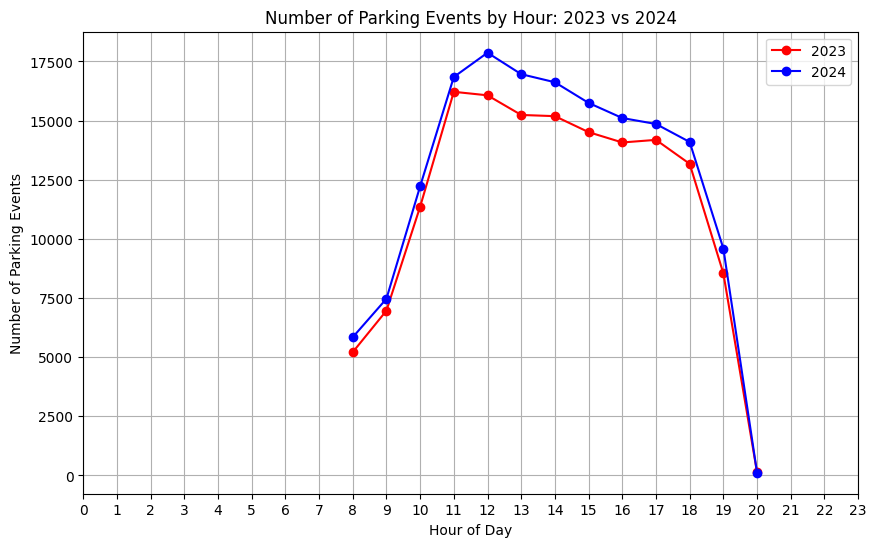

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Make sure the 'Starting date' columns are datetime
clean_df_2023['Starting date'] = pd.to_datetime(clean_df_2023['Starting date'])
clean_df_2024['Starting date'] = pd.to_datetime(clean_df_2024['Starting date'])

# Extract hour for both years
clean_df_2023['Hour'] = clean_df_2023['Starting date'].dt.hour
clean_df_2024['Hour'] = clean_df_2024['Starting date'].dt.hour

# Group by hour and count parking events
hourly_counts_2023 = clean_df_2023.groupby('Hour').size()
hourly_counts_2024 = clean_df_2024.groupby('Hour').size()

# Plot both years on same graph
plt.figure(figsize=(10,6))
plt.plot(hourly_counts_2023.index, hourly_counts_2023.values, marker='o', label='2023', color='red')
plt.plot(hourly_counts_2024.index, hourly_counts_2024.values, marker='o', label='2024', color='blue')
plt.title('Number of Parking Events by Hour: 2023 vs 2024')
plt.xlabel('Hour of Day')
plt.ylabel('Number of Parking Events')
plt.xticks(range(0,24))
plt.legend()
plt.grid(True)
plt.show()


Compares two parking fee types in 2023: Regular Rate vs Residents Rate

 Regular Rate had nearly 130,000 transactions — much higher usage

 Residents Rate had nearly 20,000 transactions — far less frequent

 Insight: Most users paid the regular fee, suggesting limited uptake or access to the residents rate
 for 2024
 Regular Rate had nearly 145,000 transactions — dominant usage

 Residents Rate had nearly 20,000 transactions — much lower

 Insight: Regular Rate continues to be the overwhelmingly preferred option, similar to 2023

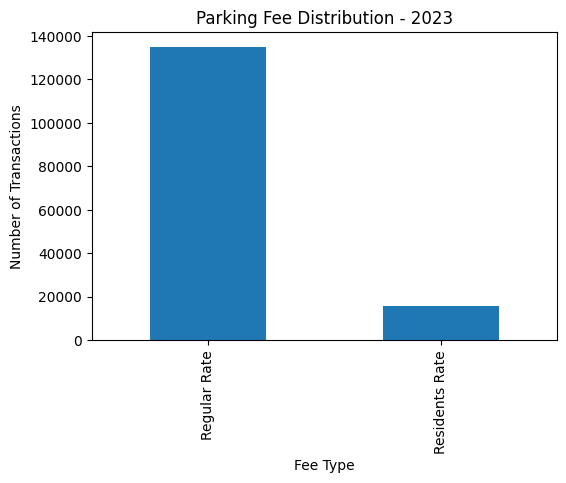

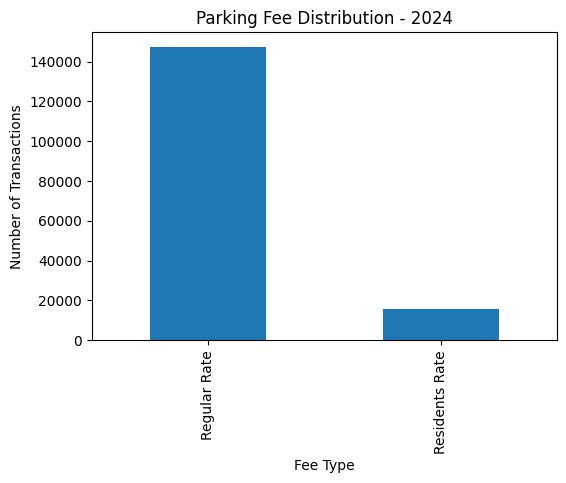

In [ ]:
clean_df_2023['Fee'].value_counts().plot(kind='bar', figsize=(6,4), title='Parking Fee Distribution - 2023')
plt.xlabel('Fee Type')
plt.ylabel('Number of Transactions')
plt.show()
clean_df_2024['Fee'].value_counts().plot(kind='bar', figsize=(6,4), title='Parking Fee Distribution - 2024')
plt.xlabel('Fee Type')
plt.ylabel('Number of Transactions')
plt.show()


Most cars parked for 60–120 minutes — peak duration

After 120 minutes, the number of parked cars drops sharply
 2024 had slightly more cars parked in each duration band than 2023

 Insight: Short-to-mid duration parking dominates, with long stays being rare

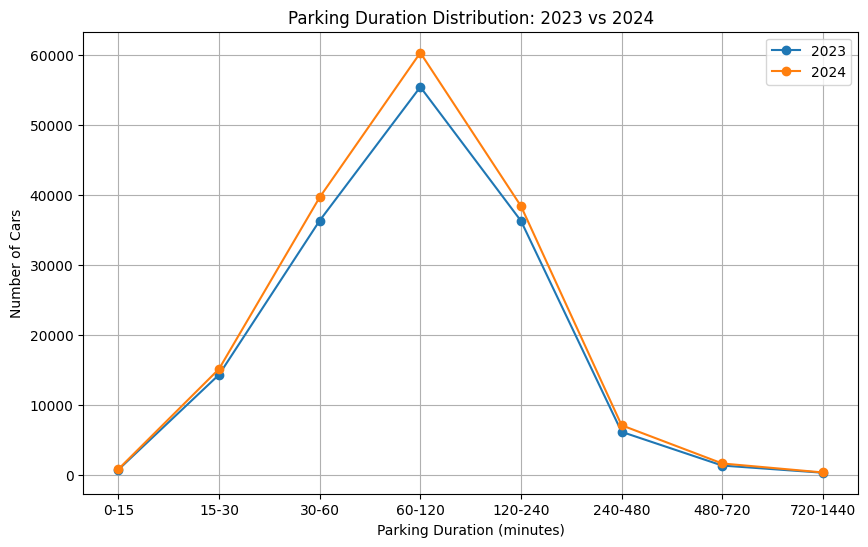

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Define bins for parking duration (in minutes)
bins = [0, 15, 30, 60, 120, 240, 480, 720, 1440]  # 0–15, 15–30, 30–60, etc.
labels = ['0-15', '15-30', '30-60', '60-120', '120-240', '240-480', '480-720', '720-1440']

# Create a new column 'Duration_bin' for 2023 and 2024
clean_df_2023['Duration_bin'] = pd.cut(clean_df_2023['Parking Duration (min)'], bins=bins, labels=labels, right=False)
clean_df_2024['Duration_bin'] = pd.cut(clean_df_2024['Parking Duration (min)'], bins=bins, labels=labels, right=False)

# Count how many cars in each bin
duration_count_2023 = clean_df_2023['Duration_bin'].value_counts().sort_index()
duration_count_2024 = clean_df_2024['Duration_bin'].value_counts().sort_index()

# Plotting line graphs
plt.figure(figsize=(10,6))
plt.plot(duration_count_2023.index, duration_count_2023.values, marker='o', label='2023')
plt.plot(duration_count_2024.index, duration_count_2024.values, marker='o', label='2024')
plt.title('Parking Duration Distribution: 2023 vs 2024')
plt.xlabel('Parking Duration (minutes)')
plt.ylabel('Number of Cars')
plt.grid(True)
plt.legend()
plt.show()


Regular Rate users parked for to 120 minutes on average

Residents Rate users parked for to 80 minutes on average
Insight: Regular Rate users tend to stay longer than residents
In 2024 Regular Rate: to 125 minutes average duration
Residents Rate: to 60 minutes average duration
 Insight: Regular Rate users stayed twice as long as Residents Rate users

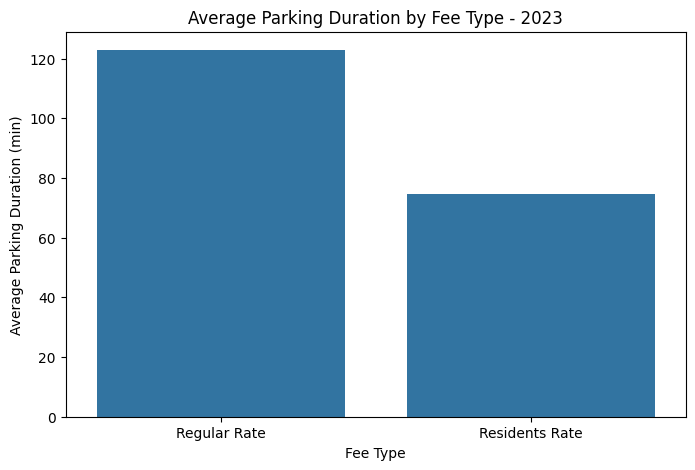

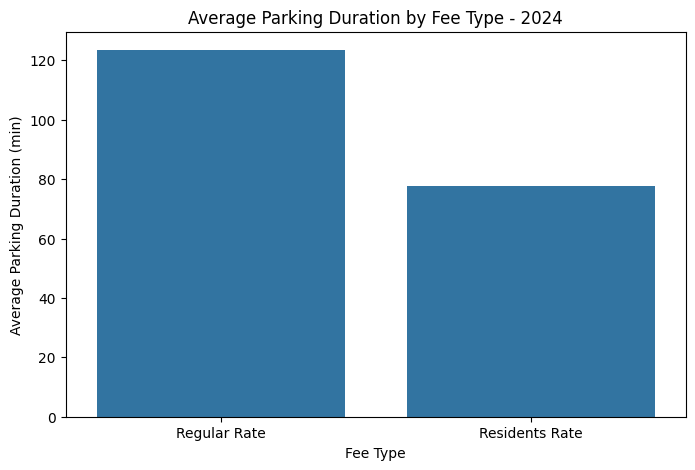

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
avg_duration = clean_df_2023.groupby('Fee')['Parking Duration (min)'].mean().reset_index()

plt.figure(figsize=(8,5))
sns.barplot(x='Fee', y='Parking Duration (min)', data=avg_duration)
plt.title('Average Parking Duration by Fee Type - 2023')
plt.xlabel('Fee Type')
plt.ylabel('Average Parking Duration (min)')
plt.show()

avg_duration = clean_df_2024.groupby('Fee')['Parking Duration (min)'].mean().reset_index()

plt.figure(figsize=(8,5))
sns.barplot(x='Fee', y='Parking Duration (min)', data=avg_duration)
plt.title('Average Parking Duration by Fee Type - 2024')
plt.xlabel('Fee Type')
plt.ylabel('Average Parking Duration (min)')
plt.show()



Regular Rate vehicles dominate every hour, peaking between 11 AM -3 PM with over 14,000 vehicles

Residents Rate vehicles stay low and steady, around 1,000 - 2,000 all day

Insight: Regular Rate usage far exceeds Residents Rate, especially during midday peak hours

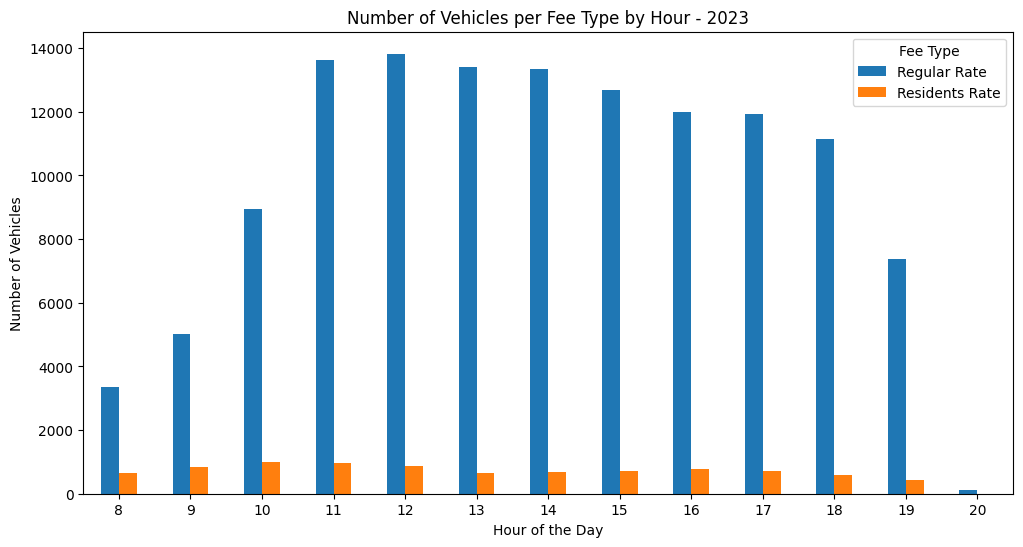

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Make a copy of your dataset
df_2023 = clean_df_2023.copy()

# Extract hour from the starting date
df_2023['Hour'] = df_2023['Starting date'].dt.hour

# Group by Hour and Fee, count number of vehicles (unique plates)
hourly_fee_counts = df_2023.groupby(['Hour', 'Fee'])['Plate'].nunique().unstack()

# Plot
hourly_fee_counts.plot(kind='bar', figsize=(12,6))
plt.title('Number of Vehicles per Fee Type by Hour - 2023')
plt.xlabel('Hour of the Day')
plt.ylabel('Number of Vehicles')
plt.xticks(rotation=0)
plt.legend(title='Fee Type')
plt.show()


Bank card: Highest variability and median nearly 100 minutes

Pay by phone: Slightly lower median, but some long-duration outliers
Cash: Lowest median (50 minutes) and least variability
Insight: Digital payments are linked to longer parking durations than cash

In 2024
Cash: Shortest median duration (50 min), with wide variability and many outliers

Bank card: Median 100 min, broad range of durations

Pay by phone: Slightly above 100 min median, tight range, one long-duration outlier
 Insight: Digital payments (card/phone) are linked to longer parking stays than cash

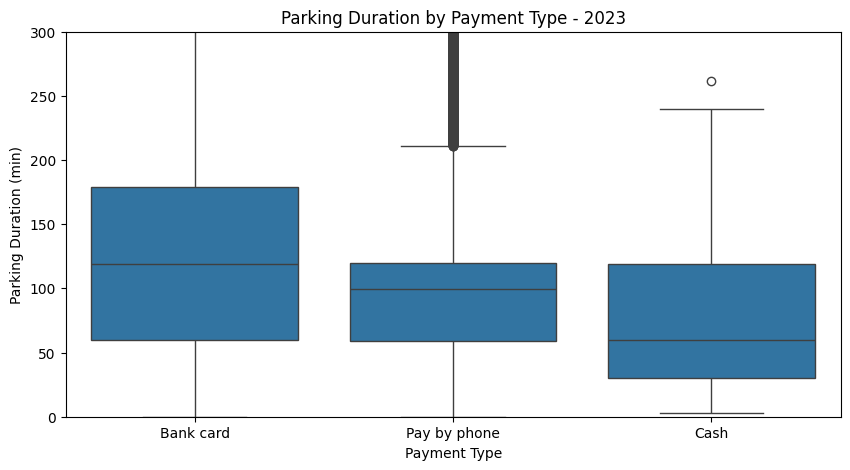

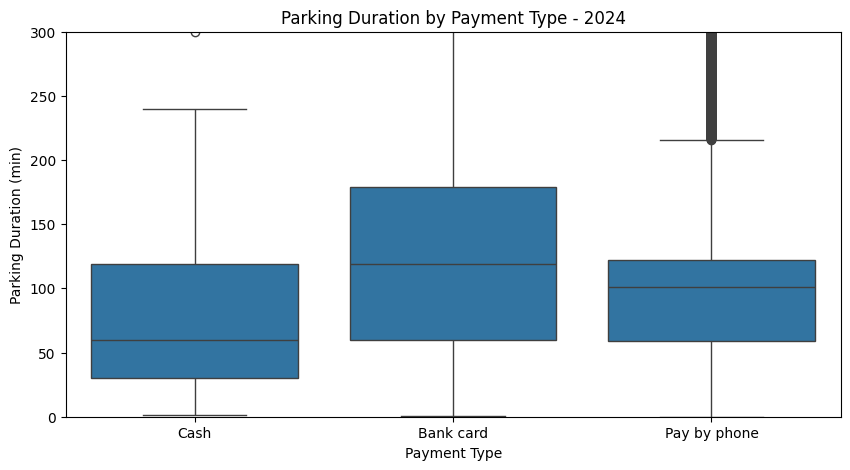

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
sns.boxplot(x='Payment type', y='Parking Duration (min)', data=clean_df_2023)
plt.ylim(0, 300)  # Limit y-axis for clearer view
plt.title('Parking Duration by Payment Type - 2023')
plt.ylabel('Parking Duration (min)')
plt.xlabel('Payment Type')
plt.show()

plt.figure(figsize=(10,5))
sns.boxplot(x='Payment type', y='Parking Duration (min)', data=clean_df_2024)
plt.ylim(0, 300)  # Limit y-axis for clearer view
plt.title('Parking Duration by Payment Type - 2024')
plt.ylabel('Parking Duration (min)')
plt.xlabel('Payment Type')
plt.show()

In [ ]:
# Add a column to identify the year
clean_df_2023['Year'] = 2023
clean_df_2024['Year'] = 2024

# Combine both datasets
combined_df = pd.concat([clean_df_2023, clean_df_2024], ignore_index=True)

# Verify the result
print(combined_df.info())
print(combined_df.head())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 314169 entries, 0 to 314168
Data columns (total 12 columns):
 #   Column                  Non-Null Count   Dtype         
---  ------                  --------------   -----         
 0   Fee                     314169 non-null  object        
 1   Date                    314169 non-null  datetime64[ns]
 2   Starting date           314169 non-null  datetime64[ns]
 3   End date                314169 non-null  datetime64[ns]
 4   Payment type            314169 non-null  object        
 5   Amount                  314169 non-null  float64       
 6   Plate                   314169 non-null  object        
 7   Parking Duration (min)  314169 non-null  float64       
 8   Zero_Duration_Flag      314169 non-null  object        
 9   Hour                    314169 non-null  int32         
 10  Duration_bin            314169 non-null  category      
 11  Year                    314169 non-null  int64         
dtypes: category(1), datetime64[ns]

In [ ]:
combined_df.to_excel('combined_parking_data2023_24.xlsx', index=False)


# Dataset Review: PARKING
Coded by: VIctoriia

# Block 1: Loading and Overview of the Dataset

In [ ]:
from google.colab import files
import pandas as pd
import glob
import matplotlib.pyplot as plt
import seaborn as sns
import re

In [ ]:
df_1 = pd.read_csv('basic_management_pichistoryParkings_13fmr04d650btvc1h9w93z41wq.csv')

In [ ]:
df_2= pd.read_csv('basic_management_pichistoryParkings_2c1ms0737k4vptft484ry6jrqh.csv')

In [ ]:
df_3= pd.read_csv('basic_management_pichistoryParkings_2qrmr06zmyc3jsm2yzjzwvm2zm.csv')

In [ ]:
df_4 = pd.read_csv('basic_management_pichistoryParkings_yd6cr079xmp3hrs1c52s4kcjrz.csv')

In [ ]:

#  Find all CSV files in your working folder
all_files = glob.glob("*.csv")

#  Read and merge them
dfs = []
for f in all_files:
    df = pd.read_csv(f)
    df["source_file"] = f   # add the filename as a new column (optional but useful)
    dfs.append(df)

merged_df = pd.concat(dfs, ignore_index=True)

#  Save the merged data
merged_df.to_csv("merged.csv", index=False)

from google.colab import files
files.download("merged.csv")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
df_1.shape

(19716, 147)

In [ ]:
df_2.shape

(19345, 147)

In [ ]:
df_3.shape

(19002, 147)

In [ ]:
df_4.shape

(19543, 147)

In [ ]:
merged_df.shape

(77606, 148)

In [ ]:
merged_df= pd.read_csv('merged.csv')

In [ ]:
merged_df.head() #Display the first 5 rows

,ID,Installation,Type,Source type,Unit,Zone,Fee,Plate,Collection GUID,Date,...,Hope Listener Received Utc Date,Hope Listener Insertion Utc Date,Hope Brt Id,Hope Tariff Cur Id,Hope Tariff Amount,Hope Tariff Amount Change,Hope Ext Data,Hope Vehicle Type,Hope Vht Id,source_file
0,153654800,Banff,Parking,External,NaN,Downtown,Regular Rate,0EV050,NaN,2025-08-17 19:59,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,basic_management_pichistoryParkings_13fmr04d65...
1,153654791,Banff,Parking,Internal,BANFF15- CLOCK TOWER LOT,Downtown,Regular Rate,CPZ2037,5058fd818dbfc0e28091660dba1574738cd509a9febe6e6c,2025-08-17 19:53,...,2025-08-18 1:56,2025-08-18 1:56,NaN,NaN,NaN,NaN,NaN,NaN,NaN,basic_management_pichistoryParkings_13fmr04d65...
2,153654789,Banff,Extension,Internal,BANFF05- CLOCK TOWER LOT WEST,Downtown,Residents Rate,BSK6477,255c4f59fd1da869f1658cdfcae3cf171c5b3eb854f64221,2025-08-17 19:54,...,2025-08-18 1:54,2025-08-18 1:54,NaN,NaN,NaN,NaN,NaN,NaN,NaN,basic_management_pichistoryParkings_13fmr04d65...
3,153654785,Banff,Parking,Internal,BANFF18- TOWN HALL LOT,Downtown,Regular Rate,0CN343,25e4a70085dc0bb3811275faef39f28785ee2935cddfc393,2025-08-17 19:53,...,2025-08-18 1:54,2025-08-18 1:54,NaN,NaN,NaN,NaN,NaN,NaN,NaN,basic_management_pichistoryParkings_13fmr04d65...
4,153654783,Banff,Extension,Internal,BANFF04- MARTEN 300 BLOCK,Downtown,Regular Rate,PL803P,34e51775d45d64864e7d842e1bb2efd0c334721a89a1cd51,2025-08-17 19:51,...,2025-08-18 1:53,2025-08-18 1:53,NaN,NaN,NaN,NaN,NaN,NaN,NaN,basic_management_pichistoryParkings_13fmr04d65...


In [ ]:
merged_df.info() #Get dataset summary


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 77606 entries, 0 to 77605
Columns: 148 entries, ID to source_file
dtypes: float64(87), int64(19), object(42)
memory usage: 87.6+ MB


In [ ]:
merged_df.isnull().sum() #Check for missing values


,0
ID,0
Installation,0
Type,0
Source type,0
Unit,32668
...,...
Hope Tariff Amount Change,77606
Hope Ext Data,77606
Hope Vehicle Type,77606
Hope Vht Id,77606


# Block 2: Data Cleaning and Preparation (%20)

In [ ]:
# Percentage of missing values in each column
missing_percent = (merged_df.isnull().mean() * 100).round(2)

# Display it nicely
print(missing_percent)


ID                             0.00
Installation                   0.00
Type                           0.00
Source type                    0.00
Unit                          42.09
                              ...  
Hope Tariff Amount Change    100.00
Hope Ext Data                100.00
Hope Vehicle Type            100.00
Hope Vht Id                  100.00
source_file                    0.00
Length: 148, dtype: float64


In [ ]:
#  Find columns that are completely empty (100% missing)
cols_all_missing = merged_df.columns[merged_df.isnull().mean() == 1.0]

#  Print their names
print("Columns with 100% missing values:")
print(cols_all_missing.tolist())

# Drop those columns
merged_df = merged_df.drop(columns=cols_all_missing)


Columns with 100% missing values:
['Payment type (1)', 'PT2 amount', 'PT2 change applied', 'PT2 changed value', 'Card ID', 'Amount refunded', 'Amount refunded with bonification', 'External unit', 'Comments', 'Card expiration', 'Transaction retries', 'Card Track 2', 'Movement of Balance status', 'Movement of Balance', 'Cards', 'Wallet Balance', 'Previous Wallet Balance', 'Parking space', 'Parking space 2', 'Parking space 3', 'Parking space 4', 'Parking space 5', 'Parking space 6', 'Parking space 7', 'Parking space 8', 'Parking space 9', 'Parking space 10', 'Description parking space 1', 'Description parking space 2', 'Description parking space 3', 'Description parking space 4', 'Description parking space 5', 'Description parking space 6', 'Description parking space 7', 'Description parking space 8', 'Description parking space 9', 'Description parking space 10', 'Plate 2', 'Plate 3', 'Plate 4', 'Plate 5', 'Plate 6', 'Plate 7', 'Plate 8', 'Plate 9', 'Plate 10', 'AmountDebt', 'Hope Balance

In [ ]:
#check unique values for external provider
merged_df['External provider'].unique()

array(['BLINKAY.APP', nan], dtype=object)

In [ ]:
#  Drop all columns that start with "Hope" EXCEPT a few useful ones
cols_to_keep = [
    'Hope Gps Latitude',
    'Hope Gps Longitude',
    'Hope Tariff Amount',
    'Hope Tariff Amount Change',
    'Hope Vehicle Type',
    'Hope Insertion Date'
]

# Identify all columns starting with 'Hope'
hope_cols = [col for col in merged_df.columns if col.startswith('Hope')]

# Keep only the important ones
cols_to_drop = [col for col in hope_cols if col not in cols_to_keep]

# Drop them
merged_df.drop(columns=cols_to_drop, inplace=True, errors='ignore')

print(f"Dropped {len(cols_to_drop)}  columns.")



Dropped 32  columns.


In [ ]:
#Drop unusfull  columns
merged_df.drop(
    columns=[
        'Email',
        'External provider',
        'Transaction ID',
        'Transaction ID.1',
        'Card #',
        'Transaction status',
        'Card Track 1',
        'source_file'
    ],
    inplace=True
)


In [ ]:
merged_df.head()

,ID,Installation,Type,Source type,Unit,Zone,Fee,Plate,Collection GUID,Date,...,UTC Date,Starting date (UTC),End date (UTC),Status date (UTC),Ticket Number,Coupon Amount,Number of Coupons,Hope Insertion Date,Hope Gps Latitude,Hope Gps Longitude
0,153654800,Banff,Parking,External,NaN,Downtown,Regular Rate,0EV050,NaN,2025-08-17 19:59,...,2025-08-18 1:59,2025-08-18 1:59,2025-08-18 2:00,2025-08-18 1:59,NaN,NaN,NaN,2025-08-17 19:59,51.17718,-115.57108
1,153654791,Banff,Parking,Internal,BANFF15- CLOCK TOWER LOT,Downtown,Regular Rate,CPZ2037,5058fd818dbfc0e28091660dba1574738cd509a9febe6e6c,2025-08-17 19:53,...,2025-08-18 1:53,2025-08-18 1:53,2025-08-18 2:00,2025-08-18 1:55,102312.0,$-,0.0,2025-08-17 19:54,51.17476,-115.56962
2,153654789,Banff,Extension,Internal,BANFF05- CLOCK TOWER LOT WEST,Downtown,Residents Rate,BSK6477,255c4f59fd1da869f1658cdfcae3cf171c5b3eb854f64221,2025-08-17 19:54,...,2025-08-18 1:54,2025-08-18 1:54,2025-08-18 2:00,2025-08-18 1:54,5518.0,$-,0.0,2025-08-17 19:54,51.17476,-115.56979
3,153654785,Banff,Parking,Internal,BANFF18- TOWN HALL LOT,Downtown,Regular Rate,0CN343,25e4a70085dc0bb3811275faef39f28785ee2935cddfc393,2025-08-17 19:53,...,2025-08-18 1:53,2025-08-18 1:53,2025-08-18 2:00,2025-08-18 1:53,86840.0,$-,0.0,2025-08-17 19:53,51.17532,-115.57248
4,153654783,Banff,Extension,Internal,BANFF04- MARTEN 300 BLOCK,Downtown,Regular Rate,PL803P,34e51775d45d64864e7d842e1bb2efd0c334721a89a1cd51,2025-08-17 19:51,...,2025-08-18 1:51,2025-08-18 2:00,2025-08-18 15:00,2025-08-18 1:53,15948.0,$-,0.0,2025-08-17 19:53,51.18085,-115.57057


In [ ]:
# Percentage of missing values in each column
missing_percent = (merged_df.isnull().mean() * 100).round(2)

# Sort in descending order
missing_percent = missing_percent.sort_values(ascending=False)

# Display nicely
print(missing_percent)


Bonification                57.91
Amount with bonification    57.91
Coupon Amount               42.09
Ticket Number               42.09
Collection GUID             42.09
Unit                        42.09
Number of Coupons           42.09
Hope Gps Latitude           30.45
Hope Gps Longitude          30.45
ID                           0.00
Installation                 0.00
Starting date                0.00
Date                         0.00
Source type                  0.00
Zone                         0.00
Fee                          0.00
Plate                        0.00
Type                         0.00
Amount                       0.00
PT1 changed value            0.00
PT1 change applied           0.00
PT1 amount                   0.00
End date                     0.00
Payment type                 0.00
Time                         0.00
Online                       0.00
Starting date (UTC)          0.00
UTC Date                     0.00
Refunded ID                  0.00
Insertion date

In [ ]:
merged_df['Zone'].nunique()


1

In [ ]:
unique_longitudes = merged_df['Hope Gps Longitude'].round(2).unique()
print(unique_longitudes)


[-115.57     nan    0.   -115.58]


In [ ]:
# 2️⃣ — Truncate longitude to first 2 digits after decimal (no rounding)
merged_df['Truncated_Longitude'] = np.trunc(merged_df['Hope Gps Longitude'] * 100) / 100

# 3️⃣ — Show unique truncated longitudes
unique_longitudes = merged_df['Truncated_Longitude'].unique()
print("🧭 Unique truncated longitude values:")
print(unique_longitudes)
print(f"\nTotal unique truncated longitudes: {len(unique_longitudes)}\n")

# 4️⃣ — Frequency count for each truncated longitude
print("📊 Frequency of truncated longitudes:")
print(merged_df['Truncated_Longitude'].value_counts().sort_index())

🧭 Unique truncated longitude values:
[-115.57 -115.56     nan    0.  ]

Total unique truncated longitudes: 4

📊 Frequency of truncated longitudes:
Truncated_Longitude
-115.57    36264
-115.56    16704
 0.00       1008
Name: count, dtype: int64


In [ ]:
#Show the percentage of missing longitude, latitude values.

#Truncate longitude to 2 digits after the decimal (without rounding) and 4 for lattitude.

#Display all unique truncated  values and their counts.
#  Truncate longitude to 2 digits after decimal (no rounding)
merged_df['Truncated_Longitude'] = np.trunc(merged_df['Hope Gps Longitude'] * 100) / 100

#  Truncate latitude to 4 digits after decimal (no rounding)
merged_df['Truncated_Latitude'] = np.trunc(merged_df['Hope Gps Latitude'] * 10000) / 10000

#  Show unique truncated longitudes
unique_longitudes = merged_df['Truncated_Longitude'].unique()
print(" Unique truncated longitude values:")
print(unique_longitudes)
print(f"\nTotal unique truncated longitudes: {len(unique_longitudes)}\n")

#  Show unique truncated latitudes
unique_latitudes = merged_df['Truncated_Latitude'].unique()
print("Unique truncated latitude values:")
print(unique_latitudes)
print(f"\nTotal unique truncated latitudes: {len(unique_latitudes)}\n")

#   Frequency count for each truncated longitude
print(" Frequency of truncated longitudes:")
print(merged_df['Truncated_Longitude'].value_counts().sort_index())

#  Frequency count for each truncated latitude
print("\n Frequency of truncated latitudes:")
print(merged_df['Truncated_Latitude'].value_counts().sort_index())


🧭 Unique truncated longitude values:
[-115.57 -115.56     nan    0.  ]

Total unique truncated longitudes: 4

🌍 Unique truncated latitude values:
[51.1771 51.1747 51.1753 51.1808 51.1762 51.1744 51.1772 51.1741     nan
 51.1783 51.1763 51.1754 51.1766 51.1765 51.1767 51.1746 51.1774 51.1768
 51.1776 51.176   0.     51.1785 51.1773 51.1795 51.1796 51.1761 51.1756
 51.1784 51.1791 51.1775 51.1759 51.1755 51.1745 51.1812 51.1764 51.1742
 51.177  51.175  51.179  51.1777 51.1803 51.1793 51.1743 51.1769 51.1757
 51.1752 51.1786 51.1787 51.1739 51.1781 51.1758 51.178  51.1779 51.1782
 51.1811 51.1748 51.1788 51.1801 51.1751 51.1737 51.1792 51.1807 51.1797
 51.1802 51.1778 51.1799 51.1749 51.174  51.1794 51.1733 51.181  51.1789
 51.1734 51.1805 51.1738 51.1798 51.1806 51.1809 51.1731 51.1813 51.1814
 51.1804 51.1736 51.18   51.1732]

Total unique truncated latitudes: 85

📊 Frequency of truncated longitudes:
Truncated_Longitude
-115.57    36264
-115.56    16704
 0.00       1008
Name: count, dty

In [ ]:
#Impute missing longitude/latitude from Unit only, using truncated precision (no rounding)

# --- 0) Make sure columns exist (optional guard rails) ---
required_cols = ['Unit', 'Hope Gps Longitude', 'Hope Gps Latitude']
missing_cols = [c for c in required_cols if c not in merged_df.columns]
if missing_cols:
    raise KeyError(f"Missing required columns: {missing_cols}")

# --- 1) Clean & coerce: treat 0 as missing; coerce non-numerics to NaN ---
merged_df['Hope Gps Longitude'] = pd.to_numeric(merged_df['Hope Gps Longitude'], errors='coerce')
merged_df['Hope Gps Latitude']  = pd.to_numeric(merged_df['Hope Gps Latitude'], errors='coerce')

merged_df['Hope Gps Longitude'] = merged_df['Hope Gps Longitude'].replace(0, np.nan)
merged_df['Hope Gps Latitude']  = merged_df['Hope Gps Latitude'].replace(0, np.nan)

# --- 2) Build truncated (no rounding) versions for reference ---
merged_df['Trunc_Lon'] = np.trunc(merged_df['Hope Gps Longitude'] * 100) / 100      # 2 dp for longitude
merged_df['Trunc_Lat'] = np.trunc(merged_df['Hope Gps Latitude']  * 10000) / 10000  # 4 dp for latitude

# --- 3) Create per-Unit reference (most common truncated values per Unit) ---
# If multiple truncated values exist for a Unit, we take the mode; ties → first mode.
def mode_or_nan(s: pd.Series):
    s = s.dropna()
    return s.mode().iloc[0] if not s.empty else np.nan

unit_ref = (
    merged_df
      .dropna(subset=['Unit'])  # need a Unit to be a reference
      .groupby('Unit', as_index=False)
      .agg(Ref_Trunc_Lon=('Trunc_Lon', mode_or_nan),
           Ref_Trunc_Lat=('Trunc_Lat', mode_or_nan))
)

# --- 4) Merge reference back and impute missing lon/lat from Unit reference ---
merged_df = merged_df.merge(unit_ref, on='Unit', how='left')

# Fill missing original coordinates with the truncated references
lon_missing_mask = merged_df['Hope Gps Longitude'].isna()
lat_missing_mask = merged_df['Hope Gps Latitude'].isna()

merged_df.loc[lon_missing_mask, 'Hope Gps Longitude'] = merged_df.loc[lon_missing_mask, 'Ref_Trunc_Lon']
merged_df.loc[lat_missing_mask, 'Hope Gps Latitude']  = merged_df.loc[lat_missing_mask, 'Ref_Trunc_Lat']

# --- 5) Recompute truncated columns AFTER imputation (to reflect fills) ---
merged_df['Trunc_Lon'] = np.trunc(merged_df['Hope Gps Longitude'] * 100) / 100
merged_df['Trunc_Lat'] = np.trunc(merged_df['Hope Gps Latitude']  * 10000) / 10000

# --- 6) (Optional) Clean up helper reference columns ---
merged_df.drop(columns=['Ref_Trunc_Lon', 'Ref_Trunc_Lat'], inplace=True)

# --- 7) Quick report ---
report = (merged_df[['Hope Gps Longitude','Hope Gps Latitude']]
          .isna().mean().mul(100).round(2))
print("Remaining missing values (%):\n", report)


Remaining missing values (%):
 Hope Gps Longitude    31.75
Hope Gps Latitude     31.75
dtype: float64


In [ ]:
#impute missing Unit values by matching on truncated GPS

# Ensure numeric and treat zeros ("0" or "0.") as missing
for col in ['Hope Gps Longitude', 'Hope Gps Latitude']:
    # Convert text like "0." to numeric and replace 0 with NaN
    merged_df[col] = pd.to_numeric(merged_df[col], errors='coerce')
    merged_df.loc[merged_df[col] == 0, col] = np.nan

# Create truncated coordinate columns (no rounding)
# Longitude: 2 digits after decimal; Latitude: 4 digits after decimal
merged_df['TLon'] = np.trunc(merged_df['Hope Gps Longitude'] * 100) / 100
merged_df['TLat'] = np.trunc(merged_df['Hope Gps Latitude'] * 10000) / 10000

#  Build a lookup table from known Units (GPS → Unit)
# If multiple Units share the same truncated coordinates, pick the most frequent one.
def mode_or_nan(s: pd.Series):
    m = s.mode()
    return m.iloc[0] if not m.empty else np.nan

coord_to_unit = (
    merged_df.dropna(subset=['Unit', 'TLon', 'TLat'])
             .groupby(['TLon', 'TLat'])['Unit']
             .apply(mode_or_nan)
             .reset_index()
)

# Make a MultiIndex lookup for fast access
coord_to_unit_indexed = coord_to_unit.set_index(['TLon', 'TLat'])['Unit']

# Impute missing Units based on truncated longitude & latitude
mask_unit_missing = merged_df['Unit'].isna()

merged_df.loc[mask_unit_missing, 'Unit'] = merged_df.loc[mask_unit_missing, ['TLon', 'TLat']].apply(
    lambda r: coord_to_unit_indexed.get((r['TLon'], r['TLat']), np.nan), axis=1
)

# Report results
filled = mask_unit_missing.sum() - merged_df['Unit'].isna().sum()
print(f"Imputed Unit for {filled} rows.")
print("Remaining missing Units (%):", (merged_df['Unit'].isna().mean() * 100).round(2))


Imputed Unit for 2126 rows.
Remaining missing Units (%): 39.36


In [ ]:
# Replace Missing or 0-like Unit, Lattitude and Longtitude Values with "Unknown"

# ---  Clean the Unit column ---
# Replace known "empty" indicators (0, 0., '', nan, None, etc.) with NaN
merged_df['Unit'] = merged_df['Unit'].replace(
    to_replace=['', '0', '0.', 'nan', 'None', 'NaN'], value=np.nan
)

# Fill all missing Units with the string 'Unknown'
merged_df['Unit'] = merged_df['Unit'].fillna('Unknown')

# ---  Clean GPS columns (Longitude and Latitude) ---
# Convert to numeric safely (handles strings like '0.' or 'nan')
for col in ['Hope Gps Longitude', 'Hope Gps Latitude']:
    merged_df[col] = pd.to_numeric(merged_df[col], errors='coerce')
    # Treat 0 as missing
    merged_df.loc[merged_df[col] == 0, col] = np.nan

# ---   Check summary after cleaning ---
print(" Data cleaning complete!")

print("\nMissing value percentages after cleaning:")
print((merged_df[['Unit', 'Hope Gps Longitude', 'Hope Gps Latitude']].isna().mean() * 100).round(2))

print("\nUnit value counts:")
print(merged_df['Unit'].value_counts().head())

 Data cleaning complete!

Missing value percentages after cleaning:
Unit                   0.00
Hope Gps Longitude    31.75
Hope Gps Latitude     31.75
dtype: float64

Unit value counts:
Unit
Unknown                            30542
BANFF26- FIRE HALL LOT WEST         4225
BANFF17- CENTRAL PARK LOT           4016
BANFF15- CLOCK TOWER LOT            3750
BANFF08- FIRE HALL LOT 1 "WEST"     3639
Name: count, dtype: int64


In [ ]:
merged_df.duplicated().sum() #Count how many duplicates there are


np.int64(0)

In [ ]:
# Drop unnecessary columns safely (skip if they don't exist)
merged_df.drop(
    columns=[
        'Email',
        'External provider',
        'Transaction ID',
        'Transaction ID.1',
        'Card #',
        'Transaction status',
        'Card Track 1',
        'Trunc_Lon',
        'Trunc_Lat',
        'Truncated_Longitude',
        'Truncated_Latitude',
        'TLon',
        'TLat',
        'source_file'
    ],
    inplace=True,
    errors='ignore'  # 👈 prevents KeyError if some columns are missing
)


In [ ]:
merged_df.info() #Check column data types


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 77606 entries, 0 to 77605
Data columns (total 34 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   ID                        77606 non-null  int64  
 1   Installation              77606 non-null  object 
 2   Type                      77606 non-null  object 
 3   Source type               77606 non-null  object 
 4   Unit                      77606 non-null  object 
 5   Zone                      77606 non-null  object 
 6   Fee                       77606 non-null  object 
 7   Plate                     77606 non-null  object 
 8   Collection GUID           44938 non-null  object 
 9   Date                      77606 non-null  object 
 10  Starting date             77606 non-null  object 
 11  End date                  77606 non-null  object 
 12  Payment type              77606 non-null  object 
 13  PT1 amount                77606 non-null  object 
 14  PT1 ch

In [ ]:
date_cols = [col for col in merged_df.columns if 'date' in col.lower() or 'utc' in col.lower()]
print(date_cols)  #Automatically detect likely date columns


['Date', 'Starting date', 'End date', 'Insertion date (UTC)', 'UTC Date', 'Starting date (UTC)', 'End date (UTC)', 'Status date (UTC)', 'Hope Insertion Date']


In [ ]:
#Convert them all to datetime
for col in date_cols:
    merged_df[col] = pd.to_datetime(merged_df[col], errors='coerce')


In [ ]:
#Verify the conversion
merged_df[date_cols].dtypes


,0
Date,datetime64[ns]
Starting date,datetime64[ns]
End date,datetime64[ns]
Insertion date (UTC),datetime64[ns]
UTC Date,datetime64[ns]
Starting date (UTC),datetime64[ns]
End date (UTC),datetime64[ns]
Status date (UTC),datetime64[ns]
Hope Insertion Date,datetime64[ns]


In [ ]:
# Detect columns that should be numeric
potential_numeric = ['amount', 'fee', 'value', 'number', 'balance', 'id', 'longitude', 'latitude']

num_cols = [
    col for col in merged_df.columns
    if any(key in col.lower() for key in potential_numeric)
    and "guid" not in col.lower()
]

print(num_cols)  # Inspect before converting


['ID', 'Fee', 'PT1 amount', 'PT1 changed value', 'Amount', 'Amount with bonification', 'Refunded ID', 'Ticket Number', 'Coupon Amount', 'Number of Coupons', 'Hope Gps Latitude', 'Hope Gps Longitude']


In [ ]:

# Clean up currency-like strings and convert to numbers
def to_number(series: pd.Series) -> pd.Series:
    s = series.astype(str)
    s = (
        s.str.replace(r'\$', '', regex=True)       # remove dollar signs
         .str.replace(',', '', regex=True)         # remove thousand separators
         .str.replace(r'^\s*\((.*)\)\s*$', r'-\1', regex=True)  # (123.45) → -123.45
         .str.strip()
    )
    return pd.to_numeric(s, errors='coerce')

# Look only at object (text) columns
obj_cols = merged_df.select_dtypes('object').columns

# Convert columns that are mostly numeric
converted = []
failed = []

for col in obj_cols:
    num = to_number(merged_df[col])
    non_empty = merged_df[col].astype(str).str.strip().ne('').sum()
    pct_parsed = (num.notna().sum() / max(non_empty, 1))

    if pct_parsed >= 0.80:  # column is mostly numeric
        merged_df[col] = num
        converted.append((col, round(pct_parsed * 100, 1)))
    else:
        failed.append((col, round(pct_parsed * 100, 1)))

print("Converted to numeric:", [f"{c} ({p}%)" for c, p in converted])
print(" Left as text:", [f"{c} ({p}%)" for c, p in failed])


Converted to numeric: ['PT1 amount (91.4%)', 'PT1 changed value (91.4%)', 'Amount (91.4%)']
 Left as text: ['Installation (0.0%)', 'Type (0.0%)', 'Source type (0.0%)', 'Unit (0.0%)', 'Zone (0.0%)', 'Fee (0.0%)', 'Plate (0.3%)', 'Collection GUID (0.0%)', 'Payment type (0.0%)', 'Amount with bonification (34.8%)', 'Status (0.0%)', 'Refunded ID (0.0%)', 'Coupon Amount (0.0%)']


In [ ]:
merged_df[num_cols].dtypes #Check num_cols current data types after converting

,0
ID,int64
Fee,object
PT1 amount,float64
PT1 changed value,float64
Amount,float64
Amount with bonification,object
Refunded ID,object
Ticket Number,float64
Coupon Amount,object
Number of Coupons,float64


# Block 3: Descriptive Statistics (%20)

In [ ]:
merged_df.shape

(77606, 34)

In [ ]:
merged_df.describe() #Generate summary stats for all numeric columns


,ID,Date,Starting date,End date,PT1 amount,PT1 change applied,PT1 changed value,Amount,Bonification,Online,...,Insertion date (UTC),UTC Date,Starting date (UTC),End date (UTC),Status date (UTC),Ticket Number,Number of Coupons,Hope Insertion Date,Hope Gps Latitude,Hope Gps Longitude
count,7.760600e+04,77606,77606,77606,70940.000000,77606.0,70940.000000,70945.000000,32668.0,77606.00000,...,77606,77606,77606,77606,77606,44938.000000,44938.0,77606,52968.000000,52968.000000
mean,1.536983e+08,2025-08-18 01:32:19.524778752,2025-08-18 01:35:02.378166528,2025-08-18 03:34:20.757157888,14.546958,1.0,14.546958,14.546998,1.0,0.99915,...,2025-08-18 07:33:02.934824448,2025-08-18 07:32:19.524778752,2025-08-18 07:35:02.378166528,2025-08-18 09:34:20.757157888,2025-08-18 07:32:46.860552192,72262.755152,0.0,2025-08-18 01:33:02.934824448,51.176475,-115.571628
min,1.528520e+08,2025-08-04 06:48:00,2025-08-04 08:00:00,2025-08-04 08:30:00,0.580000,1.0,0.580000,0.580000,1.0,0.00000,...,2025-08-04 12:49:00,2025-08-04 12:48:00,2025-08-04 14:00:00,2025-08-04 14:30:00,2025-08-04 12:49:00,469.000000,0.0,2025-08-04 06:49:00,51.173100,-115.576560
25%,1.532526e+08,2025-08-10 19:07:00,2025-08-10 19:08:00,2025-08-10 20:00:00,7.000000,1.0,7.000000,7.000000,1.0,1.00000,...,2025-08-11 01:08:00,2025-08-11 01:07:00,2025-08-11 01:08:00,2025-08-11 02:00:00,2025-08-11 01:07:15,10822.250000,0.0,2025-08-10 19:08:00,51.175320,-115.572660
50%,1.536536e+08,2025-08-17 17:49:00,2025-08-17 17:49:30,2025-08-17 20:00:00,14.000000,1.0,14.000000,14.000000,1.0,1.00000,...,2025-08-17 23:50:00,2025-08-17 23:49:00,2025-08-17 23:49:30,2025-08-18 02:00:00,2025-08-17 23:50:00,86817.500000,0.0,2025-08-17 17:50:00,51.176320,-115.572180
75%,1.540638e+08,2025-08-24 19:28:00,2025-08-24 19:30:00,2025-08-24 20:00:00,21.000000,1.0,21.000000,21.000000,1.0,1.00000,...,2025-08-25 01:29:45,2025-08-25 01:28:00,2025-08-25 01:30:00,2025-08-25 02:00:00,2025-08-25 01:29:00,113559.750000,0.0,2025-08-24 19:29:45,51.177200,-115.569950
max,1.544839e+08,2025-08-31 19:55:00,2025-08-31 20:00:00,2025-09-01 09:00:00,84.000000,1.0,84.000000,84.000000,1.0,1.00000,...,2025-09-01 01:56:00,2025-09-01 01:55:00,2025-09-01 02:00:00,2025-09-01 15:00:00,2025-09-01 01:57:00,170170.000000,0.0,2025-08-31 19:56:00,51.181440,-115.568710
std,4.758753e+05,NaN,NaN,NaN,10.612117,0.0,10.612117,10.612621,0.0,0.02915,...,NaN,NaN,NaN,NaN,NaN,53345.297443,0.0,NaN,0.001501,0.001479


In [ ]:
merged_df['PT1 amount'].unique()

array([ 3.5 ,   nan,  7.  ,  4.  , 10.5 , 14.  , 17.5 , 16.33, 21.  ,
        6.53, 24.5 , 28.  , 31.5 , 10.38, 35.  , 38.5 , 42.  , 45.5 ,
       49.  , 52.5 , 56.  , 63.  , 59.5 ,  4.5 , 66.5 ,  8.  , 70.  ,
       77.  , 80.5 , 84.  , 11.  ,  8.25, 73.5 , 11.25,  5.  ,  4.25,
        1.75,  3.55,  7.05, 15.75, 21.05,  8.55, 14.5 ,  0.58, 18.  ,
       15.  ,  1.4 ,  7.25,  1.05, 14.75,  7.75,  7.5 ,  3.65, 12.  ,
        2.57,  7.12, 14.05,  3.97,  3.75,  2.8 ,  7.55,  5.13,  8.75,
        5.3 , 17.75,  4.75,  1.98,  3.85, 57.05, 10.55, 28.7 , 14.15,
       18.25,  5.35,  4.3 ,  7.8 , 21.3 ,  5.25,  7.2 , 22.  , 14.1 ,
       14.25,  9.  ,  6.42])

In [ ]:
#Identify categorical columns
cat_cols = merged_df.select_dtypes(include=['object', 'category']).columns
print("Categorical columns:", cat_cols.tolist())

Categorical columns: ['Installation', 'Type', 'Source type', 'Unit', 'Zone', 'Fee', 'Plate', 'Collection GUID', 'Payment type', 'Amount with bonification', 'Status', 'Refunded ID', 'Coupon Amount']


In [ ]:
#View value counts (frequency) for each categorical column
for col in cat_cols:
    print(f"\n🔹 Column: {col}")
    print(merged_df[col].value_counts(dropna=False).head(10))  # top 10 categories



🔹 Column: Installation
Installation
Banff    77606
Name: count, dtype: int64

🔹 Column: Type
Type
Parking      71608
Extension     5998
Name: count, dtype: int64

🔹 Column: Source type
Source type
Internal    44938
External    32668
Name: count, dtype: int64

🔹 Column: Unit
Unit
Unknown                            30542
BANFF26- FIRE HALL LOT WEST         4225
BANFF17- CENTRAL PARK LOT           4016
BANFF15- CLOCK TOWER LOT            3750
BANFF08- FIRE HALL LOT 1 "WEST"     3639
BANFF28- BEAR PARKADE L2            3428
BANFF01- HEALTH UNIT LOT            3234
BANFF11- BEAR ST LOT                3005
BANFF24- CENTRAL PARK LOT SOUTH     2906
BANFF18- TOWN HALL LOT              2568
Name: count, dtype: int64

🔹 Column: Zone
Zone
Downtown    77606
Name: count, dtype: int64

🔹 Column: Fee
Fee
Regular Rate      70838
Residents Rate     6768
Name: count, dtype: int64

🔹 Column: Plate
Plate
CPK9205    49
CTX1841    44
CRC5108    36
CJK9751    29
CKY5503    27
CFK2963    27
BJP0972    24
CPV4

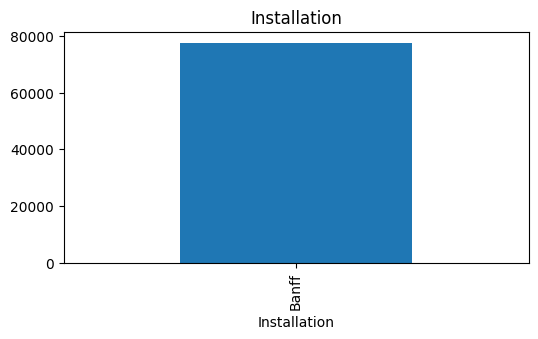

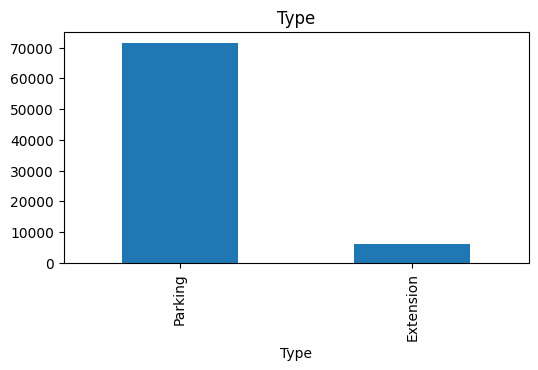

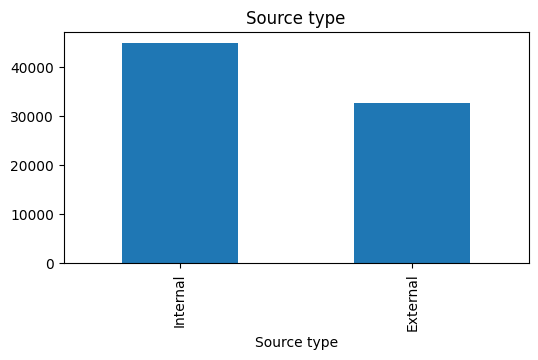

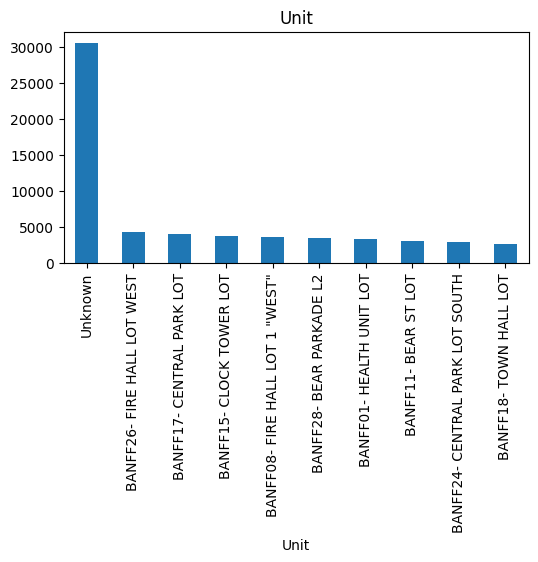

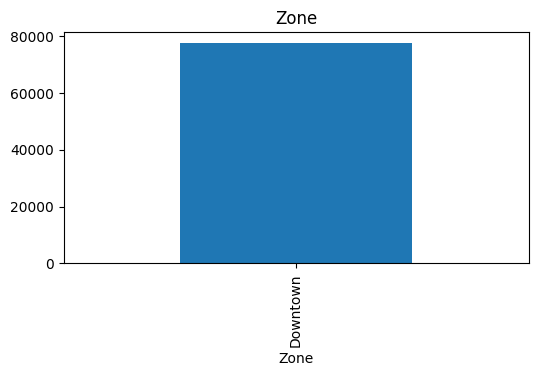

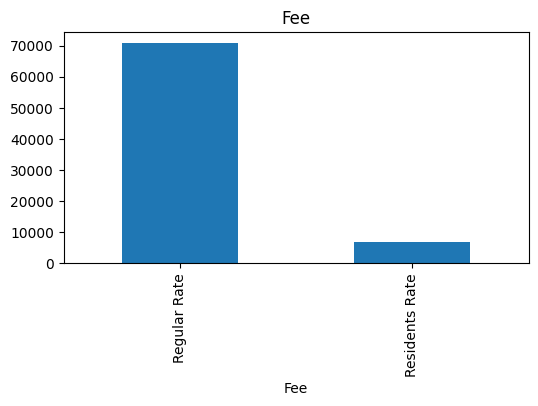

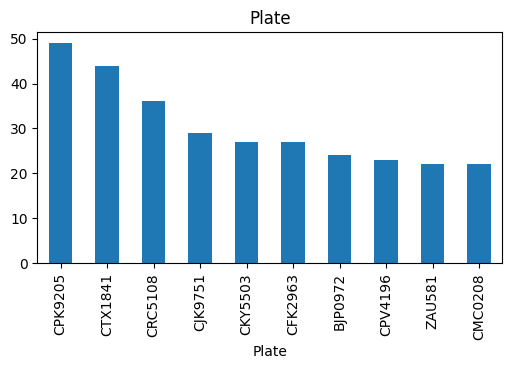

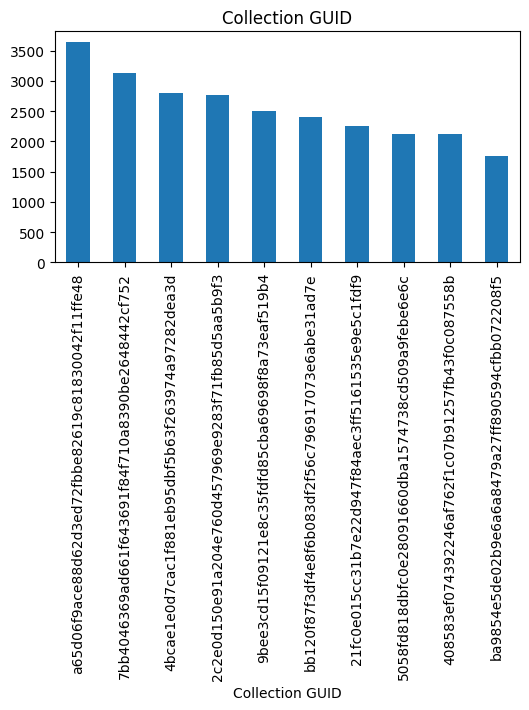

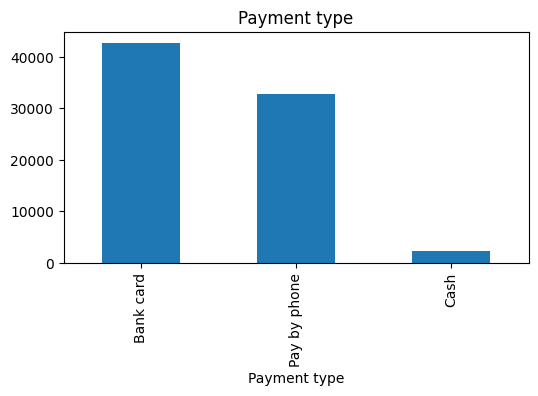

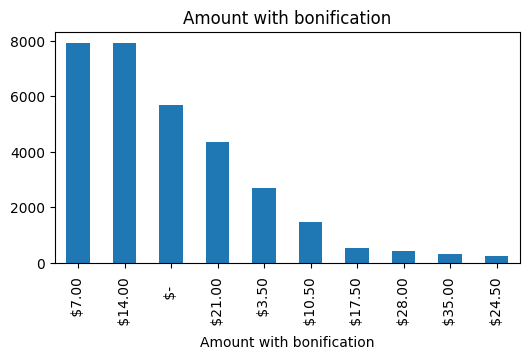

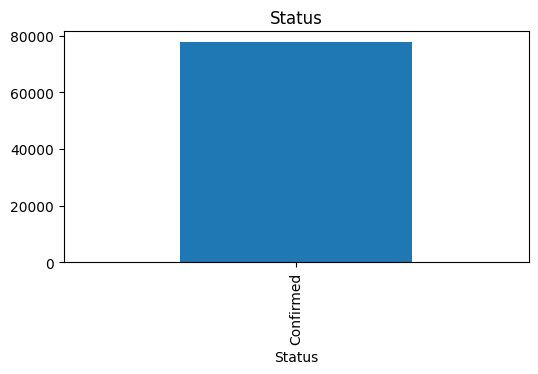

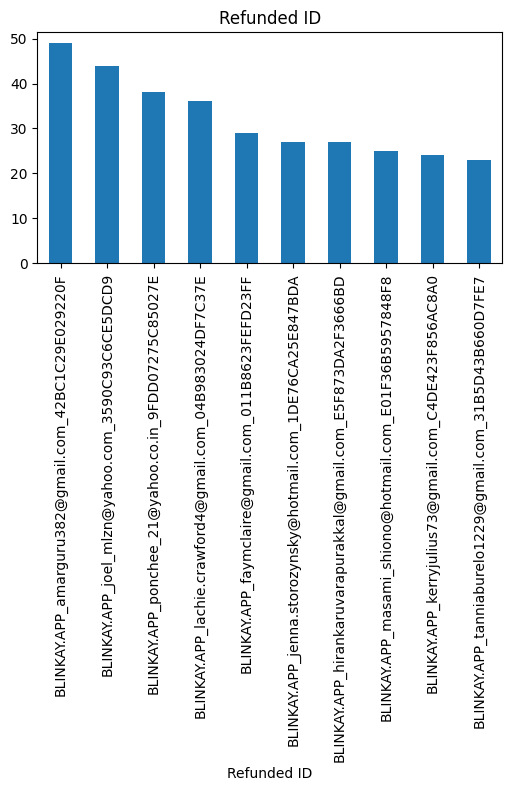

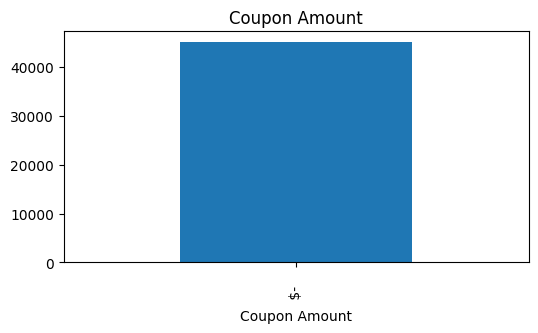

In [ ]:
import matplotlib.pyplot as plt

for col in cat_cols:
    merged_df[col].value_counts().head(10).plot(kind='bar', figsize=(6,3), title=col)
    plt.show()


In [ ]:
merged_df['Type'].nunique()

2

In [ ]:
unique_types = merged_df['Type'].unique()
print("Unique Type values:", unique_types)


Unique Type values: ['Parking' 'Extension']


# Block 4: Data Visualization

<Axes: title={'center': 'Transaction Type Distribution'}, xlabel='Type'>

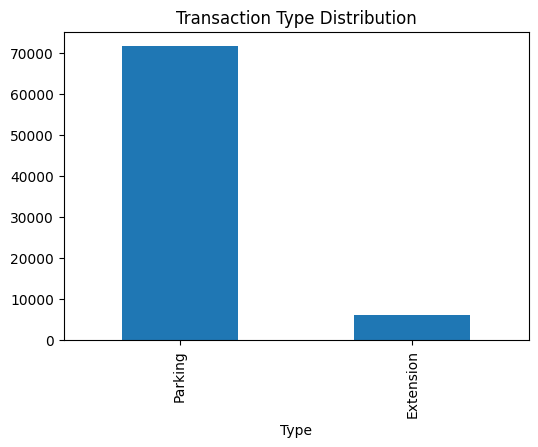

In [ ]:
#Transaction types distribution
merged_df['Type'].value_counts().plot(kind='bar', figsize=(6,4), title='Transaction Type Distribution')


<Axes: title={'center': 'Top 10 Parking Lots by Transactions'}, xlabel='Unit'>

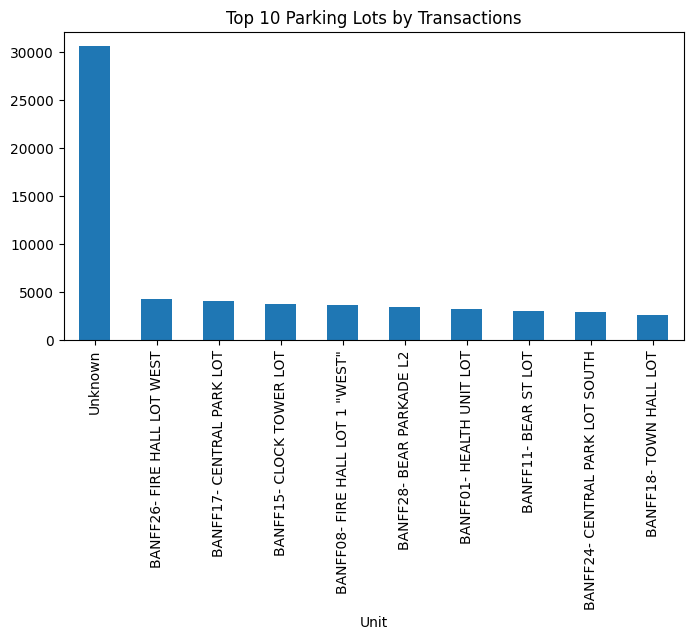

In [ ]:
#Parking usage by lot
merged_df['Unit'].value_counts().head(10).plot(kind='bar', figsize=(8,4), title='Top 10 Parking Lots by Transactions')

Text(0, 0.5, 'Amount ($)')

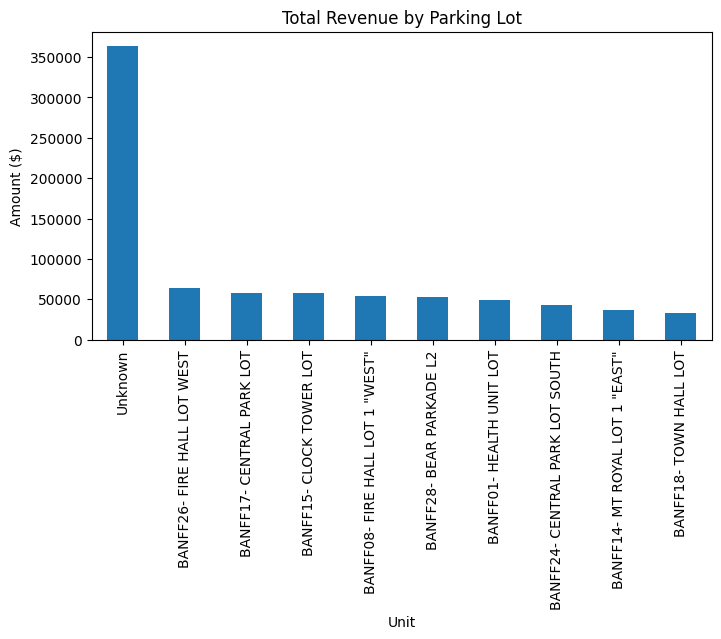

In [ ]:
#Revenue by parking lot

merged_df.groupby('Unit')['Amount'].sum().sort_values(ascending=False).head(10).plot(kind='bar', figsize=(8,4))
plt.title("Total Revenue by Parking Lot")
plt.ylabel("Amount ($)")


Text(0, 0.5, 'Count')

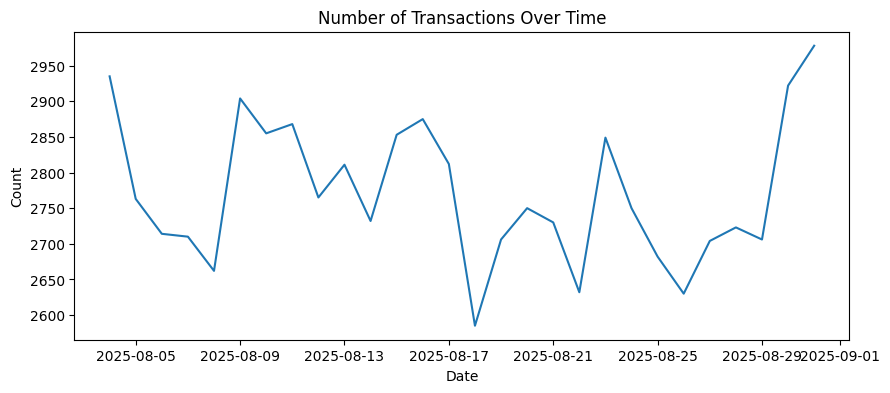

In [ ]:
#When are people parking most often?
merged_df['Date'] = pd.to_datetime(merged_df['Date'], errors='coerce')
merged_df['Date'].dt.date.value_counts().sort_index().plot(figsize=(10,4))
plt.title("Number of Transactions Over Time")
plt.ylabel("Count")


<Axes: title={'center': 'Transactions by Day of Week'}, xlabel='weekday'>

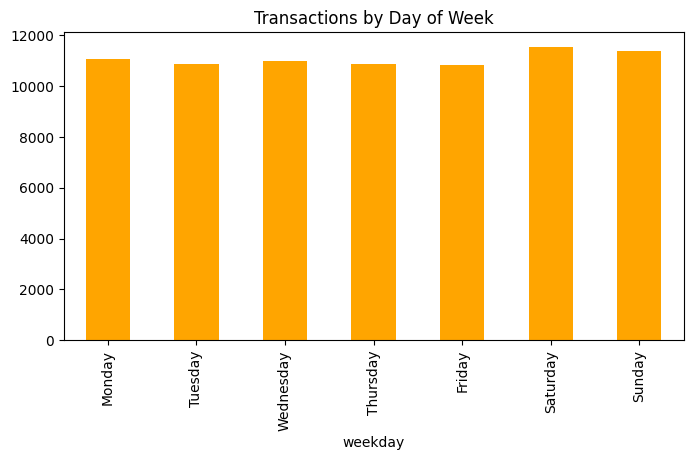

In [ ]:
merged_df['weekday'] = merged_df['Date'].dt.day_name()
merged_df.groupby('weekday').size().reindex(
    ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
).plot(kind='bar', figsize=(8,4), color='orange', title='Transactions by Day of Week')


In [ ]:
lot_col = 'Unit'


In [ ]:
lot_counts = merged_df[lot_col].value_counts().dropna()
print(lot_counts.head(10))


Unit
Unknown                            30542
BANFF26- FIRE HALL LOT WEST         4225
BANFF17- CENTRAL PARK LOT           4016
BANFF15- CLOCK TOWER LOT            3750
BANFF08- FIRE HALL LOT 1 "WEST"     3639
BANFF28- BEAR PARKADE L2            3428
BANFF01- HEALTH UNIT LOT            3234
BANFF11- BEAR ST LOT                3005
BANFF24- CENTRAL PARK LOT SOUTH     2906
BANFF18- TOWN HALL LOT              2568
Name: count, dtype: int64


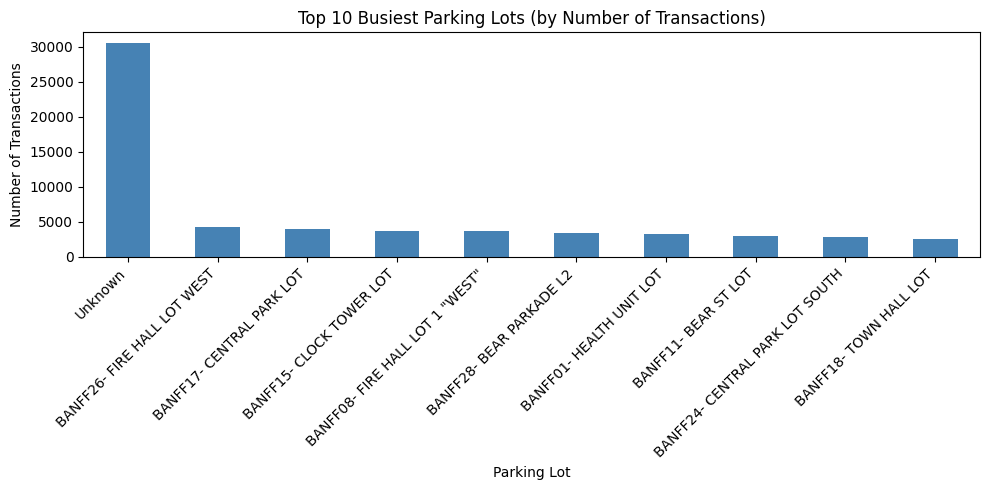

In [ ]:

lot_counts.head(10).plot(
    kind='bar',
    figsize=(10,5),
    color='steelblue',
    title='Top 10 Busiest Parking Lots (by Number of Transactions)'
)
plt.ylabel('Number of Transactions')
plt.xlabel('Parking Lot')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


Text(0, 0.5, 'Average Amount ($)')

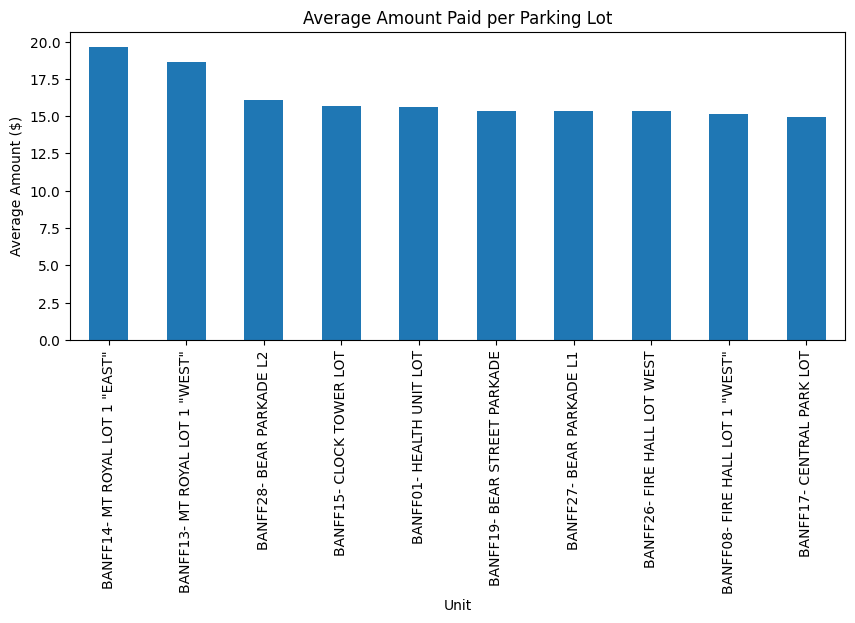

In [ ]:
#Average Amount by Parking Lot
merged_df.groupby('Unit')['Amount'].mean().sort_values(ascending=False).head(10).plot(kind='bar', figsize=(10,4))
plt.title('Average Amount Paid per Parking Lot')
plt.ylabel('Average Amount ($)')


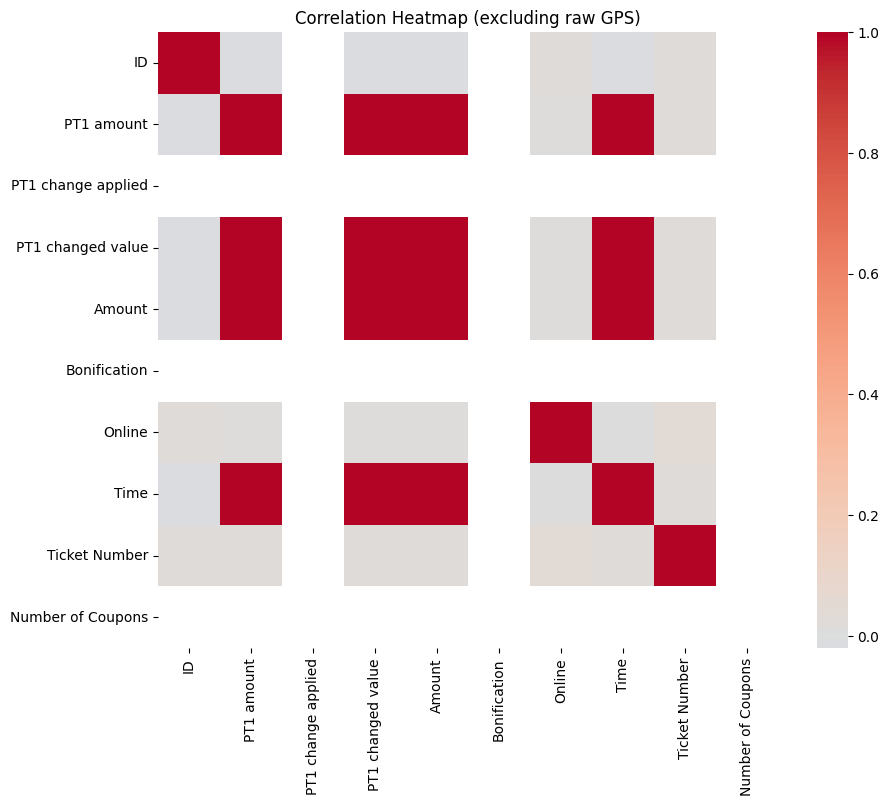

In [ ]:


# drop non-numeric or irrelevant columns (like raw GPS)
corr_cols = merged_df.drop(columns=['Hope Gps Longitude', 'Hope Gps Latitude'])

# compute correlation
corr = corr_cols.corr(numeric_only=True)

plt.figure(figsize=(10, 8))
sns.heatmap(corr, cmap='coolwarm', center=0)
plt.title("Correlation Heatmap (excluding raw GPS)")
plt.show()


In [ ]:
#  Save the merged data
merged_df.to_csv("merged_clean.csv", index=False)

from google.colab import files
files.download("merged_clean.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>